# Xenium Human Lung Cancer (FFPE) workflow

**Author:** MD Shakhaowat Hossain, PhD Candidate, Tulane University School of Medicine · [Project website](https://hossainms.github.io/xenium-human-lung-cancer-ffpe/) · [Code](https://github.com/hossainms/xenium-human-lung-cancer-ffpe)

## Input data: two lung cancer FFPE datasets from 10x Genomics (CC BY 4.0)

| | **Dataset A (start here)** | **Dataset B (scale-up)** |
|---|---|---|
| Platform | Xenium v1, Onboard Analysis 2.0.0, multimodal segmentation | Xenium Prime 5K, Onboard Analysis 3.0.0 |
| Gene panel | Human Multi-Tissue & Cancer (377 genes + 20 negative-control probes) | 5K Pan Tissue & Pathways (~5,100 genes) |
| Tissue area | 30.3 mm² | 71.1 mm² |
| Cells | 162,254 | 278,328 |
| High-quality transcripts (Q20) | 10.6 M | 149.4 M |
| Median transcripts per cell | 46 | 242 |
| Median genes per cell | 29 | 196 |
| Share of transcripts assigned to cells | 86.6% | 82.0% |
| Download size (zip) | ~8.0 GB | ~22.6 GB |

**Download base URLs**
- Dataset A: `https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_humanLung_Cancer_FFPE/` ([dataset page](https://www.10xgenomics.com/datasets/preview-data-ffpe-human-lung-cancer-with-xenium-multimodal-cell-segmentation-1-standard))
- Dataset B: `https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Human_Lung_Cancer_FFPE/` ([dataset page](https://www.10xgenomics.com/datasets/xenium-human-lung-cancer-post-xenium-technote))

### Dataset A's other QC numbers
- 87.4% of transcripts pass the Q20 quality filter.
- The negative-control rate is very low (about 0.05 false-positive transcripts per cell).
- Cell segmentation used three methods: 33% of cells from a boundary stain, 65% from an interior stain, and 1.5% by expanding the nucleus outline.

### Its panel covers what a TIME analysis needs
- **T cells:** CD3D/E, CD8A, CD4, FOXP3, TRAC
- **Checkpoints:** PDCD1, CD274 (PD-L1), CTLA4, LAG3, HAVCR2
- **Myeloid:** CD68, CD163, MARCO, TREM2
- **B and plasma cells:** MS4A1, CD79A, MZB1
- **Tumour and epithelium:** EPCAM, KRT7, EGFR, ERBB2, MET
- **Stroma:** PDGFRA/B, ACTA2
- **Proliferation:** MKI67, TOP2A


### Proposed pipeline

1. Download Dataset A.
2. Input data overview: annotated folder tree and a data card of every file (headers only, via pyarrow, h5py and tifffile).
3. Load it with spatialdata-io into a SpatialData object and explore the raw tables (transcripts, cells, boundaries) with pyarrow.
4. Run QC.
5. Normalise and cluster.
6. Annotate cell types.
7. Spatial analysis (neighbourhood enrichment, niches, immune infiltration).
8. Align the H&E image.
9. TIME deep-dive: checkpoint expression, CD8 T-cell states by location, spatial ligand-receptor contacts, immune phenotypes (inflamed / excluded / desert), immunosuppressive balance.
10. squidpy spatial statistics: Moran's I, co-occurrence, Ripley's L, centrality / interaction matrix, ligrec vs. contact test.
11. Optionally, repeat on Dataset B.

## Step 1: Download Dataset A

Download the dataset to `~/data/xenium_lung/`. Completed files are skipped, and interrupted downloads resume, allowing the cell to be re-run without repeating completed transfers.

Set `DOWNLOAD_HE = True` to include the matched H&E image (~1.2 GB), used in Step 8 to examine cell locations relative to tumour, stromal, and TLS-like regions. If storage is limited, set this option to `False`; the image can be downloaded later by enabling the option and re-running the cell.

Allow approximately 16 GB for the compressed archive and extracted data, plus 1.2 GB for the H&E image. Set `DELETE_ZIP_AFTER_UNZIP = True` to remove the archive after extraction and recover approximately 8 GB of storage.

In [1]:
import shutil
import zipfile
from pathlib import Path

import requests
from tqdm.auto import tqdm

# ---- Settings ---------------------------------------------------------------
DATA_ROOT = Path("~/data/xenium_lung").expanduser()   # outside OneDrive
DOWNLOAD_HE = True              # ~1.2 GB matched H&E image for Step 8 alignment
DELETE_ZIP_AFTER_UNZIP = False  # set True to free ~8 GB once extracted

SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
BASE_URL = f"https://cf.10xgenomics.com/samples/xenium/2.0.0/{SAMPLE}"

FILES = [
    f"{SAMPLE}_metrics_summary.csv",
    f"{SAMPLE}_gene_panel.json",
    f"{SAMPLE}_he_imagealignment.csv",
    f"{SAMPLE}_outs.zip",
]
if DOWNLOAD_HE:
    FILES.append(f"{SAMPLE}_he_image.ome.tif")

DATA_DIR = DATA_ROOT / SAMPLE
# ask for raw bytes so byte counts match on-disk sizes (no gzip transfer encoding)
NO_GZIP = {"Accept-Encoding": "identity"}
DATA_DIR.mkdir(parents=True, exist_ok=True)


def remote_size(url):
    r = requests.head(url, headers=NO_GZIP, allow_redirects=True, timeout=60)
    r.raise_for_status()
    return int(r.headers.get("content-length", 0))


def download(url, dest):
    """Resumable download: skips complete files, continues partial ones."""
    total = remote_size(url)
    have = dest.stat().st_size if dest.exists() else 0
    if total and have == total:
        print(f"[skip] {dest.name} already complete ({total / 1e9:.2f} GB)")
        return
    if have > total:  # corrupt / mismatched partial, start over
        dest.unlink()
        have = 0

    headers = {**NO_GZIP, **({"Range": f"bytes={have}-"} if have else {})}
    with requests.get(url, headers=headers, stream=True, timeout=60) as r:
        r.raise_for_status()
        if have and r.status_code != 206:  # server ignored Range, restart
            have = 0
        mode = "ab" if have else "wb"
        with open(dest, mode) as f, tqdm(
            total=total, initial=have, unit="B", unit_scale=True, desc=dest.name
        ) as bar:
            for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                f.write(chunk)
                bar.update(len(chunk))

    if dest.stat().st_size != total:
        raise IOError(f"{dest.name}: size mismatch, re-run this cell to resume")


# ---- Disk space check -------------------------------------------------------
needed = sum(remote_size(f"{BASE_URL}/{f}") for f in FILES)
free = shutil.disk_usage(DATA_ROOT).free
print(f"Download size: {needed / 1e9:.1f} GB | free disk: {free / 1e9:.1f} GB")
if free < 2.2 * needed:  # zip + extracted copy + headroom
    print("WARNING: disk space is tight for download + unzip.")

# ---- Download ---------------------------------------------------------------
for fname in FILES:
    download(f"{BASE_URL}/{fname}", DATA_DIR / fname)

# ---- Unzip the output bundle -------------------------------------------------
zip_path = DATA_DIR / f"{SAMPLE}_outs.zip"
OUTS_DIR = DATA_DIR / "outs"
if not (OUTS_DIR / "experiment.xenium").exists():
    with zipfile.ZipFile(zip_path) as zf:
        members = zf.infolist()
        # strip a single top-level folder (e.g. "outs/") if the zip has one
        tops = {m.filename.split("/")[0] for m in members}
        prefix = tops.pop() + "/" if len(tops) == 1 else ""
        OUTS_DIR.mkdir(exist_ok=True)
        for m in tqdm(members, desc="unzip"):
            rel = m.filename[len(prefix):]
            if not rel:
                continue
            target = OUTS_DIR / rel
            if m.is_dir():
                target.mkdir(parents=True, exist_ok=True)
                continue
            target.parent.mkdir(parents=True, exist_ok=True)
            with zf.open(m) as src, open(target, "wb") as dst:
                shutil.copyfileobj(src, dst, length=8 * 1024 * 1024)
    if DELETE_ZIP_AFTER_UNZIP:
        zip_path.unlink()
else:
    print("[skip] outs/ already extracted")

# ---- Inventory (relative paths only) -----------------------------------------
print(f"\nContents of {SAMPLE}/outs:")
for item in sorted(OUTS_DIR.iterdir()):
    if item.is_file():
        size = item.stat().st_size
    else:
        size = sum(f.stat().st_size for f in item.rglob("*") if f.is_file())
    print(f"  {item.name:<40} {size / 1e6:>10.1f} MB")


Download size: 9.2 GB | free disk: 49.5 GB
[skip] Xenium_V1_humanLung_Cancer_FFPE_metrics_summary.csv already complete (0.00 GB)
[skip] Xenium_V1_humanLung_Cancer_FFPE_gene_panel.json already complete (0.00 GB)
[skip] Xenium_V1_humanLung_Cancer_FFPE_he_imagealignment.csv already complete (0.00 GB)
[skip] Xenium_V1_humanLung_Cancer_FFPE_outs.zip already complete (7.99 GB)
[skip] Xenium_V1_humanLung_Cancer_FFPE_he_image.ome.tif already complete (1.19 GB)
[skip] outs/ already extracted

Contents of Xenium_V1_humanLung_Cancer_FFPE/outs:
  analysis.tar.gz                                32.1 MB
  analysis.zarr.zip                               1.4 MB
  analysis_summary.html                          10.4 MB
  aux_outputs.tar.gz                             50.2 MB
  cell_boundaries.csv.gz                         38.4 MB
  cell_boundaries.parquet                        14.4 MB
  cell_feature_matrix.h5                          6.7 MB
  cell_feature_matrix.tar.gz                     23.0 MB
  cel

## Step 2: Input data overview

Inspect the dataset structure and file contents before beginning the analysis. The following cells read file headers, metadata, and small previews without loading the full dataset into memory.

- **2a · Data folder tree:** Lists files and folders with their sizes, role tags, and descriptions. Compressed archives are listed without extraction.
- **2b · Data card:** Summarises run metadata, table columns and their meanings, three-row previews, count-matrix structure, image dimensions and stains, and H&E alignment information.

| Role tag | Meaning |
|---|---|
| `CORE` | Primary analysis inputs you will load (transcripts, cells, boundaries, count matrix) |
| `IMAGE` | Microscopy images (DAPI z-stack, segmentation stains, H&E) |
| `META` | Run and panel metadata |
| `QC` | Quality reports and technical extras |
| `BASELINE` | 10x's own automated clustering, to benchmark your results against |
| `EXPLORER` | Xenium Explorer viewer formats (not needed for Python analysis) |
| `COPY` | Same content as a `CORE` file in another format (CSV, MEX) |
| `ARCHIVE` | Compressed download bundle |

### 2a. Data folder tree

Run the following cell to inspect the dataset directory. Each entry includes its size, a role tag defined in the table above, and a brief description.

Use the role tags to distinguish core analysis inputs (`CORE`) from duplicate files (`COPY`) and compressed archives (`ARCHIVE`). Review these classifications before removing any files.

In [2]:
import tarfile
from collections import defaultdict
from pathlib import Path

# Re-declared here so this cell runs on its own after a kernel restart
DATA_ROOT = Path("~/data/xenium_lung").expanduser()
SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
SAMPLE_DIR = DATA_ROOT / SAMPLE
OUTS_DIR = SAMPLE_DIR / "outs"

# Role tags tell you at a glance how each file is used in the workflow
#   CORE     primary analysis input (you will load these)
#   IMAGE    microscopy images
#   META     run / panel metadata
#   QC       quality reports
#   BASELINE 10x's own automated analysis, to benchmark your results against
#   EXPLORER Xenium Explorer viewer format (not needed for Python analysis)
#   COPY     same content as a CORE file, different format
#   ARCHIVE  compressed bundle
P = SAMPLE + "_"
FILE_INFO = {
    # ---- top level: files downloaded individually from 10x ----
    f"{P}outs.zip":                 ("ARCHIVE",  "Original 10x download of outs/. Safe to delete once unzipped"),
    f"{P}he_image.ome.tif":         ("IMAGE",    "H&E stain of the same section (RGB, pyramidal). For pathology context"),
    f"{P}he_imagealignment.csv":    ("META",     "3x3 affine matrix: H&E pixels -> Xenium morphology pixels"),
    f"{P}gene_panel.json":          ("META",     "Panel definition (copy of outs/gene_panel.json)"),
    f"{P}metrics_summary.csv":      ("QC",       "Run QC numbers (copy of outs/metrics_summary.csv)"),
    # ---- outs/: the Xenium Onboard Analysis bundle ----
    "outs":                         ("",         "Xenium Onboard Analysis 2.0 output bundle"),
    "outs/experiment.xenium":       ("META",     "Run manifest (JSON): panel, pixel size, file pointers. Readers open this"),
    "outs/gene_panel.json":         ("META",     "Panel: 377 genes + negative controls, probe and codeword details"),
    "outs/metrics_summary.csv":     ("QC",       "One-row QC table: cells, transcripts, Q20 rate, negative-control rate"),
    "outs/analysis_summary.html":   ("QC",       "10x web report (QC plots + clustering). Open in a browser first"),
    "outs/transcripts.parquet":     ("CORE",     "Every decoded transcript: gene, x/y/z (um), quality qv, assigned cell_id"),
    "outs/transcripts.csv.gz":      ("COPY",     "Same as transcripts.parquet, as CSV"),
    "outs/transcripts.zarr.zip":    ("EXPLORER", "Transcripts for the Xenium Explorer viewer"),
    "outs/cells.parquet":           ("CORE",     "One row per cell: centroid x/y (um), cell/nucleus area, counts"),
    "outs/cells.csv.gz":            ("COPY",     "Same as cells.parquet, as CSV"),
    "outs/cells.zarr.zip":          ("EXPLORER", "Cell + nucleus masks and summaries for Xenium Explorer"),
    "outs/cell_boundaries.parquet": ("CORE",     "Cell outline polygons: vertex x/y (um) per cell_id"),
    "outs/cell_boundaries.csv.gz":  ("COPY",     "Same as cell_boundaries.parquet, as CSV"),
    "outs/nucleus_boundaries.parquet": ("CORE",  "Nucleus outline polygons: vertex x/y (um) per cell_id"),
    "outs/nucleus_boundaries.csv.gz":  ("COPY",  "Same as nucleus_boundaries.parquet, as CSV"),
    "outs/cell_feature_matrix.h5":  ("CORE",     "Cell x feature count matrix (genes + controls). Loads into AnnData"),
    "outs/cell_feature_matrix.tar.gz": ("COPY",  "Same matrix in MEX format (matrix.mtx, barcodes, features)"),
    "outs/cell_feature_matrix.zarr.zip": ("EXPLORER", "Count matrix for Xenium Explorer"),
    "outs/morphology.ome.tif":      ("IMAGE",    "3D DAPI (nuclei) z-stack, full resolution, pyramidal"),
    "outs/morphology_focus":        ("IMAGE",    "2D in-focus images, one stain per file (used for segmentation)"),
    "outs/analysis.tar.gz":         ("BASELINE", "10x clustering, differential expression, PCA, UMAP, t-SNE (CSV)"),
    "outs/analysis.zarr.zip":       ("EXPLORER", "10x clustering results for Xenium Explorer"),
    "outs/aux_outputs.tar.gz":      ("QC",       "Technical extras: per-cycle raw channel images, FOV tile positions"),
}

# Descriptions for paths INSIDE tar.gz archives (shown without extracting)
ARCHIVE_INFO = {
    "analysis":            "Archive contents (listed, not extracted)",
    "cell_feature_matrix": "Archive contents (listed, not extracted)",
    "aux_outputs":         "Archive contents (listed, not extracted)",
    "analysis/clustering":       "Cluster label per cell (graph-based + k-means k=2..10)",
    "analysis/diffexp":          "Marker genes per cluster (log2 fold change, p-values)",
    "analysis/pca":              "PCA: loadings, per-cell projection, variance explained",
    "analysis/umap":             "2D UMAP coordinates per cell",
    "analysis/tsne":             "2D t-SNE coordinates per cell",
    "cell_feature_matrix/barcodes.tsv.gz": "Cell IDs (matrix columns)",
    "cell_feature_matrix/features.tsv.gz": "Feature IDs, names and types (matrix rows)",
    "cell_feature_matrix/matrix.mtx.gz":   "Sparse counts (Matrix Market)",
    "aux_outputs/per_cycle_channel_images": "Raw image per imaging cycle x color channel",
    "aux_outputs/morphology_fov_locations.json": "Position of each field of view (FOV) tile",
}
PEEK_INSIDE = {"outs/analysis.tar.gz", "outs/cell_feature_matrix.tar.gz", "outs/aux_outputs.tar.gz"}
MAX_CHILDREN = 6  # inside archives, collapse long lists of similar entries


def human(n):
    for unit in ("B", "KB", "MB", "GB", "TB"):
        if n < 1000 or unit == "TB":
            return f"{n:.0f} {unit}" if unit == "B" else f"{n:.1f} {unit}"
        n /= 1000


def path_size(p):
    return p.stat().st_size if p.is_file() else sum(f.stat().st_size for f in p.rglob("*") if f.is_file())


def focus_channels(focus_dir):
    """Map each morphology_focus file to its stain, read from the OME-XML header."""
    try:
        import re
        import tifffile
        first = sorted(focus_dir.glob("*.ome.tif"))[0]
        with tifffile.TiffFile(first) as t:
            xml = t.ome_metadata or ""
        names = re.findall(r'<Channel [^>]*Name="([^"]+)"', xml)
        files = re.findall(r'<TiffData FirstC="(\d+)"[^>]*>\s*<UUID[^>]*FileName="([^"]+)"', xml)
        return {fname: names[int(c)] for c, fname in files if int(c) < len(names)}
    except Exception:
        return {}


STAIN_ROLE = {
    "DAPI": "nuclei",
    "18S": "ribosomal RNA, cell interior",
    "ATP1A1/CD45/E-Cadherin": "membrane, cell boundary",
    "alphaSMA/Vimentin": "cytoskeleton, cell interior",
}

rows = []  # (tree_prefix + name, size_str, role, description)
role_bytes = defaultdict(int)


def add(prefix, name, size, role="", desc=""):
    rows.append((prefix + name, human(size) if size is not None else "", role, desc))


def archive_tree(tar_path, prefix):
    """List a tar.gz as a tree (sizes = uncompressed) without extracting it."""
    tree = {}
    with tarfile.open(tar_path, "r:gz") as tf:
        for m in tf.getmembers():
            node = tree
            parts = m.name.strip("/").split("/")
            for part in parts[:-1]:
                node = node.setdefault(part, {"__size__": 0})
                node["__size__"] += m.size
            leaf = node.setdefault(parts[-1], {"__size__": 0})
            if m.isfile():
                leaf["__size__"] = m.size

    def walk(node, path, pre):
        kids = [k for k in node if k != "__size__"]
        shown = kids if len(kids) <= MAX_CHILDREN + 1 else kids[:MAX_CHILDREN]
        for i, k in enumerate(shown):
            last = i == len(shown) - 1 and len(shown) == len(kids)
            child, cpath = node[k], f"{path}/{k}" if path else k
            is_dir = any(x != "__size__" for x in child)
            add(pre + ("└── " if last else "├── "), k + ("/" if is_dir else ""),
                child["__size__"], "", ARCHIVE_INFO.get(cpath, ""))
            # always open the archive's top folder; stop at any described sub-folder
            if is_dir and ("/" not in cpath or cpath not in ARCHIVE_INFO):
                walk(child, cpath, pre + ("    " if last else "│   "))
        if len(shown) < len(kids):
            add(pre + "└── ", f"... +{len(kids) - len(shown)} more", None)

    walk(tree, "", prefix)


def walk_dir(directory, prefix=""):
    entries = sorted(directory.iterdir(), key=lambda p: (p.is_dir(), p.name.lower()))
    entries = [e for e in entries if not e.name.startswith(".")]
    for i, entry in enumerate(entries):
        last = i == len(entries) - 1
        rel = entry.relative_to(SAMPLE_DIR).as_posix()
        role, desc = FILE_INFO.get(rel, ("", ""))
        size = path_size(entry)
        if entry.is_file() and role:
            role_bytes[role] += size
        add(prefix + ("└── " if last else "├── "), entry.name + ("/" if entry.is_dir() else ""), size, role, desc)
        child_prefix = prefix + ("    " if last else "│   ")
        if entry.is_dir():
            if entry.name == "morphology_focus":
                stains = focus_channels(entry)
                files = sorted(entry.iterdir())
                for j, f in enumerate(files):
                    stain = stains.get(f.name, "?")
                    role_bytes["IMAGE"] += f.stat().st_size
                    add(child_prefix + ("└── " if j == len(files) - 1 else "├── "), f.name,
                        f.stat().st_size, "IMAGE", f"Stain: {stain} ({STAIN_ROLE.get(stain, '')})")
            else:
                walk_dir(entry, child_prefix)
        elif rel in PEEK_INSIDE:
            archive_tree(entry, child_prefix)


add("", SAMPLE + "/", path_size(SAMPLE_DIR), "", "Dataset A: human lung cancer, FFPE, Xenium v1 (377 genes)")
walk_dir(SAMPLE_DIR)

# ---- print as an aligned table ----------------------------------------------
w_name = max(len(r[0]) for r in rows)
w_size = max(len(r[1]) for r in rows)
w_role = max(len(r[2]) for r in rows) + 3
print(f"{'PATH':<{w_name}}  {'SIZE':>{w_size}}  {'ROLE':<{w_role}}DESCRIPTION")
print("-" * (w_name + w_size + w_role + 60))
for name, size, role, desc in rows:
    tag = f"[{role}]" if role else ""
    print(f"{name:<{w_name}}  {size:>{w_size}}  {tag:<{w_role}}{desc}")

# ---- disk usage by role -------------------------------------------------------
print("\nDisk usage by role (top-level files and outs/; archive contents not double-counted)")
total = sum(role_bytes.values())
for role, b in sorted(role_bytes.items(), key=lambda kv: -kv[1]):
    print(f"  {role:<9} {human(b):>9}  {b / total:6.1%}")
print(f"  {'TOTAL':<9} {human(total):>9}")
print("\nSizes are decimal (1 GB = 10^9 bytes). Archive contents show uncompressed sizes.")

PATH                                                           SIZE  ROLE       DESCRIPTION
----------------------------------------------------------------------------------------------------------------------------------------
Xenium_V1_humanLung_Cancer_FFPE/                            17.2 GB             Dataset A: human lung cancer, FFPE, Xenium v1 (377 genes)
├── Xenium_V1_humanLung_Cancer_FFPE_gene_panel.json        209.1 KB  [META]     Panel definition (copy of outs/gene_panel.json)
├── Xenium_V1_humanLung_Cancer_FFPE_he_image.ome.tif         1.2 GB  [IMAGE]    H&E stain of the same section (RGB, pyramidal). For pathology context
├── Xenium_V1_humanLung_Cancer_FFPE_he_imagealignment.csv     126 B  [META]     3x3 affine matrix: H&E pixels -> Xenium morphology pixels
├── Xenium_V1_humanLung_Cancer_FFPE_metrics_summary.csv      1.7 KB  [QC]       Run QC numbers (copy of outs/metrics_summary.csv)
├── Xenium_V1_humanLung_Cancer_FFPE_outs.zip                 8.0 GB  [ARCHIVE]  Origina

### 2b. Data card: file contents and conventions

Run the following cell to inspect the dataset files, their structure, and key metadata. Use the output to verify these conventions before proceeding:

- Coordinates are reported in micrometres (µm). Morphology-image pixels represent 0.2125 µm; divide coordinates by 0.2125 to obtain morphology-image pixel positions.
- `cell_id` links transcript assignments, cell metadata, boundary polygons, and the cell-by-feature count matrix.
- The count matrix contains 541 features: 377 genes and 164 background controls. For biological analysis, retain `Gene Expression` features and filter transcript records to `qv >= 20`.
- Boundary tables contain one row per polygon vertex, not one row per cell.
- The matched H&E image is rotated approximately 90° and differs in scale from the Xenium coordinate system. Use the supplied alignment matrix for registration.

In [3]:
import json
import re
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import tifffile
from IPython.display import display

DATA_ROOT = Path("~/data/xenium_lung").expanduser()
SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
SAMPLE_DIR = DATA_ROOT / SAMPLE
OUTS_DIR = SAMPLE_DIR / "outs"

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)


def header(title):
    print(f"\n{'=' * 90}\n{title}\n{'=' * 90}")


# ---- 1. Run metadata ---------------------------------------------------------
header("1. RUN METADATA  (outs/experiment.xenium)")
exp = json.loads((OUTS_DIR / "experiment.xenium").read_text())
keys = ["run_name", "region_name", "preservation_method", "panel_name", "panel_design_id",
        "panel_num_targets_predesigned", "num_cells", "transcripts_per_cell",
        "pixel_size", "z_step_size", "analysis_sw_version", "segmentation_stain", "run_start_time"]
display(pd.DataFrame({"value": [exp.get(k) for k in keys]}, index=keys))

# ---- 2. Tables: schema + preview (metadata only, nothing large is loaded) -----
COLUMN_INFO = {
    "transcripts.parquet": {
        "transcript_id": "Unique ID of the detected transcript",
        "cell_id": "Cell it was assigned to ('UNASSIGNED' = outside any cell)",
        "overlaps_nucleus": "1 if the transcript lies inside the nucleus",
        "feature_name": "Gene name, or control probe / codeword name",
        "x_location": "X position (um)",
        "y_location": "Y position (um)",
        "z_location": "Z depth in the section (um)",
        "qv": "Decoding quality (Phred-like). Keep qv >= 20",
        "fov_name": "Imaging field-of-view tile it came from",
        "nucleus_distance": "Distance to the nearest nucleus edge (um)",
        "codeword_index": "Index of the optical barcode (codeword)",
    },
    "cells.parquet": {
        "cell_id": "Unique cell ID (joins to every other table)",
        "x_centroid": "Cell centre X (um)",
        "y_centroid": "Cell centre Y (um)",
        "transcript_counts": "High-quality gene transcripts in the cell",
        "control_probe_counts": "Negative-control probe counts (background)",
        "control_codeword_counts": "Negative-control codeword counts (decoding errors)",
        "unassigned_codeword_counts": "Unused-codeword counts (decoding errors)",
        "deprecated_codeword_counts": "Deprecated-codeword counts",
        "total_counts": "All counts in the cell, controls included",
        "cell_area": "Cell area (um^2)",
        "nucleus_area": "Nucleus area (um^2)",
    },
    "cell_boundaries.parquet": {
        "cell_id": "Cell the vertex belongs to",
        "vertex_x": "Polygon vertex X (um)",
        "vertex_y": "Polygon vertex Y (um)",
    },
    "nucleus_boundaries.parquet": {
        "cell_id": "Cell whose nucleus the vertex belongs to",
        "vertex_x": "Polygon vertex X (um)",
        "vertex_y": "Polygon vertex Y (um)",
    },
}

for fname, col_info in COLUMN_INFO.items():
    pf = pq.ParquetFile(OUTS_DIR / fname)
    schema = pf.schema_arrow
    header(f"2. TABLE  outs/{fname}   rows: {pf.metadata.num_rows:,}   columns: {len(schema)}")
    display(pd.DataFrame({
        "column": schema.names,
        "dtype": [str(t) for t in schema.types],
        "meaning": [col_info.get(c, "") for c in schema.names],
    }))
    preview = next(pf.iter_batches(batch_size=3)).to_pandas()
    print("First 3 rows:")
    display(preview)

# ---- 3. Count matrix ------------------------------------------------------------
header("3. COUNT MATRIX  (outs/cell_feature_matrix.h5)")
with h5py.File(OUTS_DIR / "cell_feature_matrix.h5", "r") as h5:
    n_features, n_cells = h5["matrix/shape"][:]
    nnz = h5["matrix/data"].shape[0]
    ftypes = pd.Series([t.decode() for t in h5["matrix/features/feature_type"][:]])
    names = pd.Series([t.decode() for t in h5["matrix/features/name"][:]])
print(f"Shape: {n_cells:,} cells x {n_features:,} features (stored features x cells, CSC sparse)")
print(f"Non-zero entries: {nnz:,}  ({nnz / (n_cells * n_features):.1%} of the matrix is non-zero)")
summary = (pd.DataFrame({"feature_type": ftypes, "name": names})
           .groupby("feature_type")["name"]
           .agg(n="size", examples=lambda s: ", ".join(s.head(4))))
display(summary.sort_values("n", ascending=False))
print("Only 'Gene Expression' features are used for biology; the rest are background controls.")

# ---- 4. Images --------------------------------------------------------------------
header("4. IMAGES  (shape, channels, pyramid levels, physical size)")
images = {
    "outs/morphology.ome.tif": OUTS_DIR / "morphology.ome.tif",
    "outs/morphology_focus/ (4 files, 1 stain each)": OUTS_DIR / "morphology_focus" / "morphology_focus_0000.ome.tif",
    "H&E image": SAMPLE_DIR / f"{SAMPLE}_he_image.ome.tif",
}
img_rows = []
for label, path in images.items():
    with tifffile.TiffFile(path) as tif:
        series = tif.series[0]
        xml = tif.ome_metadata or ""
    channels = re.findall(r'<Channel [^>]*Name="([^"]+)"', xml)
    px = re.search(r'PhysicalSizeX="([\d.]+)"', xml)
    px = float(px.group(1)) if px else None
    axes = series.axes
    h, w = series.shape[axes.index("Y")], series.shape[axes.index("X")]
    img_rows.append({
        "image": label,
        "axes": axes,
        "shape": " x ".join(f"{s:,}" for s in series.shape),
        "dtype": str(series.dtype),
        "pyramid_levels": len(series.levels),
        "um_per_px": px if px else "see alignment",
        "extent_mm (W x H)": f"{w * px / 1000:.1f} x {h * px / 1000:.1f}" if px else "",
        "channels": ", ".join(channels) if channels else "RGB",
    })
display(pd.DataFrame(img_rows).set_index("image"))
print("Axes: Z = focal plane, C = stain channel, Y/X = pixel rows/cols, S = RGB samples.")

# ---- 5. H&E -> Xenium alignment -----------------------------------------------------
header("5. H&E ALIGNMENT  (he_imagealignment.csv)")
M = np.loadtxt(SAMPLE_DIR / f"{SAMPLE}_he_imagealignment.csv", delimiter=",")
scale = np.sqrt(abs(np.linalg.det(M[:2, :2])))
angle = np.degrees(np.arctan2(M[1, 0], M[0, 0]))
print("Affine matrix (H&E pixel -> Xenium morphology pixel):")
print(np.array2string(M, precision=4, suppress_small=True))
print(f"Scale:       {scale:.4f} Xenium px per H&E px  "
      f"(H&E ~{exp['pixel_size'] * scale:.4f} um/px)")
print(f"Rotation:    {angle:.1f} degrees  (the H&E was scanned turned relative to Xenium)")
print(f"Translation: x = {M[0, 2]:,.1f} px, y = {M[1, 2]:,.1f} px")


1. RUN METADATA  (outs/experiment.xenium)


,value
run_name,Human Multi-Tissue Cancer (FFPE)
region_name,Human_Lung_Cancer
preservation_method,FFPE
panel_name,Xenium Human Multi-Tissue and Cancer Gene Expression
panel_design_id,hMulti_v1
panel_num_targets_predesigned,377
num_cells,162254
transcripts_per_cell,46
pixel_size,0.2125
z_step_size,3.0



2. TABLE  outs/transcripts.parquet   rows: 12,165,021   columns: 11


,column,dtype,meaning
0,transcript_id,uint64,Unique ID of the detected transcript
1,cell_id,string,Cell it was assigned to ('UNASSIGNED' = outside any cell)
2,overlaps_nucleus,uint8,1 if the transcript lies inside the nucleus
3,feature_name,string,"Gene name, or control probe / codeword name"
4,x_location,float,X position (um)
5,y_location,float,Y position (um)
6,z_location,float,Z depth in the section (um)
7,qv,float,Decoding quality (Phred-like). Keep qv >= 20
8,fov_name,string,Imaging field-of-view tile it came from
9,nucleus_distance,float,Distance to the nearest nucleus edge (um)


First 3 rows:


...


3. COUNT MATRIX  (outs/cell_feature_matrix.h5)
Shape: 162,254 cells x 541 features (stored features x cells, CSC sparse)
Non-zero entries: 4,901,617  (5.6% of the matrix is non-zero)


,n,examples
feature_type,,
Gene Expression,377,"ABCC11, ACE2, ACKR1, ACTA2"
Unassigned Codeword,103,"UnassignedCodeword_0006, UnassignedCodeword_0037, UnassignedCodeword_0069, U..."
Negative Control Codeword,41,"NegControlCodeword_0500, NegControlCodeword_0501, NegControlCodeword_0502, N..."
Negative Control Probe,20,"NegControlProbe_00042, NegControlProbe_00041, NegControlProbe_00039, NegCont..."


Only 'Gene Expression' features are used for biology; the rest are background controls.

4. IMAGES  (shape, channels, pyramid levels, physical size)


,axes,shape,dtype,pyramid_levels,um_per_px,extent_mm (W x H),channels
image,,,,,,,
outs/morphology.ome.tif,ZYX,"11 x 17,098 x 51,187",uint16,8,0.212500,10.9 x 3.6,DAPI
"outs/morphology_focus/ (4 files, 1 stain each)",CYX,"4 x 17,098 x 51,187",uint16,8,0.212500,10.9 x 3.6,"DAPI, 18S, ATP1A1/CD45/E-Cadherin, alphaSMA/Vimentin"
H&E image,YXS,"45,087 x 11,580 x 3",uint8,6,0.273771,3.2 x 12.3,RGB


Axes: Z = focal plane, C = stain channel, Y/X = pixel rows/cols, S = RGB samples.

5. H&E ALIGNMENT  (he_imagealignment.csv)
Affine matrix (H&E pixel -> Xenium morphology pixel):
[[    0.0048     1.2887   -75.482 ]
 [   -1.2887     0.0048 16309.1028]
 [    0.         0.         1.    ]]
Scale:       1.2887 Xenium px per H&E px  (H&E ~0.2739 um/px)
Rotation:    -89.8 degrees  (the H&E was scanned turned relative to Xenium)
Translation: x = -75.5 px, y = 16,309.1 px


## Step 3: Load the dataset and inspect the raw tables

Select the `spatial_env` Python kernel (`Kernel > Change Kernel`) before proceeding. Steps 1–2 can also run in `python_env`, but Step 3 onward requires `spatial_env`.

Use `spatialdata_io.xenium()` to load the Xenium `outs/` bundle into a single `SpatialData` object containing images, segmentation masks, transcripts, cell boundaries, and the cell-level count matrix.

| Element | Dataset entry | Contents |
|---|---|---|
| Images | `morphology_focus` | Four-channel morphology image stored as a five-level multiscale pyramid |
| Labels | `cell_labels`, `nucleus_labels` | Segmentation masks in which each pixel records its cell or nucleus identifier |
| Points | `transcripts` | Decoded transcript records, including coordinates, gene identity, quality score, and cell assignment |
| Shapes | `cell_boundaries` | Cell boundary polygons |
| Tables | `table` | AnnData cell-by-gene count matrix and cell-level metadata |

**Key conventions:**

- Lazy loading defers reading the full image, label, and transcript data until needed.
- The `global` coordinate system uses full-resolution morphology-image pixels. Transcript coordinates and boundary polygons are stored in micrometres and mapped to `global` using a scale factor of `1 / 0.2125`; images and labels are already in pixel coordinates.
- The table links each cell to its segmentation label through `table.obs["cell_labels"]`. Use this identifier, rather than row position, to match table entries to the label image.

This step loads the dataset (3a), checks the cell-level table against the raw files (3b), inspects raw transcripts (3c), and displays a whole-slide overview (3d).

### 3a. Load the Xenium bundle

Load the Xenium `outs/` bundle into a single `SpatialData` object containing images, segmentation masks, transcripts, cell boundaries, and the count table. Select the `spatial_env` kernel before running this cell.

The loader uses lazy loading for images, labels, and transcripts. Morphology-image channels are then relabelled using the channel names in the image’s OME metadata.

Inspect the loading summary, channel names, and element table. Confirm that all five element types are present and have transformations to the `global` coordinate system.

Note: For this dataset, `spatialdata-io 0.7.1` misassigns the 18S and membrane-stain channel names. The relabelling corrects these assignments and was verified against the corresponding stain patterns.

In [4]:
# This step needs the spatial_env kernel. Check it before importing anything.
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError(
        "Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)', then re-run this cell."
    )

import re
import time
import warnings
from pathlib import Path

import pandas as pd
import spatialdata as sd
import tifffile
import xarray as xr
from IPython.display import display
from spatialdata_io import xenium

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_ROOT = Path("~/data/xenium_lung").expanduser()
SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
OUTS_DIR = DATA_ROOT / SAMPLE / "outs"

# ---- Load ------------------------------------------------------------------------
t0 = time.time()
sdata = xenium(OUTS_DIR)  # lazy: images/points are dask-backed, read on demand
print(f"Loaded in {time.time() - t0:.1f} s\n")

# ---- Fix morphology_focus channel names -----------------------------------------
# spatialdata-io 0.7.1 hard-codes the channel order for XOA 2.0 and swaps
# channels 1 and 2 for this dataset. The OME metadata in the files is correct
# (verified: file 0002 is brightest at cell edges = membrane stain; file 0001 is
# cytoplasmic = 18S). Relabel from the files' own metadata.
with tifffile.TiffFile(OUTS_DIR / "morphology_focus" / "morphology_focus_0000.ome.tif") as tif:
    ome_channels = re.findall(r'<Channel [^>]*Name="([^"]+)"', tif.ome_metadata)
reader_channels = list(sdata["morphology_focus"]["scale0"]["image"].coords["c"].values)
if reader_channels != ome_channels:
    print(f"Relabeling channels\n  reader: {reader_channels}\n  OME:    {ome_channels}\n")
    tree = sdata["morphology_focus"]
    sdata.images["morphology_focus"] = xr.DataTree.from_dict(
        {name: node.to_dataset().assign_coords(c=ome_channels) for name, node in tree.children.items()}
    )

print(sdata)

# ---- One-row-per-element summary -------------------------------------------------
rows = []
for etype, name, el in sdata.gen_elements():
    if etype == "tables":
        shape, lazy = f"{el.n_obs:,} cells x {el.n_vars} genes", "no (in memory)"
    elif etype in ("images", "labels"):
        s0 = el["scale0"]["image"]
        shape = " x ".join(f"{d}={n:,}" for d, n in zip(s0.dims, s0.shape)) + f"  ({len(el.children)} levels)"
        lazy = "yes (dask)"
    elif etype == "points":
        shape, lazy = f"{len(el):,} transcripts x {len(el.columns)} cols", "yes (dask)"
    else:
        shape, lazy = f"{len(el):,} polygons", "no (in memory)"
    tf = "" if etype == "tables" else " ".join(str(sd.transformations.get_transformation(el)).split())
    rows.append({"element": name, "type": etype, "shape": shape, "lazy": lazy, "to 'global'": tf})
display(pd.DataFrame(rows).set_index("element"))

Loaded in 1.5 s

Relabeling channels
  reader: [np.str_('DAPI'), np.str_('ATP1A1/CD45/E-Cadherin'), np.str_('18S'), np.str_('AlphaSMA/Vimentin')]
  OME:    ['DAPI', '18S', 'ATP1A1/CD45/E-Cadherin', 'alphaSMA/Vimentin']

SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 17098, 51187), (4, 8549, 25593), (4, 4274, 12796), (4, 2137, 6398), (4, 1068, 3199)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (17098, 51187), (8549, 25593), (4274, 12796), (2137, 6398), (1068, 3199)
│     └── 'nucleus_labels': DataTree[yx] (17098, 51187), (8549, 25593), (4274, 12796), (2137, 6398), (1068, 3199)
├── Points
│     └── 'transcripts': DataFrame with shape: (48660084, 11) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (162254, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (162254, 377)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), c

,type,shape,lazy,to 'global'
element,,,,
morphology_focus,images,"c=4 x y=17,098 x x=51,187 (5 levels)",yes (dask),Identity
nucleus_labels,labels,"y=17,098 x x=51,187 (5 levels)",yes (dask),Identity
cell_labels,labels,"y=17,098 x x=51,187 (5 levels)",yes (dask),Identity
transcripts,points,"12,165,021 transcripts x 11 cols",yes (dask),"Scale (x, y) [4.70588235 4.70588235]"
cell_boundaries,shapes,"162,254 polygons",no (in memory),"Scale (x, y) [4.70588235 4.70588235]"
table,tables,"162,254 cells x 377 genes",no (in memory),


### 3b. Verify the cell table and spatial links

Check that the loaded cell table agrees with the raw files and links correctly to the segmentation labels and cell polygons.

The table contains gene-expression features only; control-feature counts are retained as cell-level metadata in `.obs`. The output summarises table dimensions, matrix sparsity, metadata, spatial units, coordinate scaling, and tissue extent.

Confirm that all four consistency checks pass:

- Cell count matches `cells.parquet`.
- Matrix row sums match `obs["transcript_counts"]`.
- Table cell identifiers match cell-polygon identifiers.
- Transcript count matches `transcripts.parquet`.

Note: For this dataset and software version, `print(sdata)` overstates the transcript count; use `len()` to obtain the correct count. The loader does not create nucleus polygons for this early Xenium Onboard Analysis 2.0 output, so use `nucleus_labels` for nuclear outlines.

In [5]:
import numpy as np
import pyarrow.parquet as pq

table = sdata.tables["table"]
PIXEL_SIZE = 0.2125  # um per morphology pixel (experiment.xenium)

# ---- The AnnData table: the cell x gene matrix you will analyse ------------------
print(table, "\n")
print(f"X: {type(table.X).__name__}, dtype {table.X.dtype}, "
      f"{table.X.nnz / np.prod(table.shape):.1%} non-zero")
print(f"Feature types kept: {table.var['feature_types'].unique().tolist()} "
      "(gex_only=True drops control features; their counts stay in .obs)")
print(f"obsm['spatial'] = cell centroids in um, e.g. {np.round(table.obsm['spatial'][0], 1)}\n")

print("Per-cell metadata (.obs):")
display(table.obs.head())

# ---- How the table links to the spatial elements ----------------------------------
attrs = table.uns["spatialdata_attrs"]
print(f"Table annotates '{attrs['region']}': row i <-> pixel value "
      f"table.obs['{attrs['instance_key']}'][i] in the label image.")
print("Cell polygons in 'cell_boundaries' share the same cell_id index.\n")

# ---- Coordinate systems -----------------------------------------------------------
# 'global' = morphology pixels at full resolution. Points/shapes are stored in um
# and carry a Scale(1/0.2125) transform into 'global'.
scale = sd.transformations.get_transformation(sdata["transcripts"]).to_affine_matrix(("x", "y"), ("x", "y"))[0, 0]
print(f"um -> pixel scale: {scale:.4f}  (= 1 / {1 / scale:.4f} um per px)")
ext = sd.get_extent(sdata["cell_boundaries"])
w_um, h_um = [(hi - lo) * PIXEL_SIZE for lo, hi in (ext["x"], ext["y"])]
print(f"Tissue extent: {w_um / 1000:.1f} mm x {h_um / 1000:.1f} mm\n")

# ---- Sanity checks a careful analyst runs before trusting a loader ----------------
cells_pq = pd.read_parquet(OUTS_DIR / "cells.parquet")
checks = {
    "cells in table == cells.parquet": table.n_obs == len(cells_pq),
    "matrix row sums == obs.transcript_counts": np.array_equal(
        np.asarray(table.X.sum(axis=1)).ravel().astype(int), table.obs["transcript_counts"].to_numpy()),
    "table cell_ids == boundary polygon ids": set(table.obs["cell_id"]) == set(sdata["cell_boundaries"].index),
    "transcripts in SpatialData == parquet rows": len(sdata["transcripts"]) == pq.ParquetFile(OUTS_DIR / "transcripts.parquet").metadata.num_rows,
}
display(pd.Series(checks, name="passed").to_frame())
print("Note: print(sdata) shows the transcript count as 48,660,084; that is a display bug "
      "(4 dask partitions x 12.2 M). len() confirms the true count.")
print("Note: nucleus polygons are skipped for this early XOA 2.0 build (multinucleate cells "
      "would merge into broken shapes). Use the 'nucleus_labels' raster instead.")

AnnData object with n_obs × n_vars = 162254 × 377
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
    layers: None (.X) 

X: csr_matrix, dtype float32, 8.0% non-zero
Feature types kept: ['Gene Expression'] (gex_only=True drops control features; their counts stay in .obs)
obsm['spatial'] = cell centroids in um, e.g. [ 206.1 1495.9]

Per-cell metadata (.obs):


,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
aaaadpbp-1,aaaadpbp-1,0,0,0,0,0,0,68.456877,NaN,cell_labels,0.0,0.0,1
aaaaficg-1,aaaaficg-1,19,0,0,0,0,19,49.130002,21.268595,cell_labels,0.0,1.0,2
aaabbaka-1,aaabbaka-1,53,0,0,0,0,53,119.618911,74.778753,cell_labels,0.0,1.0,3
aaabbjoo-1,aaabbjoo-1,29,0,0,0,0,29,94.241097,59.109533,cell_labels,0.0,1.0,4
aaablchg-1,aaablchg-1,42,0,0,1,0,43,120.341411,52.426408,cell_labels,0.0,1.0,5


Table annotates 'cell_labels': row i <-> pixel value table.obs['cell_labels'][i] in the label image.
Cell polygons in 'cell_boundaries' share the same cell_id index.

um -> pixel scale: 4.7059  (= 1 / 0.2125 um per px)
Tissue extent: 10.8 mm x 3.5 mm



,passed
cells in table == cells.parquet,True
matrix row sums == obs.transcript_counts,True
table cell_ids == boundary polygon ids,True
transcripts in SpatialData == parquet rows,True


Note: print(sdata) shows the transcript count as 48,660,084; that is a display bug (4 dask partitions x 12.2 M). len() confirms the true count.
Note: nucleus polygons are skipped for this early XOA 2.0 build (multinucleate cells would merge into broken shapes). Use the 'nucleus_labels' raster instead.


### 3c. Reconcile the count matrix with raw transcripts

Identify which transcripts contribute to the count matrix and assess the effect of quality filtering. Run Step 3b first; this cell reuses `cells_pq`.

Read four columns from `transcripts.parquet` using PyArrow, classify transcripts by feature category, and apply `qv >= 20` to gene transcripts. Summarise cell and nuclear assignments and compare cell-assigned gene totals with the counts in `cells.parquet`.

Inspect category totals, quality-filter pass rates, cell-assignment fractions, quality-score quantiles, and the most and least detected genes. Verify that the count-matrix total matches the number of gene transcripts with `qv >= 20` assigned to cells.

Note: Transcripts outside segmented cells are excluded from the count matrix. Segmentation is reassessed using Proseg in Notebook 02.

In [6]:
import pyarrow.compute as pc
import pyarrow.parquet as pq

# Read only the columns needed (12 M rows, ~0.3 GB in memory); no dask needed here.
tx = pq.read_table(OUTS_DIR / "transcripts.parquet",
                   columns=["feature_name", "qv", "cell_id", "overlaps_nucleus"])
n = tx.num_rows
names = tx["feature_name"]

# ---- What kinds of transcripts are there? ----------------------------------------
# Encode each transcript's category as a small int (cheap on 12 M rows)
CATEGORIES = ["Gene", "Negative control probe", "Negative control codeword",
              "Unassigned codeword", "Deprecated codeword"]
PREFIXES = [None, "NegControlProbe", "NegControlCodeword", "UnassignedCodeword", "DeprecatedCodeword"]
code = np.zeros(n, dtype=np.int8)
for i, prefix in enumerate(PREFIXES[1:], start=1):
    code[pc.starts_with(names, prefix).to_numpy(zero_copy_only=False)] = i
qv = tx["qv"].to_numpy()
assigned = pc.not_equal(tx["cell_id"], "UNASSIGNED").to_numpy(zero_copy_only=False)
in_nucleus = tx["overlaps_nucleus"].to_numpy().astype(bool)

by_cat = (pd.DataFrame({"code": code, "q20": qv >= 20, "assigned": assigned})
          .groupby("code").agg(transcripts=("q20", "size"), frac_q20=("q20", "mean"),
                               frac_in_cells=("assigned", "mean")))
by_cat.index = [CATEGORIES[i] for i in by_cat.index]
by_cat.index.name = "category"
by_cat["share"] = by_cat["transcripts"] / n
print(f"transcripts.parquet: {n:,} rows")
display(by_cat.sort_values("transcripts", ascending=False)
        .style.format({"transcripts": "{:,}", "frac_q20": "{:.1%}", "frac_in_cells": "{:.1%}", "share": "{:.2%}"}))

# ---- The transcripts that count: gene, Q20, inside a cell ------------------------
usable = (code == 0) & (qv >= 20)
print(f"Gene transcripts with qv >= 20:            {usable.sum():>12,}")
print(f"  ...of which assigned to a cell:          {(usable & assigned).sum():>12,} "
      f"({(usable & assigned).sum() / usable.sum():.1%})")
print(f"  ...of which inside a nucleus:            {(usable & in_nucleus).sum():>12,} "
      f"({(usable & in_nucleus).sum() / usable.sum():.1%})")
match = (usable & assigned).sum() == cells_pq["transcript_counts"].sum()
print(f"Equals sum of cells.parquet transcript_counts ({cells_pq['transcript_counts'].sum():,}): {match}")
print("-> The count matrix = gene transcripts with qv >= 20 assigned to a cell.\n")

# ---- qv distribution and top genes -------------------------------------------------
print("qv quantiles (all transcripts):",
      dict(zip(["5%", "25%", "50%", "75%", "95%"], [round(float(v), 1) for v in np.percentile(qv, [5, 25, 50, 75, 95])])))
gene_counts = pd.Series(names.to_numpy(zero_copy_only=False)[usable & assigned]).value_counts()
print(f"\nTop 15 of {len(gene_counts)} genes by assigned Q20 transcripts:")
display(gene_counts.head(15).rename("transcripts").to_frame().T)
print(f"Least detected: {', '.join(f'{g} ({c})' for g, c in gene_counts.tail(5).items())}")

transcripts.parquet: 12,165,021 rows


,transcripts,frac_q20,frac_in_cells,share
category,,,,
Gene,"12,140,711",87.4%,86.6%,99.80%
Unassigned codeword,"14,878",9.1%,70.8%,0.12%
Negative control codeword,"5,877",3.7%,74.2%,0.05%
Negative control probe,"3,555",14.6%,72.3%,0.03%


Gene transcripts with qv >= 20:              10,605,483
  ...of which assigned to a cell:             9,182,510 (86.6%)
  ...of which inside a nucleus:               4,984,381 (47.0%)
Equals sum of cells.parquet transcript_counts (9,182,510): True
-> The count matrix = gene transcripts with qv >= 20 assigned to a cell.

qv quantiles (all transcripts): {'5%': 15.3, '25%': 38.0, '50%': 40.0, '75%': 40.0, '95%': 40.0}

Top 15 of 377 genes by assigned Q20 transcripts:


,MALL,CYP2B6,TCIM,CAPN8,EPCAM,TFPI,GPRC5A,CYP4B1,DST,KRT7,MDM2,MYC,STEAP4,TMC5,MLPH
transcripts,484733,461209,388058,354588,335820,270738,192352,189574,153710,137534,116623,114914,111869,102742,100556


Least detected: SST (305), CD70 (293), LY6D (288), PDCD1 (279), UMOD (175)


### 3d. Inspect the whole section before quality control

Inspect tissue coverage and transcript detection before applying cell-level quality control. Run Step 3b first; this cell reuses `table` and `PIXEL_SIZE`.

Display DAPI from the `scale3` image-pyramid level alongside cell centroids coloured by transcript counts. Counts are shown on a logarithmic scale, with the colour range capped at the 99th percentile.

Compare the aligned panels for tissue folds, empty or detached regions, and areas of low transcript detection that may require attention in Step 4.

Note: This low-resolution overview is intended for section-wide inspection, not assessment of subcellular structure.

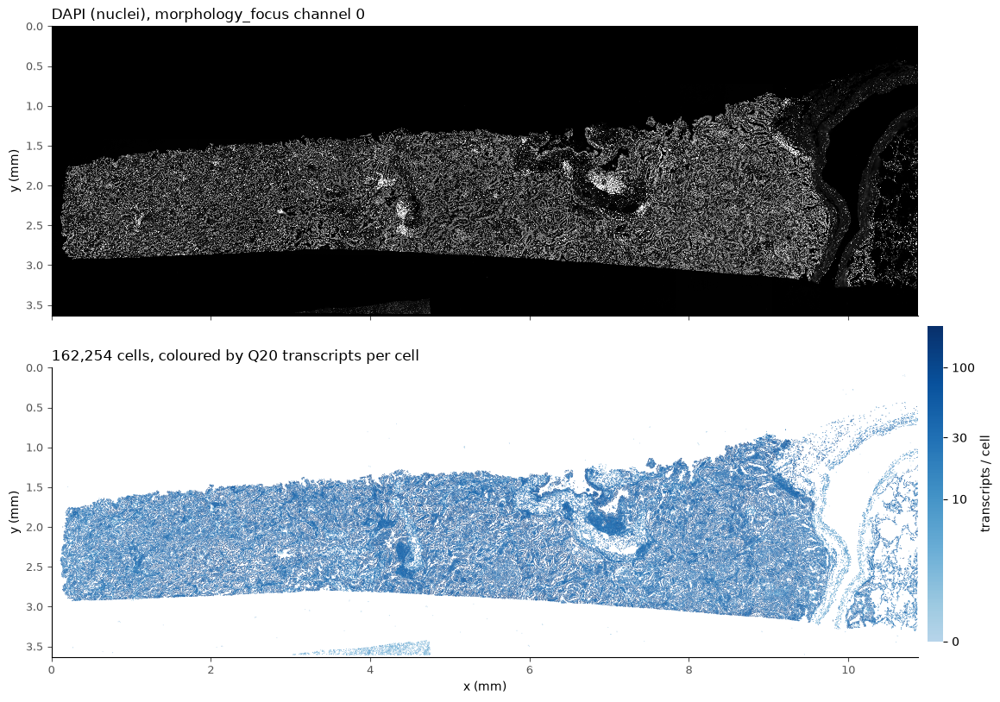

Median 46 transcripts/cell; 0.2% of cells have zero transcripts (flagged in Step 4 QC).


In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Low-resolution pyramid level (scale3, ~8x downsampled): a whole-slide view in < 1 s
LEVEL = "scale3"
dapi = sdata["morphology_focus"][LEVEL]["image"].sel(c="DAPI")
dapi = dapi.values.astype(float)
lo, hi = np.percentile(dapi[dapi > 0], [1, 99.8])
um_per_level_px = PIXEL_SIZE * sdata["morphology_focus"]["scale0"]["image"].shape[-1] / dapi.shape[-1]
extent_mm = [0, dapi.shape[1] * um_per_level_px / 1000, dapi.shape[0] * um_per_level_px / 1000, 0]

xy_mm = table.obsm["spatial"] / 1000
counts = table.obs["transcript_counts"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 9.5), sharex=True, sharey=True,
                         gridspec_kw={"hspace": 0.18})

axes[0].imshow(np.clip((dapi - lo) / (hi - lo), 0, 1), cmap="gray", extent=extent_mm, interpolation="none")
axes[0].set_title("DAPI (nuclei), morphology_focus channel 0", loc="left", fontsize=12)

order = np.argsort(counts)  # draw high-count cells on top
# single-hue sequential ramp; start at a mid-light blue so low-count cells stay visible on white
blues = LinearSegmentedColormap.from_list("blues", plt.get_cmap("Blues")(np.linspace(0.3, 1, 256)))
sc = axes[1].scatter(xy_mm[order, 0], xy_mm[order, 1], c=np.log1p(counts[order]), s=0.4,
                     cmap=blues, vmin=0, vmax=np.log1p(np.percentile(counts, 99)),
                     linewidths=0, rasterized=True)
axes[1].set_title(f"{table.n_obs:,} cells, coloured by Q20 transcripts per cell", loc="left", fontsize=12)
ticks = [0, 10, 30, 100, 300]
# colorbar spans both panels so the two maps stay the same width and aligned
cb = fig.colorbar(sc, ax=axes.tolist(), fraction=0.02, pad=0.01, shrink=0.5, anchor=(0, 0.05),
                  ticks=np.log1p(ticks))
cb.ax.set_yticklabels([str(t) for t in ticks])
cb.set_label("transcripts / cell", fontsize=10)
cb.outline.set_visible(False)

for ax in axes:
    ax.set_aspect("equal")
    ax.set_ylabel("y (mm)")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors="#555555", labelsize=9)
axes[1].set_xlabel("x (mm)")
axes[0].set_xlim(extent_mm[0], extent_mm[1]); axes[0].set_ylim(extent_mm[2], extent_mm[3])
plt.show()
print(f"Median {np.median(counts):.0f} transcripts/cell; "
      f"{(counts == 0).mean():.1%} of cells have zero transcripts (flagged in Step 4 QC).")

## Step 4: Quality control

Assess cell quality before downstream analysis. This targeted Xenium panel contains no mitochondrial genes, so mitochondrial-fraction filtering is not applicable. Quality assessment instead focuses on transcript and gene counts, cell area, negative-control signal, and the spatial distribution of potential segmentation or tissue artefacts.

Work on a copy of the cell table, leaving `sdata` unchanged. If `sdata` is unavailable, reload only the cell table. Preserve raw counts in `layers["counts"]` for Step 5.

This step computes QC metrics (4a), defines filtering criteria (4b), maps QC failures (4c), assesses gene detection against background (4d), and saves the filtered dataset (4e).

### 4a. Compute per-cell QC metrics

Calculate cell-quality metrics before setting thresholds.

Use `qc.add_qc_metrics()` to add detected gene counts, nucleus-to-cell area ratios, transcript density, and negative-control counts and fractions to `.obs`. Control metrics use the columns defined in `xenium.CONTROL_COLUMNS`.

Inspect metric percentiles, the proportions of cells with no nucleus or multiple nuclei, and the frequency of negative-control detection. Compare median transcript counts and cell area across nucleus-count groups.

Note: A cell without a detected nucleus may represent a partial cell in the 5 µm section. Multiple nuclei may indicate multinucleation or merged segmentation. Retain these annotations for assessment rather than filtering on nucleus count at this stage.

In [8]:
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

from ist_analysis import qc   # QC functions shared with the Snakemake pipeline
from ist_analysis.io import xenium   # platform adapter: everything specific to the Xenium bundle

# Step 4 starts from the Step 3a SpatialData object; reload the table if needed
if "sdata" not in globals():
    from pathlib import Path
    from spatialdata_io import xenium
    DATA_ROOT = Path("~/data/xenium_lung").expanduser()
    SAMPLE = "Xenium_V1_humanLung_Cancer_FFPE"
    OUTS_DIR = DATA_ROOT / SAMPLE / "outs"
    sdata = xenium(OUTS_DIR, morphology_focus=False, cells_labels=False, nucleus_labels=False,
                   transcripts=False, cells_boundaries=False, nucleus_boundaries=False)

adata = sdata.tables["table"].copy()   # work on a copy; sdata stays untouched
adata.layers["counts"] = adata.X.copy()  # keep raw counts; normalisation comes in Step 5

# ---- Per-cell QC metrics (qc.add_qc_metrics) ----------------------------------------
# n_genes, nucleus_ratio, density (transcripts / um^2), control_counts and control_frac (controls / gene counts)
qc.add_qc_metrics(adata, control_columns=xenium.CONTROL_COLUMNS)   # Xenium: probe + codeword controls
obs = adata.obs

METRICS = {
    "transcript_counts": "Q20 gene transcripts",
    "n_genes": "Genes detected",
    "cell_area": "Cell area (um^2)",
    "nucleus_area": "Nucleus area (um^2)",
    "nucleus_ratio": "Nucleus / cell area",
    "density": "Transcripts per um^2",
    "control_counts": "Negative-control counts",
}
summary = obs[list(METRICS)].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary.index = [METRICS[m] for m in summary.index]
display(summary.drop(columns=["count"]).style.format("{:.2f}"))

print(f"Cells: {adata.n_obs:,}")
print(f"  no nucleus (nucleus_count = 0):  {(obs['nucleus_count'] == 0).sum():>7,} "
      f"({(obs['nucleus_count'] == 0).mean():.1%})  likely nucleus outside the 5 um section")
print(f"  multinucleate (>= 2 nuclei):     {(obs['nucleus_count'] >= 2).sum():>7,} "
      f"({(obs['nucleus_count'] >= 2).mean():.1%})  possible merged cells")
print(f"  any negative-control count:      {(obs['control_counts'] > 0).sum():>7,} "
      f"({(obs['control_counts'] > 0).mean():.2%})  background is negligible")

print("\nMedian size and counts by number of nuclei (merged cells scale up with nuclei):")
display(obs.groupby("nucleus_count", observed=True)[["transcript_counts", "cell_area"]]
        .median().join(obs["nucleus_count"].value_counts().rename("cells")).head(6).T.round(0))

,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Q20 gene transcripts,56.59,42.42,0.00,3.00,10.00,27.00,46.00,75.00,140.00,202.47,549.00
Genes detected,30.20,15.08,0.00,3.00,8.00,19.00,29.00,40.00,57.00,71.00,119.00
Cell area (um^2),72.56,46.84,2.62,11.83,20.23,38.74,60.51,94.87,163.33,229.62,725.12
Nucleus area (um^2),34.02,22.21,2.12,5.69,8.35,17.39,27.77,46.51,76.95,101.65,264.25
Nucleus / cell area,0.49,0.17,0.03,0.13,0.21,0.37,0.49,0.60,0.75,0.88,1.00
Transcripts per um^2,0.79,0.31,0.00,0.08,0.29,0.58,0.78,0.99,1.31,1.57,2.84
Negative-control counts,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00


Cells: 162,254
  no nucleus (nucleus_count = 0):    5,626 (3.5%)  likely nucleus outside the 5 um section
  multinucleate (>= 2 nuclei):       7,200 (4.4%)  possible merged cells
  any negative-control count:          555 (0.34%)  background is negligible

Median size and counts by number of nuclei (merged cells scale up with nuclei):


nucleus_count,0.0,1.0,2.0,3.0,4.0,5.0
transcript_counts,29.0,45.0,106.0,154.0,198.0,241.0
cell_area,41.0,60.0,127.0,187.0,240.0,291.0
cells,5626.0,149428.0,6131.0,915.0,122.0,22.0


### 4b. Define thresholds and flag cells

Set the criteria for retaining cells and quantify the contribution of each filtering rule.

The thresholds are defined as variables:

- `MIN_COUNTS = 10`: minimum transcript count.
- `MIN_GENES = 5`: minimum detected gene count.
- `AREA_NMADS = 3`: cell-area bounds based on median absolute deviation (MAD) on the log scale.
- `MAX_CONTROL_FRAC = 0.05`: maximum negative-control fraction.

A MAD-based transcript-count threshold is also calculated for comparison with the fixed count floor.

Inspect the area bounds, cells flagged by each rule, cells flagged exclusively by each rule, and the total number passing QC. Review metric distributions with marked cutoffs and the transcript-count-versus-gene-count scatter plot.

Note: Cells may fail multiple criteria. Results are stored in `obs["qc_pass"]` and `obs["qc_fail_reason"]`.

Why fixed cutoffs for counts but MAD for area?
  A 5-MAD lower bound on counts is 0.10 transcripts: the long low tail
  inflates the MAD, so it would remove nothing. A fixed floor is more meaningful.
  Cell area is roughly log-normal, so 3 MADs gives sensible bounds: 7.7 - 435.4 um^2



,cells flagged,% of cells,flagged ONLY by this rule
counts < 10,"7,782",4.80,"4,466"
genes < 5,"3,210",1.98,3
area < 7.7 um^2,316,0.19,28
area > 435 um^2,10,0.01,10
control frac > 5%,42,0.03,37


Pass: 154,394 cells (95.2%); removed: 7,860


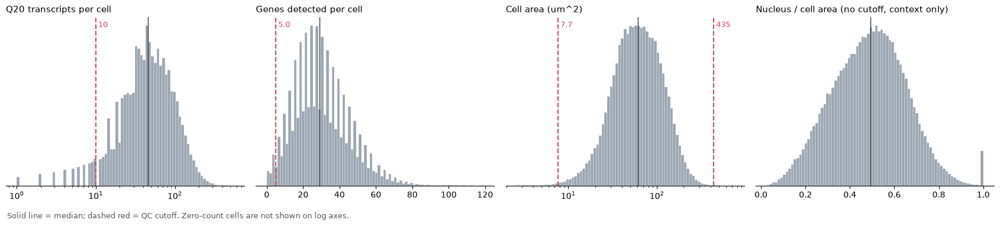

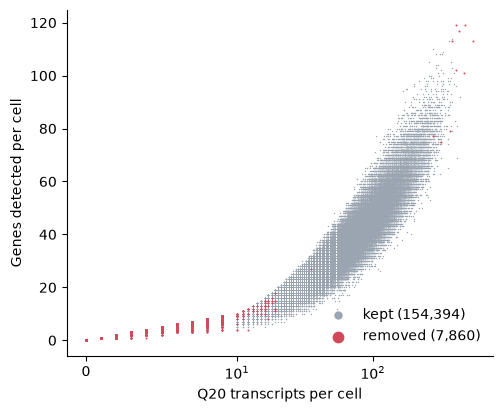

In [9]:
import matplotlib.pyplot as plt

# ---- Thresholds (edit these; everything below follows) -------------------------------
MIN_COUNTS = 10          # fixed: below this a cell cannot be typed reliably on a 377-gene panel
MIN_GENES = 5            # fixed: at least a handful of distinct genes
AREA_NMADS = 3           # data-driven: cell area outliers on log scale (fragments / merged cells)
MAX_CONTROL_FRAC = 0.05  # background: drop cells where control counts exceed 5% of gene counts

from ist_analysis.utils import mad_bounds   # median +/- n MADs on the log1p scale

area_lo, area_hi = mad_bounds(obs["cell_area"].to_numpy(), AREA_NMADS)
counts_mad_lo, _ = mad_bounds(obs["transcript_counts"].to_numpy(), 5)

print("Why fixed cutoffs for counts but MAD for area?")
print(f"  A 5-MAD lower bound on counts is {counts_mad_lo:.2f} transcripts: the long low tail")
print("  inflates the MAD, so it would remove nothing. A fixed floor is more meaningful.")
print(f"  Cell area is roughly log-normal, so 3 MADs gives sensible bounds: "
      f"{area_lo:.1f} - {area_hi:.1f} um^2\n")

# ---- Flags (one boolean per rule, so you can see what each rule removes) ------------
flags, _ = qc.qc_flags(obs, MIN_COUNTS, MIN_GENES, AREA_NMADS, MAX_CONTROL_FRAC)
obs["qc_pass"] = ~flags.any(axis=1)
obs["qc_fail_reason"] = flags.apply(lambda r: "; ".join(r.index[r]) or "pass", axis=1)
rule_table = qc.rule_table(flags)
display(rule_table.style.format({"cells flagged": "{:,}", "% of cells": "{:.2f}",
                                 "flagged ONLY by this rule": "{:,}"}))
print(f"Pass: {obs['qc_pass'].sum():,} cells ({obs['qc_pass'].mean():.1%}); "
      f"removed: {(~obs['qc_pass']).sum():,}")

# ---- Distributions with the cutoffs drawn on them ----------------------------------
KEPT, CUT, INK = "#9aa5b1", "#d1495b", "#333333"
panels = [
    ("transcript_counts", "Q20 transcripts per cell", True, [MIN_COUNTS]),
    ("n_genes", "Genes detected per cell", False, [MIN_GENES]),
    ("cell_area", "Cell area (um^2)", True, [area_lo, area_hi]),
    ("nucleus_ratio", "Nucleus / cell area (no cutoff, context only)", False, []),
]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, (col, label, logx, cuts) in zip(axes, panels):
    x = obs[col].dropna().to_numpy()
    if logx:
        x = x[x > 0]
        bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 80)
        ax.set_xscale("log")
    else:
        bins = 80
    ax.hist(x, bins=bins, color=KEPT, edgecolor="white", linewidth=0.3)
    for c in cuts:
        ax.axvline(c, color=CUT, lw=1.5, ls="--")
        ax.annotate(f"{c:,.0f}" if c >= 10 else f"{c:.1f}", (c, 1), xycoords=("data", "axes fraction"),
                    xytext=(3, -12), textcoords="offset points", color=CUT, fontsize=9)
    ax.axvline(np.median(x), color=INK, lw=1)
    ax.set_title(label, loc="left", fontsize=10.5)
    ax.set_yticks([])
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
fig.text(0.01, -0.04, "Solid line = median; dashed red = QC cutoff. Zero-count cells are not shown on log axes.",
         fontsize=9, color="#555555")
plt.tight_layout()
plt.show()

# Counts vs genes: the classic two-metric QC view
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(obs.loc[obs.qc_pass, "transcript_counts"], obs.loc[obs.qc_pass, "n_genes"],
           s=1, c=KEPT, linewidths=0, rasterized=True, label=f"kept ({obs.qc_pass.sum():,})")
ax.scatter(obs.loc[~obs.qc_pass, "transcript_counts"], obs.loc[~obs.qc_pass, "n_genes"],
           s=2, c=CUT, linewidths=0, rasterized=True, label=f"removed ({(~obs.qc_pass).sum():,})")
ax.set_xscale("symlog", linthresh=10)
ax.set_xlabel("Q20 transcripts per cell")
ax.set_ylabel("Genes detected per cell")
ax.legend(frameon=False, markerscale=6, loc="lower right")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

### 4c. Map the spatial distribution of QC failures

Assess whether QC failures cluster near tissue edges, within imaging tiles, or in specific tissue regions.

Assign each cell to the imaging tile containing its centroid. Summarise cell counts, median transcripts per cell, the fraction of gene transcripts with `qv >= 20`, and the percentage of cells failing QC. Among tiles with at least 200 cells, flag those whose median counts or quality-pass fractions have a robust absolute z-score greater than 3.

Inspect the spatial maps and outlier-tile summary. Edge-associated failures may reflect tissue damage, while sharply tile-shaped patterns may indicate imaging artefacts. Region-specific patterns require review before being treated as technical failures.

Note: Adjacent tiles overlap by approximately 2 µm. Cells with centroids in an overlap are assigned to the first matching tile.

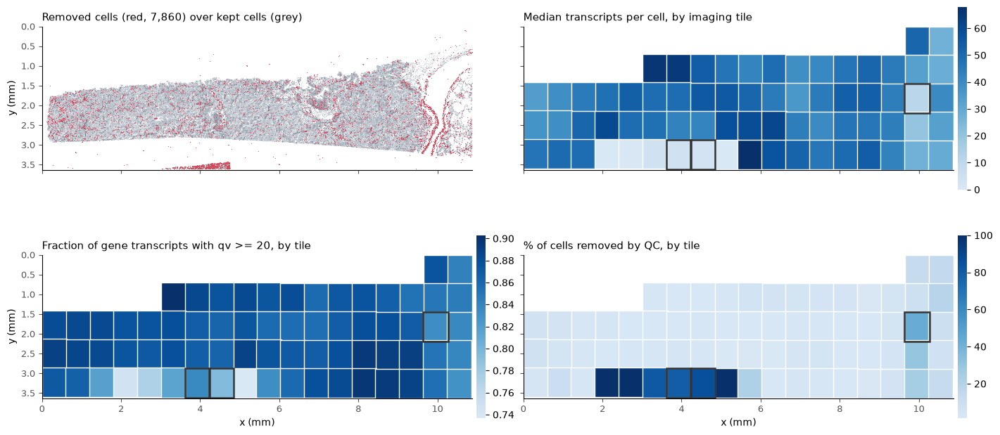

69 imaging tiles of 629 x 748 um. Tiles flagged as outliers (black outline, robust |z| > 3): 3


,cells,median_counts,frac_q20,pct_removed
fov,,,,
C18,452,11.0,0.83,43.14
E8,378,4.0,0.84,79.63
E9,544,3.0,0.79,85.48


Read the maps together: removed cells scattered along tissue edges and folds are expected;
a whole tile standing out (sharp square edges) would point to an imaging artifact.


In [10]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

# ---- Imaging tiles (fields of view): positions in um and Q20 fraction per tile ----------
fov = xenium.fov_table(OUTS_DIR)
xy = adata.obsm["spatial"]
obs["fov"] = pd.Categorical(qc.assign_fov(xy, fov))   # tile under each centroid (tiles overlap ~2 um; first match wins)
# Per tile: cells, median counts, % removed; outlier = robust |z| > 3 on median counts or Q20 (tiles with >= 200 cells)
fov = qc.fov_outliers(fov, obs)

# ---- Plot: removed cells + three per-tile metrics --------------------------------------
blues = LinearSegmentedColormap.from_list("blues", plt.get_cmap("Blues")(np.linspace(0.15, 1, 256)))
fig, axes = plt.subplots(2, 2, figsize=(17, 7.6), sharex=True, sharey=True,
                         gridspec_kw={"hspace": 0.25, "wspace": 0.08})
xmm, ymm = xy[:, 0] / 1000, xy[:, 1] / 1000

ax = axes[0, 0]
ax.scatter(xmm[obs.qc_pass], ymm[obs.qc_pass], s=0.1, c=KEPT, linewidths=0, rasterized=True)
ax.scatter(xmm[~obs.qc_pass], ymm[~obs.qc_pass], s=0.6, c=CUT, linewidths=0, rasterized=True)
ax.set_title(f"Removed cells (red, {(~obs.qc_pass).sum():,}) over kept cells (grey)", loc="left", fontsize=11)
# empty colorbar slot keeps this panel the same width as the three tile panels
fig.colorbar(plt.cm.ScalarMappable(cmap=blues), ax=ax, fraction=0.025, pad=0.01).ax.set_visible(False)

tile_panels = [
    (axes[0, 1], "median_counts", "Median transcripts per cell, by imaging tile", "{:.0f}"),
    (axes[1, 0], "frac_q20", "Fraction of gene transcripts with qv >= 20, by tile", "{:.2f}"),
    (axes[1, 1], "pct_removed", "% of cells removed by QC, by tile", "{:.0f}%"),
]
for ax, col, title, fmt in tile_panels:
    vals = fov[col]
    norm = plt.Normalize(vals.min(), vals.max())
    for name, r in fov.iterrows():
        ax.add_patch(Rectangle((r.x / 1000, r.y / 1000), r.width / 1000, r.height / 1000,
                               facecolor=blues(norm(r[col])), edgecolor="white", linewidth=1))
    for name, r in fov[fov.outlier].iterrows():  # outlines last, so neighbours do not cover them
        ax.add_patch(Rectangle((r.x / 1000, r.y / 1000), r.width / 1000, r.height / 1000,
                               fill=False, edgecolor=INK, linewidth=1.8, zorder=3))
    sm = plt.cm.ScalarMappable(norm=norm, cmap=blues)
    cb = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
    cb.outline.set_visible(False)
    ax.set_title(title, loc="left", fontsize=11)

for ax in axes.flat:
    ax.set_aspect("equal")
    ax.set_xlim(0, fov.eval("x + width").max() / 1000)
    ax.set_ylim(fov.eval("y + height").max() / 1000, 0)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(colors="#555555", labelsize=9)
for ax in axes[1]:
    ax.set_xlabel("x (mm)")
for ax in axes[:, 0]:
    ax.set_ylabel("y (mm)")
plt.show()

n_out = int(fov["outlier"].sum())
print(f"{len(fov)} imaging tiles of {fov.width.iloc[0]:.0f} x {fov.height.iloc[0]:.0f} um. "
      f"Tiles flagged as outliers (black outline, robust |z| > 3): {n_out}")
if n_out:
    display(fov.loc[fov.outlier, ["cells", "median_counts", "frac_q20", "pct_removed"]].round(2))
print("Read the maps together: removed cells scattered along tissue edges and folds are expected;\n"
      "a whole tile standing out (sharp square edges) would point to an imaging artifact.")

### 4d. Assess gene detection against background

Evaluate gene detection relative to negative-control probes before interpreting expression patterns.

Use `xenium.gene_detection()` to compare gene transcript totals with the 20 negative-control probes. The output also reports the fraction of cells detecting each gene and the fraction of transcripts assigned to nuclei. Genes with totals at or below twice the highest control-probe total are flagged as near background.

Inspect the background summary, near-background gene count, ranked detection plot, and tables of weakly detected and selected immune genes.

Note: This step flags genes but does not remove them. Detection above background does not necessarily provide sufficient coverage for cell-type annotation. Low-abundance immune checkpoint genes are interpreted later (Step 9) as the percentage of positive cells within each cell type, compared with a background noise floor, rather than as individual cell-type markers.

Negative-control probes: mean 19.6, max 69 counts per probe (whole slide)
Genes at or below 2x the highest control probe: 0 of 377
Weakest gene: UMOD with 175 counts (8.9x background) -> all genes are kept



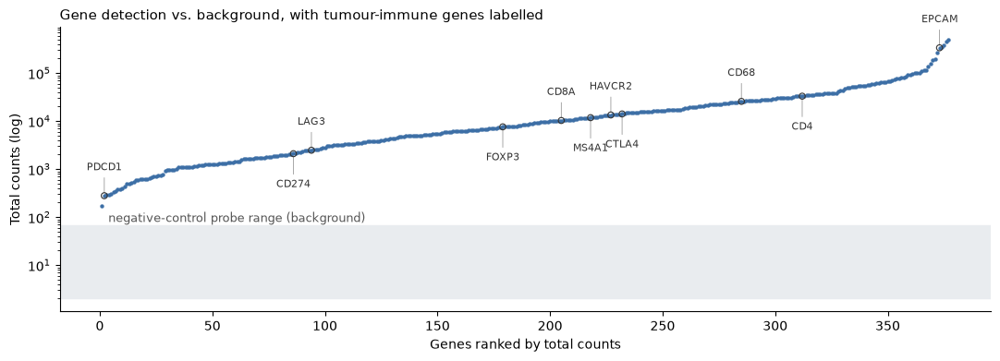

Weakest 8 and selected tumour-immune genes:


,total_counts,pct_cells_detected,fold_over_background,pct_in_nucleus
UMOD,175,0.10,9x,77
PDCD1,279,0.17,14x,73
LY6D,288,0.17,15x,75
CD70,293,0.18,15x,73
SST,305,0.18,16x,82
CCL27,333,0.20,17x,79
TCF15,342,0.21,17x,78
MLANA,378,0.22,19x,70
CD8A,"10,282",4.51,523x,59
CD4,"33,038",14.92,"1,681x",43


pct_in_nucleus near 50% is typical; much lower = cytoplasmic/secreted transcripts, much higher = nuclear-retained.


In [11]:
# ---- Gene-level QC: is each gene detected above background? -------------------------
# Totals per gene vs negative-control probes, % of cells detected, and % of Q20 cell-assigned transcripts in a nucleus
genes, neg_probe = xenium.gene_detection(OUTS_DIR, adata.layers["counts"], nucleus_fraction=True)
bg_mean, bg_max = neg_probe.mean(), neg_probe.max()
n_low = int((genes["total_counts"] <= 2 * bg_max).sum())
print(f"Negative-control probes: mean {bg_mean:.1f}, max {bg_max:.0f} counts per probe (whole slide)")
print(f"Genes at or below 2x the highest control probe: {n_low} of {len(genes)}")
print(f"Weakest gene: {genes.index[0]} with {genes.total_counts.iloc[0]:.0f} counts "
      f"({genes.fold_over_background.iloc[0]:.1f}x background) -> all genes are kept\n")

# Ranked detection plot with the background band
fig, ax = plt.subplots(figsize=(13, 4))
rank = np.arange(1, len(genes) + 1)
ax.axhspan(neg_probe.min(), bg_max, color="#e9ecef", zorder=0)
ax.text(len(genes) * 0.01, bg_max * 1.15, "negative-control probe range (background)", fontsize=9, color="#555555")
ax.scatter(rank, genes["total_counts"], s=10, c="#3d6fa6", linewidths=0, zorder=2)
ax.set_yscale("log")
TIME_GENES = ["CD8A", "CD4", "FOXP3", "PDCD1", "CD274", "CTLA4", "LAG3", "HAVCR2", "MS4A1", "CD68", "EPCAM", "MKI67"]
# alternate labels above/below the curve so neighbours do not collide
PLOT_LABELS = [g for g in TIME_GENES if g != "MKI67"]  # MKI67 sits next to MS4A1; shown in the table
labelled = sorted((genes.index.get_loc(g), g) for g in PLOT_LABELS if g in genes.index)
for k, (i, g) in enumerate(labelled):
    up = k % 2 == 0
    ax.annotate(g, (rank[i], genes.total_counts.iloc[i]), xytext=(0, 22 if up else -24),
                textcoords="offset points", ha="center", va="center", fontsize=8, color=INK,
                arrowprops=dict(arrowstyle="-", color="#999999", lw=0.6))
    ax.scatter(rank[i], genes.total_counts.iloc[i], s=22, facecolors="none", edgecolors=INK, lw=0.8, zorder=3)
ax.set_xlabel("Genes ranked by total counts")
ax.set_ylabel("Total counts (log)")
ax.set_title("Gene detection vs. background, with tumour-immune genes labelled", loc="left", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

print("Weakest 8 and selected tumour-immune genes:")
display(pd.concat([genes.head(8), genes.loc[[g for g in TIME_GENES if g in genes.index]]])
        .style.format({"total_counts": "{:,.0f}", "pct_cells_detected": "{:.2f}",
                       "fold_over_background": "{:,.0f}x", "pct_in_nucleus": "{:.0f}"}))
print("pct_in_nucleus near 50% is typical; much lower = cytoplasmic/secreted transcripts, "
      "much higher = nuclear-retained.")

### 4e. Apply the QC filter and save

Retain cells that pass QC and save the filtered dataset for Step 5.

Use `qc.filter_cells()` to select cells with `qc_pass`. Filtering thresholds, area bounds, and the count definition are recorded in `.uns["qc_params"]`.

Inspect the before-and-after cell counts, median transcript and gene counts, and the most common reasons for removal.

Note: The filtered AnnData object is saved to `~/data/xenium_lung/processed/` with raw counts, QC metrics, and cell centroids. Saving overwrites any existing file with the same name. Step 5 loads this file directly, so Steps 3–4 do not need to be repeated.

In [12]:
# ---- Apply the filter --------------------------------------------------------------
n_before, tx_before = adata.n_obs, int(obs["transcript_counts"].sum())
# QC parameters travel with the data (.uns['qc_params']), so anyone opening the file knows how it was made
adata_qc = qc.filter_cells(adata, obs["qc_pass"].to_numpy(), {
    "min_counts": MIN_COUNTS, "min_genes": MIN_GENES, "area_nmads": AREA_NMADS,
    "area_bounds_um2": [float(area_lo), float(area_hi)], "max_control_frac": MAX_CONTROL_FRAC,
    "count_filter": "gene transcripts with qv >= 20 assigned to a cell (10x default)",
})
n_after, tx_after = adata_qc.n_obs, int(adata_qc.obs["transcript_counts"].sum())

display(pd.DataFrame({
    "before QC": [n_before, tx_before, obs["transcript_counts"].median(), obs["n_genes"].median()],
    "after QC": [n_after, tx_after, adata_qc.obs["transcript_counts"].median(), adata_qc.obs["n_genes"].median()],
}, index=["cells", "transcripts in cells", "median transcripts / cell", "median genes / cell"])
  .assign(retained=lambda d: (d["after QC"] / d["before QC"]).map("{:.1%}".format))
  .style.format({"before QC": "{:,.0f}", "after QC": "{:,.0f}"}))

print("\nWhy cells were removed (a cell can fail several rules):")
display(obs.loc[~obs.qc_pass, "qc_fail_reason"].value_counts().head(8).rename("cells").to_frame())

# ---- Save outside OneDrive -----------------------------------------------------------
PROCESSED_DIR = DATA_ROOT / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_path = PROCESSED_DIR / f"{SAMPLE}_qc.h5ad"
adata_qc.write_h5ad(out_path, compression="gzip")
print(f"\nSaved: ~/data/xenium_lung/processed/{out_path.name} "
      f"({out_path.stat().st_size / 1e6:.1f} MB): {n_after:,} cells x {adata_qc.n_vars} genes")
print("Contains raw counts (.X and .layers['counts']), QC metrics in .obs, "
      "centroids (um) in .obsm['spatial'], and .uns['qc_params'].")

,before QC,after QC,retained
cells,"162,254","154,394",95.2%
transcripts in cells,"9,182,510","9,134,985",99.5%
median transcripts / cell,46,48,104.3%
median genes / cell,29,29,100.0%



Why cells were removed (a cell can fail several rules):


,cells
qc_fail_reason,
counts < 10,4466
counts < 10; genes < 5,3023
counts < 10; genes < 5; area < 7.7 um^2,182
counts < 10; area < 7.7 um^2,106
control frac > 5%,37
area < 7.7 um^2,28
area > 435 um^2,10
genes < 5,3



Saved: ~/data/xenium_lung/processed/Xenium_V1_humanLung_Cancer_FFPE_qc.h5ad (33.4 MB): 154,394 cells x 377 genes
Contains raw counts (.X and .layers['counts']), QC metrics in .obs, centroids (um) in .obsm['spatial'], and .uns['qc_params'].


## Step 5: Normalisation and clustering

Group cells by expression similarity without using prior cell-type labels. Normalise counts, reduce dimensionality, construct a neighbour graph, and identify clusters using Leiden clustering.

Load the filtered dataset from Step 4; Steps 3–4 do not need to be repeated. The neighbour graph, Leiden clusters, and UMAP are cached in the Step 5 output file. Set `RECOMPUTE = True` in Step 5a to regenerate them. Recomputing takes several minutes, primarily for UMAP.

The workflow uses the following settings:

| Stage | Purpose | Setting |
|---|---|---|
| Normalisation | Adjust for differences in transcript totals | Normalise to the median library size, then apply `log1p` |
| Gene selection | Define features for clustering | Retain all 377 panel genes; skip highly variable gene selection |
| Scaling and PCA | Standardise gene contributions and reduce dimensionality | Scale to unit variance, clip at 10, and compute 50 PCs |
| Neighbour graph | Connect transcriptionally similar cells | Use 15 neighbours and the first 30 PCs |
| Leiden clustering | Identify graph communities | Evaluate resolutions `0.3`, `0.5`, and `1.0` |
| UMAP | Visualise the neighbour graph | Use for visual inspection, not quantitative distance comparisons |

This step prepares expression data (5a), builds the graph and clusters (5b), visualises clusters (5c), identifies markers (5d), compares with 10x clustering (5e), and saves the result (5f).

### 5a. Normalise and reduce dimensionality

Make cells with different transcript totals comparable and summarise the main axes of expression variation. Select the `spatial_env` kernel before running this cell.

Use `cluster.normalise_and_pca()` to normalise each cell to the median library size and apply `log1p`. Store this expression matrix in `layers["lognorm"]`. Scale genes to unit variance, clip scaled values at 10, and compute 50 principal components. Restore `.X` to log-normalised expression after PCA.

Inspect the variance explained by each component and the cumulative variance captured by the first `N_PCS = 30` components. Check that the selected cutoff lies near the flattening of the variance curve.

Note: All 377 panel genes are retained. Targeted panels can distribute variance across many components, so cumulative explained variance may be lower than in whole-transcriptome analyses.

Loaded QC'd data: 154,394 cells x 377 genes


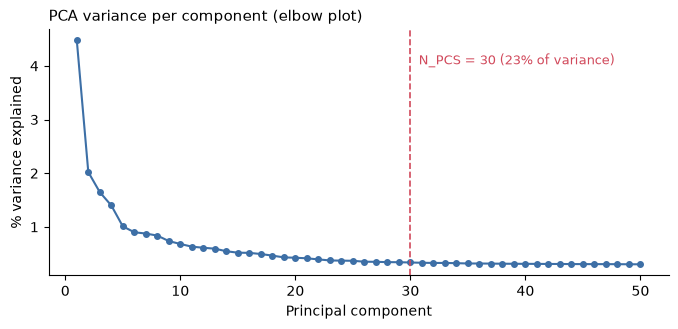

The curve flattens after ~20-30 PCs: later components are mostly noise. Targeted panels spread variance thinly, so 23% in 30 PCs is normal.


In [13]:
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError("Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)'.")

import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

from ist_analysis import cluster
from ist_analysis import utils as xu

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_ROOT, SAMPLE, OUTS_DIR, PROCESSED_DIR = xu.DATA_ROOT, xu.SAMPLE, xu.OUTS_DIR, xu.PROCESSED_DIR
QC_PATH = xu.STEP_FILES["qc"]                # Step 4 output
CLUSTERED_PATH = xu.STEP_FILES["clustered"]  # Step 5 output (cache)

N_PCS = 30                       # chosen from the variance plot below
RESOLUTIONS = [0.3, 0.5, 1.0]    # Leiden resolutions to compare
RECOMPUTE = False                # True = ignore the cache and redo 5b (several minutes, mostly UMAP)

adata = sc.read_h5ad(QC_PATH)
print(f"Loaded QC'd data: {adata.n_obs:,} cells x {adata.n_vars} genes")

# ---- Normalise, scale, PCA (cluster.normalise_and_pca) ---------------------------------
# 1. Total-count normalisation: rescale every cell to the median library size, so a big cell
#    with 200 transcripts and a small one with 20 become comparable; 2. log1p, so a few very
#    high genes do not dominate (layers['lognorm']). No highly-variable-gene selection: all 377
#    panel genes were chosen by design. 3. Scaling (unit variance, clipped at 10 SD) so abundant
#    epithelial genes do not swamp rare immune markers, then PCA to 50 axes. X stays log-normalised.
cluster.normalise_and_pca(adata)

vr = adata.uns["pca"]["variance_ratio"]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(np.arange(1, len(vr) + 1), vr * 100, marker="o", ms=4, lw=1.5, color="#3d6fa6")
ax.axvline(N_PCS, color="#d1495b", ls="--", lw=1.2)
ax.annotate(f"N_PCS = {N_PCS} ({vr[:N_PCS].sum():.0%} of variance)", (N_PCS, vr.max() * 100 * 0.9),
            xytext=(6, 0), textcoords="offset points", color="#d1495b", fontsize=9)
ax.set_xlabel("Principal component")
ax.set_ylabel("% variance explained")
ax.set_title("PCA variance per component (elbow plot)", loc="left", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()
print("The curve flattens after ~20-30 PCs: later components are mostly noise. "
      f"Targeted panels spread variance thinly, so {vr[:N_PCS].sum():.0%} in {N_PCS} PCs is normal.")

### 5b. Build the graph and clusters

Identify transcriptionally similar cell groups at three levels of granularity.

Use `cluster.cluster()` to construct a 15-nearest-neighbour graph from the first `N_PCS` principal components, run Leiden clustering at each value in `RESOLUTIONS`, and compute UMAP. A fixed random seed is used for reproducibility.

If the Step 5 output file exists and `RECOMPUTE = False`, load the cached results after confirming that the cell identifiers match. Inspect the number of clusters and the size of the smallest cluster at each resolution.

Note: Resolution controls clustering granularity, not correctness. Higher values generally produce more, smaller clusters. Assess the working resolution in Step 5c using biological interpretability.

In [14]:
cached = CLUSTERED_PATH.exists() and not RECOMPUTE
if cached:
    # Re-use neighbours, clusters and UMAP from a previous run (UMAP alone takes ~3 min)
    prev = sc.read_h5ad(CLUSTERED_PATH)
    assert prev.obs_names.equals(adata.obs_names), "Cache is from different cells; set RECOMPUTE = True"
    for key in [f"leiden_{r}" for r in RESOLUTIONS]:
        adata.obs[key] = prev.obs[key]
    adata.obsm["X_umap"] = prev.obsm["X_umap"]
    adata.obsp, adata.uns["neighbors"] = prev.obsp, prev.uns["neighbors"]
    print(f"Loaded neighbours, clusters and UMAP from cache: ~/data/xenium_lung/processed/{CLUSTERED_PATH.name}")
    print("(Set RECOMPUTE = True in 5a to redo them.)")
else:
    t0 = time.time()
    # kNN graph in PCA space (who resembles whom), Leiden communities at each resolution
    # (higher = more, smaller clusters), and a UMAP for viewing only
    cluster.cluster(adata, n_pcs=N_PCS, n_neighbors=15, resolutions=RESOLUTIONS, seed=0)
    print(f"Neighbours + Leiden at {RESOLUTIONS} + UMAP: {time.time() - t0:.0f} s")

display(pd.DataFrame({
    "resolution": RESOLUTIONS,
    "clusters": [adata.obs[f"leiden_{r}"].nunique() for r in RESOLUTIONS],
    "smallest cluster (cells)": [adata.obs[f"leiden_{r}"].value_counts().min() for r in RESOLUTIONS],
}).set_index("resolution"))

Loaded neighbours, clusters and UMAP from cache: ~/data/xenium_lung/processed/Xenium_V1_humanLung_Cancer_FFPE_clustered.h5ad
(Set RECOMPUTE = True in 5a to redo them.)


,clusters,smallest cluster (cells)
resolution,,
0.3,10,1004
0.5,14,1028
1.0,19,349


### 5c. Map clusters in expression and tissue space

Assess cluster coherence in expression space and examine their spatial organisation.

Set the working clustering with `CLUSTER_KEY = "leiden_0.5"`. Display clusters on UMAP, with cluster identifiers placed at their median positions, and in tissue-space panels showing each cluster against all remaining cells.

Inspect the UMAP for cluster structure and the tissue maps for plausible patterns, including aggregates, vessel walls, airways, and tumour regions. Review diffuse or salt-and-pepper patterns alongside marker expression before interpreting them.

Note: UMAP is a visualisation, not a quantitative measure of similarity. Distances between clusters should not be interpreted as expression distances.

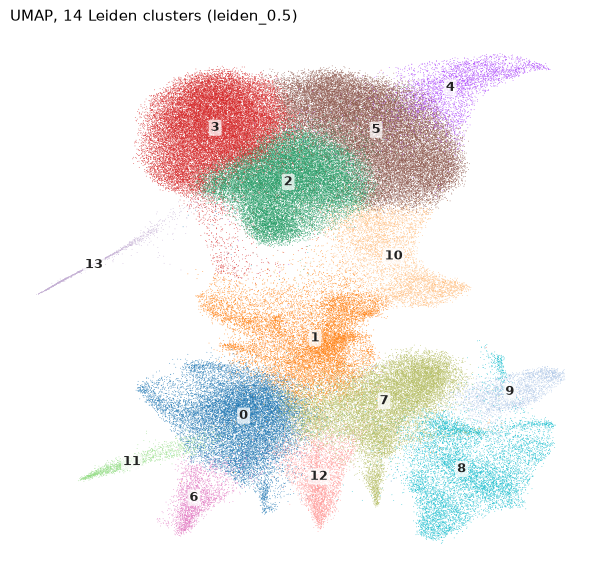

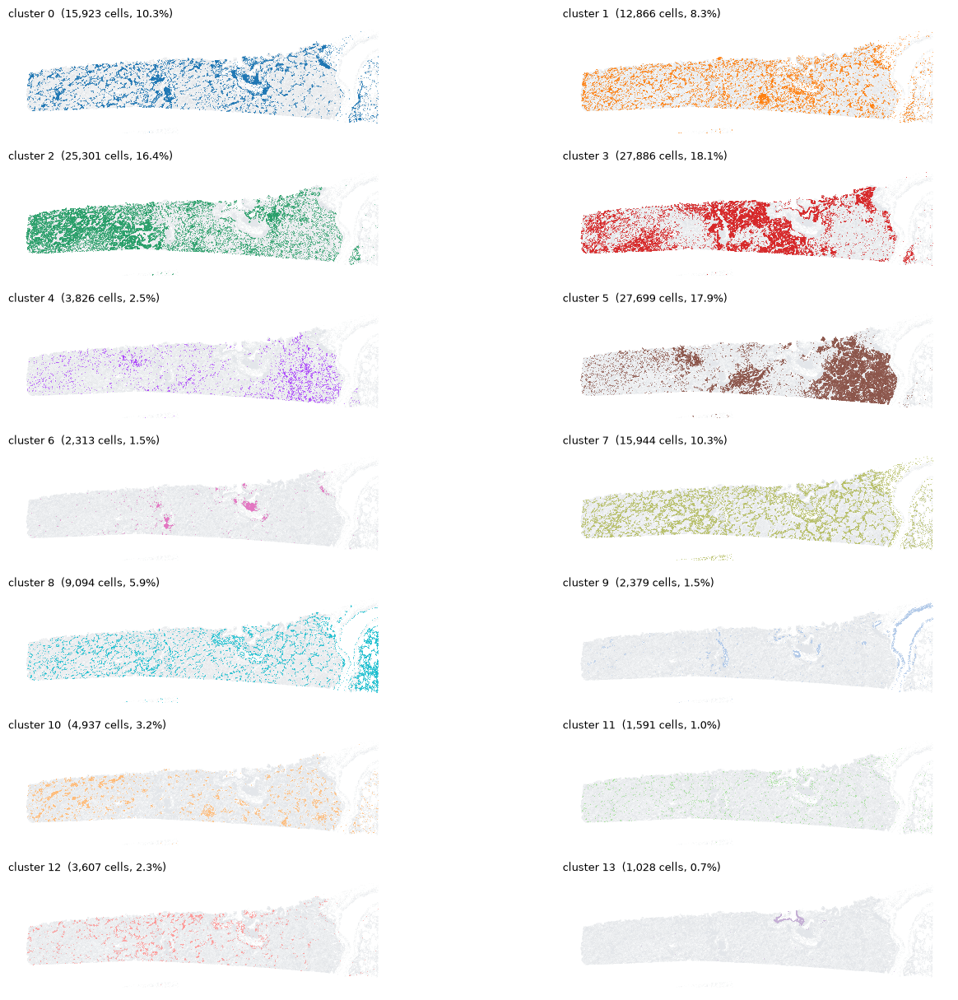

Spatial layout is the first sanity check on clusters: immune and stromal clusters should form
structures (vessels, aggregates, tumour borders), not salt-and-pepper noise.


In [15]:
CLUSTER_KEY = "leiden_0.5"  # working resolution for the rest of the notebook

clusters = adata.obs[CLUSTER_KEY].cat.categories
palette = sc.pl.palettes.default_20 if len(clusters) <= 20 else sc.pl.palettes.default_102
colors = dict(zip(clusters, palette))
adata.uns[f"{CLUSTER_KEY}_colors"] = [colors[c] for c in clusters]


def label_centroids(ax, xy, labels):
    """Write each cluster number at its median position, so identity is not colour-only."""
    for c in clusters:
        m = np.median(xy[labels == c], axis=0)
        ax.text(m[0], m[1], c, fontsize=9, weight="bold", ha="center", va="center",
                color="#222222", bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75))


labels = adata.obs[CLUSTER_KEY].to_numpy()
umap = adata.obsm["X_umap"]
order = np.random.default_rng(0).permutation(adata.n_obs)  # random draw order: no cluster hides another

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.scatter(umap[order, 0], umap[order, 1], s=0.3, c=[colors[l] for l in labels[order]],
           linewidths=0, rasterized=True)
label_centroids(ax, umap, labels)
ax.set_title(f"UMAP, {len(clusters)} Leiden clusters ({CLUSTER_KEY})", loc="left", fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
plt.show()

# ---- Where is each cluster in the tissue? Small multiples, one panel per cluster ----
xy = adata.obsm["spatial"] / 1000  # um -> mm
ncols = 2
nrows = int(np.ceil(len(clusters) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 1.75 * nrows), sharex=True, sharey=True)
for ax, c in zip(axes.flat, clusters):
    m = labels == c
    ax.scatter(xy[~m, 0], xy[~m, 1], s=0.05, c="#e3e6ea", linewidths=0, rasterized=True)
    ax.scatter(xy[m, 0], xy[m, 1], s=0.25, c=colors[c], linewidths=0, rasterized=True)
    ax.set_title(f"cluster {c}  ({m.sum():,} cells, {m.mean():.1%})", loc="left", fontsize=9.5)
axes.flat[0].invert_yaxis()  # image convention: y grows downward (shared by all panels)
for ax in axes.flat:
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
for ax in axes.flat[len(clusters):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()
print("Spatial layout is the first sanity check on clusters: immune and stromal clusters should form\n"
      "structures (vessels, aggregates, tumour borders), not salt-and-pepper noise.")

### 5d. Identify cluster marker genes

Identify genes that distinguish each cluster and support cell-type annotation in Step 6.

Use `cluster.marker_table()` to compare each cluster with all other cells using a Wilcoxon rank-sum test on log-normalised expression. Store results in `.uns["markers"]` and report up to six markers per cluster with adjusted `p < 0.01` and `log2` fold change greater than 1. Display the top three markers per cluster in a dot plot.

Inspect marker specificity, expression level, and the proportion of cells expressing each marker. Prioritise genes that are broadly expressed within their cluster and weakly expressed elsewhere.

Note: Large cell numbers can make small differences statistically significant. Interpret adjusted p-values alongside effect size and expression prevalence; assign cell-type names in Step 6.

,cells,top 6 markers
group,,
0,15923,"TRAC, PTPRC, IL7R, CXCR4, CD2, CD3E"
1,12866,"MS4A6A, MRC1, AIF1, MS4A4A, CD163, C1orf162"
2,25301,"MALL, EPCAM, TCIM, SFTA2, PCSK2, GPRC5A"
3,27886,"CYP2B6, TFPI, TCIM, MALL, CFTR, CAPN8"
4,3826,"TOP2A, CENPF, EPCAM, MKI67, CDK1, PCNA"
5,27699,"MYC, CAPN8, EPCAM, KRT7, GPRC5A, TMC5"
6,2313,"MS4A1, CXCR4, BANK1, CD79A, PTPRC, CD19"
7,15944,"LTBP2, PDGFRA, FBN1, COL5A2, INMT, PDGFRB"
8,9094,"PECAM1, VWF, CAVIN1, CD93, CD34, CLEC14A"


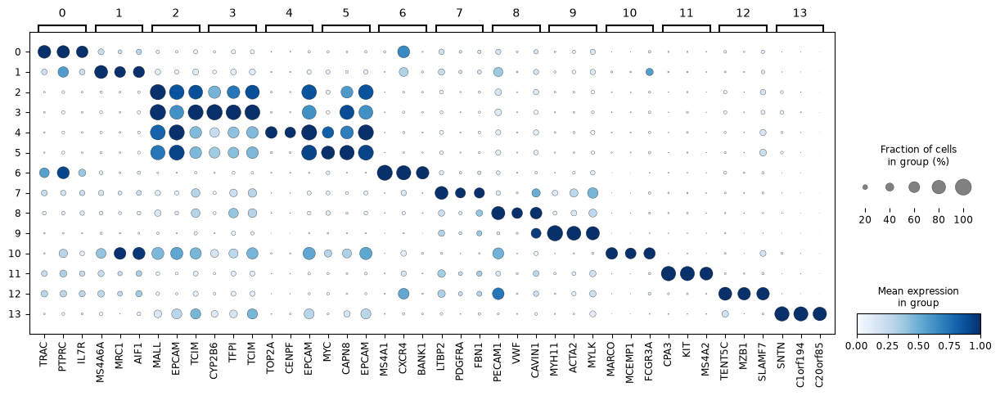

Read each row: a good marker is big and dark in its own cluster and small/pale elsewhere.
Naming the clusters (cell-type annotation) is Step 6.


In [16]:
# ---- Marker genes: what makes each cluster different from all others? -------------
# Wilcoxon rank-sum test, each cluster vs. the rest, on log-normalised expression (stored in uns['markers'])
top_table = cluster.marker_table(adata, CLUSTER_KEY)
display(top_table)

# Dot plot: dot size = % of cells expressing, colour = mean expression (scaled per gene)
sc.pl.rank_genes_groups_dotplot(adata, key="markers", n_genes=3, standard_scale="var",
                                cmap="Blues", dendrogram=False, figsize=(15, 4.8))
print("Read each row: a good marker is big and dark in its own cluster and small/pale elsewhere.\n"
      "Naming the clusters (cell-type annotation) is Step 6.")

### 5e. Compare with 10x clustering

Compare the working results with Xenium Onboard Analysis graph-based clustering as a consistency check.

Use `xenium.vendor_clusters()` to read the 10x cluster assignments from `analysis.tar.gz`. Use `cluster.benchmark_vs_tenx()` to calculate adjusted Rand index (ARI) and normalised mutual information (NMI) at each resolution for shared cells. Store the vendor labels in `obs["tenx_graphclust"]`.

Inspect ARI and NMI across resolutions and the heatmap showing the fraction of each cluster assigned to each 10x cluster. Identify one-to-one correspondences and clusters that split across multiple vendor groups.

Note: The workflows differ in method and cluster number, so complete agreement is not expected. Split correspondences may reflect differences in granularity rather than clustering errors.

10x graph clustering: 24 clusters; 154,394 of our 154,394 cells are in it



,clusters,ARI vs 10x,NMI vs 10x
resolution,,,
0.300000,10,0.44,0.65
0.500000,14,0.51,0.66
1.000000,19,0.49,0.63


ARI: 1 = identical partitions, 0 = random. NMI: shared information, 0-1.
Values of ~0.5-0.65 between methods with different cluster counts mean broad agreement:
the same cell types, split at different granularity.



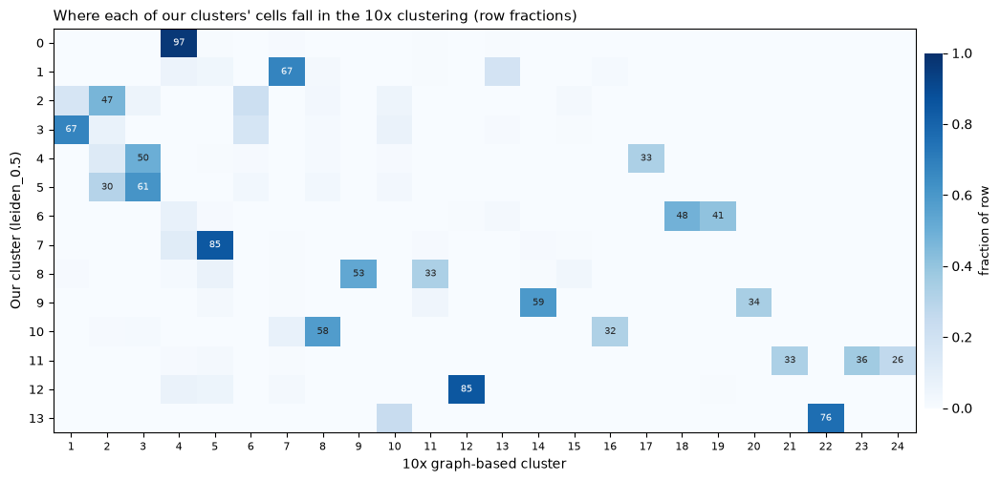

A row with one dark cell = clean 1:1 match. A row split across several 10x clusters = 10x
subdivides that population further (24 clusters vs. our 14). Numbers are % of the row (>= 25% shown).


In [17]:
# ---- Benchmark against 10x's own graph-based clustering ---------------------------
from ist_analysis.io import xenium

tenx = xenium.vendor_clusters(OUTS_DIR)   # 10x's own graph-based clustering
shared = adata.obs_names.intersection(tenx.index)
print(f"10x graph clustering: {tenx.nunique()} clusters; {len(shared):,} of our {adata.n_obs:,} cells are in it\n")
bench = cluster.benchmark_vs_tenx(adata, tenx, RESOLUTIONS)   # also stores obs['tenx_graphclust']
display(bench.style.format({"ARI vs 10x": "{:.2f}", "NMI vs 10x": "{:.2f}"}))
print("ARI: 1 = identical partitions, 0 = random. NMI: shared information, 0-1.\n"
      "Values of ~0.5-0.65 between methods with different cluster counts mean broad agreement:\n"
      "the same cell types, split at different granularity.\n")

# Contingency heatmap: for each of our clusters, which 10x clusters do its cells fall into?
ct = pd.crosstab(adata.obs.loc[shared, CLUSTER_KEY], tenx[shared].astype(str))
ct = ct[sorted(ct.columns, key=int)]
frac = ct.div(ct.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(12, 5.5))
im = ax.imshow(frac.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(frac.shape[1]), frac.columns, fontsize=8)
ax.set_yticks(range(frac.shape[0]), frac.index, fontsize=9)
ax.set_xlabel("10x graph-based cluster")
ax.set_ylabel(f"Our cluster ({CLUSTER_KEY})")
ax.set_title("Where each of our clusters' cells fall in the 10x clustering (row fractions)", loc="left", fontsize=11)
for (i, j), v in np.ndenumerate(frac.to_numpy()):
    if v >= 0.25:
        ax.text(j, i, f"{v:.0%}".replace("%", ""), ha="center", va="center", fontsize=7,
                color="white" if v > 0.6 else "#222222")
cb = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cb.set_label("fraction of row", fontsize=9)
cb.outline.set_visible(False)
plt.show()
print("A row with one dark cell = clean 1:1 match. A row split across several 10x clusters = 10x\n"
      "subdivides that population further (24 clusters vs. our 14). Numbers are % of the row (>= 25% shown).")

### 5f. Save the clustered dataset

Save the normalised and clustered dataset for Step 6 and as the cache used in Step 5b.

Record normalisation, scaling, principal-component count, neighbour count, resolutions, and the working cluster key in `.uns["step5_params"]`.

Inspect the saved file size and confirm that it contains raw-count and log-normalised layers, PCA, the neighbour graph, Leiden assignments, UMAP, marker results, and 10x cluster labels.

Note: The file is saved to `~/data/xenium_lung/processed/` and overwrites any existing file with the same name. Because this file also serves as the clustering cache, saving updates the results reused in Step 5b.

In [18]:
# ---- Save the clustered object (also serves as the cache for 5b) -----------------
adata.uns["step5_params"] = {
    "normalisation": "normalize_total (median library size) + log1p; layers['lognorm']",
    "scaling": "sc.pp.scale(max_value=10) for PCA only",
    "n_pcs": N_PCS, "n_neighbors": 15, "resolutions": RESOLUTIONS, "working_clusters": CLUSTER_KEY,
}
adata.write_h5ad(CLUSTERED_PATH, compression="gzip")
print(f"Saved: ~/data/xenium_lung/processed/{CLUSTERED_PATH.name} "
      f"({CLUSTERED_PATH.stat().st_size / 1e6:.0f} MB)")
print("Contains: counts + lognorm layers, PCA, neighbour graph, Leiden clusters at "
      f"{RESOLUTIONS}, UMAP, markers, and 10x clusters in .obs['tenx_graphclust'].")

Saved: ~/data/xenium_lung/processed/Xenium_V1_humanLung_Cancer_FFPE_clustered.h5ad (113 MB)
Contains: counts + lognorm layers, PCA, neighbour graph, Leiden clusters at [0.3, 0.5, 1.0], UMAP, markers, and 10x clusters in .obs['tenx_graphclust'].


## Step 6: Cell-type annotation

Assign biological identities to the Step 5 clusters using marker expression, marker-set scores, and lineage-specific subclustering. Retain cells with ambiguous profiles and flag them as mixed rather than removing them.

Load the clustered dataset from Step 5; earlier steps do not need to be repeated. Marker sets, coarse labels, subcluster labels, guard markers, and lineage assignments are defined in `config/annotation.yaml`, which is also used by the Snakemake pipeline.

The workflow uses the following stages:

| Stage | Purpose | Setting |
|---|---|---|
| Marker coverage | Establish which canonical markers the panel can measure | Compare configured marker sets with the 377 panel genes |
| Marker-set scoring | Summarise marker expression per cell | Score sets containing at least two panel genes |
| Coarse annotation | Assign a cell type and lineage to each cluster | Apply configured labels supported by markers and scores |
| Subclustering | Resolve populations within selected immune clusters | Subcluster T / NK cluster `0` and myeloid clusters `1` and `10` at Leiden resolution `0.6` |
| Confidence assignment | Flag ambiguous expression profiles | Record confidence as `high` or `mixed` |

This step assesses marker coverage and scores (6a), assigns coarse labels (6b), subclusters T / NK cells (6c) and myeloid cells (6d), and merges and saves the annotation (6e).

### 6a. Assess marker coverage and scores

Establish which cell identities the panel can support and compare marker-set expression across clusters. Select the `spatial_env` kernel before running this cell.

Compare each marker set in `config/annotation.yaml` with the panel genes and report present and missing markers. Use `annotate.score_marker_sets()` to score sets containing at least two panel genes. Scores represent mean marker-set expression relative to a matched reference gene set and are stored in `.obs` with the `score_` prefix.

Use `annotate.cluster_score_z()` to average scores within clusters and standardise each set across clusters.

Inspect the marker-coverage table, cluster-by-set heatmap, and highest-scoring set for each cluster. Pay particular attention to sets represented by few panel genes.

Note: Incomplete marker coverage can reduce specificity, especially when the remaining genes are shared across cell types. Treat marker-set scores as supporting evidence, not automatic labels.

Loaded clustered data: 154,394 cells, 14 clusters



,on panel,missing,n on panel
T cell,"CD3D, CD3E, CD2, TRAC, CD247, IL7R","CD5, CD6",6
CD8 T,"CD8A, GZMK, GZMA, CCL5, NKG7",CD8B,5
Treg,"FOXP3, IL2RA, CTLA4","TNFRSF18, IKZF2",3
NK,"KLRD1, KLRC1, GNLY, PRF1",NCAM1,4
B cell,"MS4A1, CD19, CD79A, BANK1",PAX5,4
Plasma cell,"MZB1, TNFRSF17, DERL3, PRDM1","JCHAIN, XBP1",4
Macrophage,"CD68, CD163, MRC1, MS4A4A","C1QA, APOE",4
Alveolar mac,"MARCO, MCEMP1, PPARG",FABP4,3
Monocyte,"CD14, FCN1, S100A12, VCAN",S100A8,4
Dendritic cell,"CD1C, FCER1A, CLEC10A, LAMP3, CCR7",CLEC9A,5


The Multi-Tissue panel lacks the classic lung epithelial markers (SFTPC, NAPSA, KRT5, TP63,
SCGB1A1): alveolar type 2, basal and club cells CANNOT be resolved here. Annotation is only
as good as the panel; always check marker coverage before naming cells.



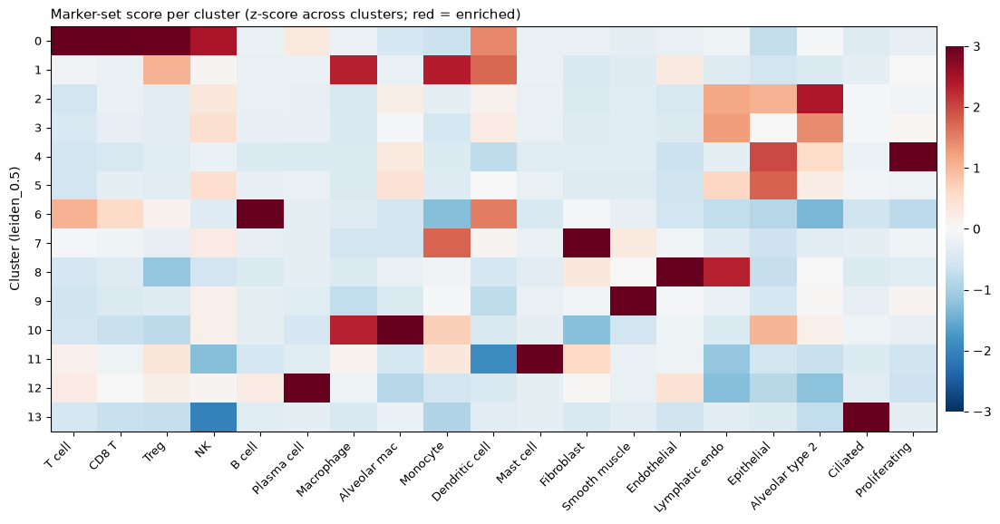

leiden_0.5,0,1,2,3,4,5,6,7,8,9,10,11,12,13
highest-scoring set,CD8 T,Monocyte,Alveolar type 2,Alveolar type 2,Proliferating,Epithelial,B cell,Fibroblast,Endothelial,Smooth muscle,Alveolar mac,Mast cell,Plasma cell,Ciliated
z,3.3,2.4,2.4,1.4,3.4,1.8,3.4,3.1,3.3,3.4,3.2,3.5,3.4,3.4


Automatic 'highest score wins' is a starting point, not an answer: it ignores the panel gaps
and mixed cells. The annotation below is decided cluster by cluster from markers + this heatmap.


In [19]:
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError("Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)'.")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

from ist_analysis import annotate
from ist_analysis import utils as xu

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

CLUSTERED_PATH = xu.STEP_FILES["clustered"]   # Step 5 output
ANNOTATED_PATH = xu.STEP_FILES["annotated"]   # Step 6 output
CLUSTER_KEY = "leiden_0.5"
# All annotation decisions (marker sets, cluster labels, subcluster labels with guard markers) live in
# config/annotation.yaml, shared with the Snakemake pipeline, so there is one source of truth
ANN = annotate.load_annotation(xu.ANNOTATION_FILE)

adata = sc.read_h5ad(CLUSTERED_PATH)
adata.X = adata.layers["lognorm"]
print(f"Loaded clustered data: {adata.n_obs:,} cells, {adata.obs[CLUSTER_KEY].nunique()} clusters\n")

# ---- Canonical marker sets (literature), restricted to genes on this panel ---------
MARKER_SETS = ANN["marker_sets"]
panel = set(adata.var_names)
coverage = pd.DataFrame({
    "on panel": {k: ", ".join(g for g in v if g in panel) for k, v in MARKER_SETS.items()},
    "missing": {k: ", ".join(g for g in v if g not in panel) or "-" for k, v in MARKER_SETS.items()},
    "n on panel": {k: sum(g in panel for g in v) for k, v in MARKER_SETS.items()},
})
display(coverage)
print("The Multi-Tissue panel lacks the classic lung epithelial markers (SFTPC, NAPSA, KRT5, TP63,\n"
      "SCGB1A1): alveolar type 2, basal and club cells CANNOT be resolved here. Annotation is only\n"
      "as good as the panel; always check marker coverage before naming cells.\n")

# ---- Score every cell for every set (mean expression minus a matched random gene set) ----
SETS = annotate.score_marker_sets(adata, MARKER_SETS, seed=0)   # obs['score_<set>']; sets with >= 2 panel genes
# Cluster x cell-type mean score, z-scored across clusters so every column is comparable
z = annotate.cluster_score_z(adata, CLUSTER_KEY, SETS)

fig, ax = plt.subplots(figsize=(13, 5.8))
im = ax.imshow(z.to_numpy(), cmap="RdBu_r", vmin=-3, vmax=3, aspect="auto")
ax.set_xticks(range(z.shape[1]), z.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(z.shape[0]), z.index, fontsize=9)
ax.set_ylabel(f"Cluster ({CLUSTER_KEY})")
ax.set_title("Marker-set score per cluster (z-score across clusters; red = enriched)", loc="left", fontsize=11)
cb = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cb.outline.set_visible(False)
plt.show()

best = z.idxmax(axis=1).rename("highest-scoring set").to_frame()
best["z"] = z.max(axis=1).round(1)
display(best.T)
print("Automatic 'highest score wins' is a starting point, not an answer: it ignores the panel gaps\n"
      "and mixed cells. The annotation below is decided cluster by cluster from markers + this heatmap.")

**Interpretation.** Marker-set best matches agree with seven cluster annotations where panel coverage is adequate. Where coverage is limited, they assign tumour clusters `2` and `3` to alveolar type 2 (a set reduced to `LAMP3` and `SFTA2`) and cluster `1` to monocytes, although its 5d markers indicate CD163+ macrophages.

### 6b. Assign coarse cluster labels

Assign one cell-type label and one lineage to each cluster.

Use `annotate.apply_coarse()` to map clusters in `CLUSTER_KEY` to the cell-type and lineage pairs defined under `coarse` in `config/annotation.yaml`. Store the results in `obs["cell_type_coarse"]` and `obs["lineage"]`.

Inspect the cluster-to-label table, cell counts by label, and canonical-marker dot plot. The cell raises an error if any cluster lacks a configured label, requiring review of the annotation after clustering changes.

Note: Epithelial clusters are provisionally labelled as tumour based on near-zero `AGER` expression and large contiguous tissue regions. This is an inference from marker expression and spatial organisation, not independent confirmation of malignancy.

,cell type,lineage,cells
0,T / NK,T / NK,15923
1,Myeloid,Myeloid,12866
10,Myeloid,Myeloid,4937
2,Tumour epithelial (MALL/TCIM),Epithelial,25301
3,Tumour epithelial (CYP2B6/CFTR),Epithelial,27886
5,Tumour epithelial (MYC/CAPN8),Epithelial,27699
4,Proliferating tumour,Epithelial,3826
13,Ciliated epithelial,Epithelial,1028
6,B cell,B / plasma,2313
12,Plasma cell,B / plasma,3607


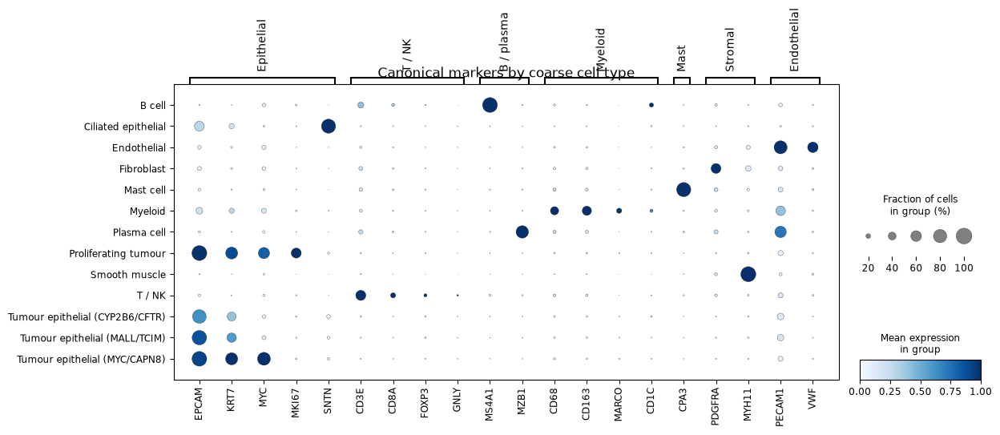

In [20]:
# ---- Coarse annotation: one label per Step 5 cluster ------------------------------
# Decided from the 5d marker table and the 6a heatmap. Epithelial clusters are called
# "tumour" because AGER (normal alveolar type 1) is near zero across the section and
# they form large contiguous masses; without CNV inference this remains an inference.
COARSE = ANN["coarse"]                       # cluster -> [cell type, lineage], from config/annotation.yaml
annotate.apply_coarse(adata, CLUSTER_KEY, COARSE)   # raises if a cluster has no label (did Step 5 change?)

display(pd.DataFrame({k: {"cell type": v[0], "lineage": v[1],
                          "cells": int((adata.obs[CLUSTER_KEY] == k).sum())} for k, v in COARSE.items()}).T)

CANONICAL = {
    "Epithelial": ["EPCAM", "KRT7", "MYC", "MKI67", "SNTN"],
    "T / NK": ["CD3E", "CD8A", "FOXP3", "GNLY"],
    "B / plasma": ["MS4A1", "MZB1"],
    "Myeloid": ["CD68", "CD163", "MARCO", "CD1C"],
    "Mast": ["CPA3"],
    "Stromal": ["PDGFRA", "MYH11"],
    "Endothelial": ["PECAM1", "VWF"],
}
sc.pl.dotplot(adata, CANONICAL, groupby="cell_type_coarse", standard_scale="var", cmap="Blues",
              figsize=(13, 4.8), title="Canonical markers by coarse cell type")

**Interpretation.** Coarse annotation identifies seven lineages, including three similarly sized tumour-labelled clusters. `AGER` is detected in only 1.8% of all 154,394 cells; this supports the tumour label but does not independently confirm malignancy.

### 6c. Subcluster T / NK cells

Resolve populations within coarse cluster `0` and identify cells with mixed or unexpected lineage signals.

Use `annotate.subcluster()` to recompute scaling and PCA within the subset, calculate 30 principal components, and construct a 15-nearest-neighbour graph using the first 20 components. Run Leiden clustering at resolution `0.6` and identify subcluster markers using the Wilcoxon test.

Use `annotate.apply_labels()` to assign configured labels and confidence levels. Each label includes a guard marker that must appear among the subcluster's top ten markers. The cell raises an error if a guard check fails or the subcluster set changes.

Inspect subcluster sizes, leading markers, assigned labels, confidence levels, and the T / NK marker dot plot. Review epithelial, myeloid, and fibroblast signals for possible spillover or unexpected cell identities.

Note: Off-lineage expression may reflect segmentation spillover from neighbouring cells. Retain ambiguous populations with a mixed label. Subcluster labels are tied to numerical identifiers and must be reviewed after changes to upstream parameters.

,cells,top markers,label,confidence
0,2928,"MS4A6A, MRC1, MS4A4A, AIF1, CD14, MPEG1",T / myeloid mixed,mixed
1,3811,"CCL5, CXCL9, GZMK, CD8A, CXCR4, CCL19",CD8 T (GZMK+),high
2,961,"MALL, EPCAM, TFPI, TCIM, CYP2B6, GPRC5A",T / epithelial mixed,mixed
3,852,"CPA3, KIT, MS4A2, IL1RL1, VWA5A, SLC18A2",Mast cell,high
4,681,"CTLA4, FOXP3, TENT5C, TRAC, PTPRC, SLAMF1",Treg,high
5,2577,"IL7R, CAVIN1, VWF, TRAC, KLRB1, CD34",CD4 T,mixed
6,1822,"LTBP2, FBN1, VCAN, INMT, COL5A2, MYLK",T / fibroblast mixed,mixed
7,633,"GNLY, KLRD1, PRF1, KLRC1, CCL5, NKG7",NK,high
8,316,"MMRN1, PROX1, PDPN, GNG11, TFPI, IL7R",Lymphatic endothelial,high
9,872,"MKI67, TOP2A, CDK1, CENPF, CCNB2, PCNA",Proliferating T,high


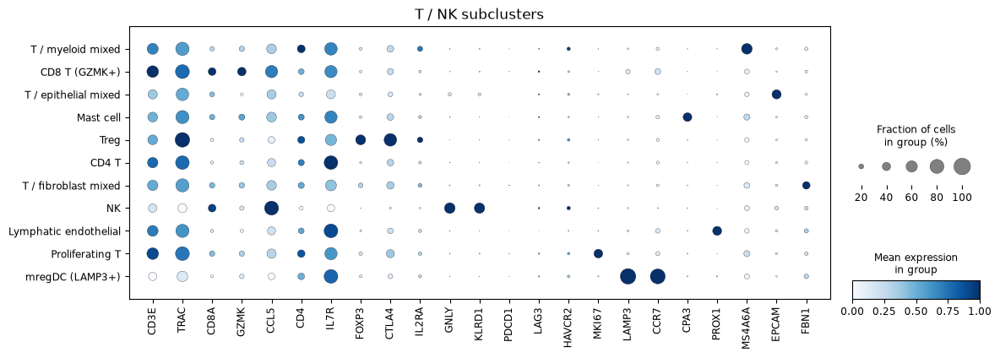

Exhaustion markers (PDCD1, LAG3, HAVCR2) are low and spread out rather than defining a
subcluster: on this panel, T-cell states are better measured per cell (Step 9) than clustered.


In [21]:
# Re-cluster one lineage with its own PCA, so subtle within-lineage differences surface (annotate.subcluster);
# each label names a guard marker that must be in its subcluster's top 10, or annotate.apply_labels raises

# ---- 6c. T / NK cells (cluster 0) -----------------------------------------------------
TNK = ANN["subclusters"]["T_NK"]
tnk = annotate.subcluster(adata, CLUSTER_KEY, TNK["clusters"], ANN["subcluster_resolution"])
TNK_LABELS = TNK["labels"]                   # subcluster: [label, confidence, guard marker]
tnk_table = annotate.apply_labels(tnk, TNK_LABELS, "T / NK")
display(tnk_table)

T_MARKERS = ["CD3E", "TRAC", "CD8A", "GZMK", "CCL5", "CD4", "IL7R", "FOXP3", "CTLA4", "IL2RA",
             "GNLY", "KLRD1", "PDCD1", "LAG3", "HAVCR2", "MKI67", "LAMP3", "CCR7", "CPA3", "PROX1",
             "MS4A6A", "EPCAM", "FBN1"]
sc.pl.dotplot(tnk, T_MARKERS, groupby="cell_type_fine", standard_scale="var", cmap="Blues",
              figsize=(13, 4.2), title="T / NK subclusters")
print("Exhaustion markers (PDCD1, LAG3, HAVCR2) are low and spread out rather than defining a\n"
      "subcluster: on this panel, T-cell states are better measured per cell (Step 9) than clustered.")

**Interpretation.** T / NK subclustering identifies 11 populations, including mast cells, lymphatic endothelial cells and mregDCs that were absorbed into the original T / NK cluster and are reassigned in 6e. Within this subset, 52% of cells are flagged as mixed. A distinct conventional CD4 T-cell population is not reliably resolved, so CD4-specific analyses are not included in Steps 7–9. Exhaustion markers (`PDCD1`, `LAG3`, `HAVCR2`) do not define a subcluster and are assessed per cell in Step 9.

### 6d. Subcluster myeloid cells

Resolve macrophage, monocyte, and dendritic-cell populations within coarse clusters `1` and `10`.

Use `annotate.subcluster()` and `annotate.apply_labels()` with the same PCA, neighbour-graph, Leiden, and guard-marker settings as in Step 6c.

Inspect subcluster sizes, leading markers, labels, and confidence levels. Review the myeloid dot plot for differences in `CD163`, `LYVE1`, `CXCL9`, and `FCGR1A`, alongside markers supporting monocyte and dendritic-cell identities. Check `EPCAM`, `TRAC`, and `FBN1` for off-lineage expression.

Note: Fine-grained labels rest on few markers per population. For example, the `IRF8`+ `DNASE1L3`+ population is distinguished from plasmacytoid dendritic cells only by the low detection of `LILRA4` and `IL3RA`. Interpret fine-grained labels according to the available evidence and retain uncertainty where marker coverage is insufficient.

,cells,top markers,label,confidence
0,2653,"CD1C, CD1E, CLEC10A, CXCR4, FGL2, FCER1A",cDC2,high
1,202,"MNDA, CLEC4E, SELL, IL1R2, AQP9, BASP1",Monocyte,high
2,1925,"MARCO, MCEMP1, PPARG, VSIG4, PECAM1, FCGR3A",Alveolar macrophage,high
3,1918,"PLA2G7, CD68, FCGR3A, IGSF6, FCGR1A, PMP22",FCGR1A+ macrophage,high
4,3213,"EPCAM, KRT7, GPRC5A, MALL, STEAP4, CAPN8",Myeloid / epithelial mixed,mixed
5,414,"MKI67, TOP2A, CDK1, CENPF, UBE2C, CCNB2",Proliferating myeloid,high
6,1664,"TRAC, IL7R, CD3E, CD2, CCL5, PRDM1",Myeloid / T mixed,mixed
7,2467,"MS4A6A, MS4A4A, CD163, IL2RA, MRC1, CD14",CD163+ macrophage,high
8,2100,"LTBP2, MYLK, INMT, FBN1, COL5A2, PDGFRB",Myeloid / fibroblast mixed,mixed
9,261,"CXCL9, CXCL10, CCL5, IL7R, SERPINB9, CD83",CXCL9+ macrophage,high


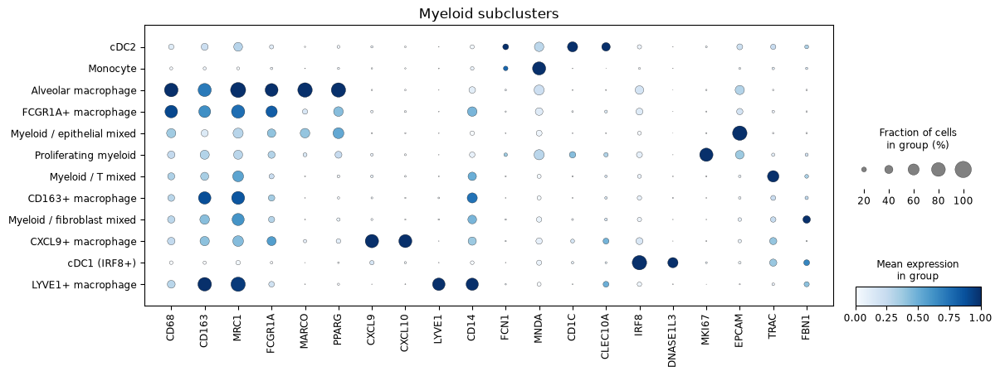

cDC1 vs pDC: IRF8 and DNASE1L3 are shared, but pDC markers LILRA4 and IL3RA are absent here,
so this population is called cDC1.


In [22]:
# ---- 6d. Myeloid cells (clusters 1 + 10) -------------------------------------------
MYE = ANN["subclusters"]["Myeloid"]
mye = annotate.subcluster(adata, CLUSTER_KEY, MYE["clusters"], ANN["subcluster_resolution"])
MYE_LABELS = MYE["labels"]
mye_table = annotate.apply_labels(mye, MYE_LABELS, "Myeloid")
display(mye_table)

M_MARKERS = ["CD68", "CD163", "MRC1", "FCGR1A", "MARCO", "PPARG", "CXCL9", "CXCL10", "LYVE1",
             "CD14", "FCN1", "MNDA", "CD1C", "CLEC10A", "IRF8", "DNASE1L3", "MKI67",
             "EPCAM", "TRAC", "FBN1"]
sc.pl.dotplot(mye, M_MARKERS, groupby="cell_type_fine", standard_scale="var", cmap="Blues",
              figsize=(13, 4.4), title="Myeloid subclusters")
print("cDC1 vs pDC: IRF8 and DNASE1L3 are shared, but pDC markers LILRA4 and IL3RA are absent here,\n"
      "so this population is called cDC1.")

**Interpretation.** Myeloid subclustering identifies 12 populations, including five macrophage populations. Within this subset, 39% of cells are flagged as mixed; the largest mixed group shows epithelial transcripts, consistent with possible segmentation spillover. The `IRF8`+ population is labelled cDC1 because the plasmacytoid dendritic-cell markers `LILRA4` and `IL3RA` are detected at background level (about 2% of its cells).

### 6e. Merge and save annotations

Combine coarse and subcluster labels, review the final composition, and save the annotated dataset for Step 7.

Use `annotate.merge_labels()` to populate `obs["cell_type"]` and `obs["annotation_confidence"]`. Cells outside the subclustered populations retain their coarse labels with confidence set to `high`. Apply `lineage_overrides` so that final lineage assignments follow the final cell-type labels, including mast cells and lymphatic endothelial cells identified within the T / NK subset.

Use `annotate.composition()` to summarise cell-type composition. Record annotation settings and caveats in `.uns["annotation"]` and save the lineage colour palette in `.uns["lineage_colors"]`.

Inspect the composition table, fraction of mixed cells, cells-per-lineage bar chart, and tissue map. Check that lineage assignments and spatial patterns are consistent with the marker evidence.

Note: The file is saved to `~/data/xenium_lung/processed/` and overwrites any existing file with the same name. Retain mixed cells for tissue-level context, but exclude them from cell-type-specific statistics.

cells  % of cells
lineage     cell_type                                         
B / plasma  Plasma cell                       3607        2.34
            B cell                            2313        1.50
Endothelial Endothelial                       9094        5.89
            Lymphatic endothelial              316        0.20
Epithelial  Tumour epithelial (CYP2B6/CFTR)  27886       18.06
            Tumour epithelial (MYC/CAPN8)    27699       17.94
            Tumour epithelial (MALL/TCIM)    25301       16.39
            Proliferating tumour              3826        2.48
            Ciliated epithelial               1028        0.67
Mast        Mast cell                         2443        1.58
Myeloid     Myeloid / epithelial mixed        3213        2.08
            cDC2                              2653        1.72
            CD163+ macrophage                 2467        1.60
            Myeloid / fibroblast mixed        2100        1.36
            Alveolar macrophage               1925        1.25
            FCGR1A+ macrophage                1918        1.24
            Myeloid / T mixed                 1664        1.08
            cDC1 (IRF8+)                       618        0.40
            mregDC (LAMP3+)                    470        0.30
            Proliferating myeloid              414        0.27
            LYVE1+ macrophage                  368        0.24
            CXCL9+ macrophage                  261        0.17
            Monocyte                           202        0.13
Stromal     Fibroblast                       15944       10.33
            Smooth muscle                     2379        1.54
T / NK      CD8 T (GZMK+)                     3811        2.47
            T / myeloid mixed                 2928        1.90
            CD4 T                             2577        1.67
            T / fibroblast mixed              1822        1.18
            T / epithelial mixed               961        0.62
            Proliferating T                    872        0.56
            Treg                               681        0.44
            NK                                 633        0.41

33 cell types; 9.9% of cells are flagged 'mixed' (segmentation spillover). Keep them for maps, exclude them from per-cell-type statistics.



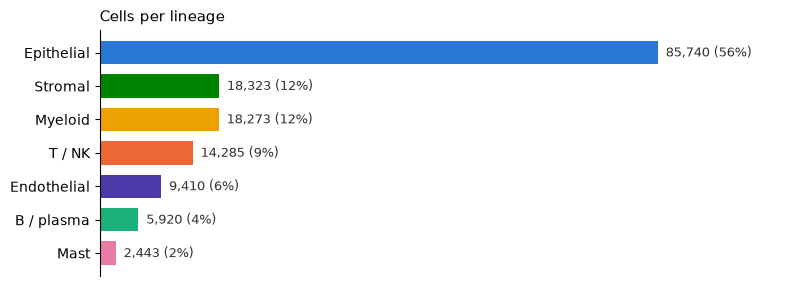

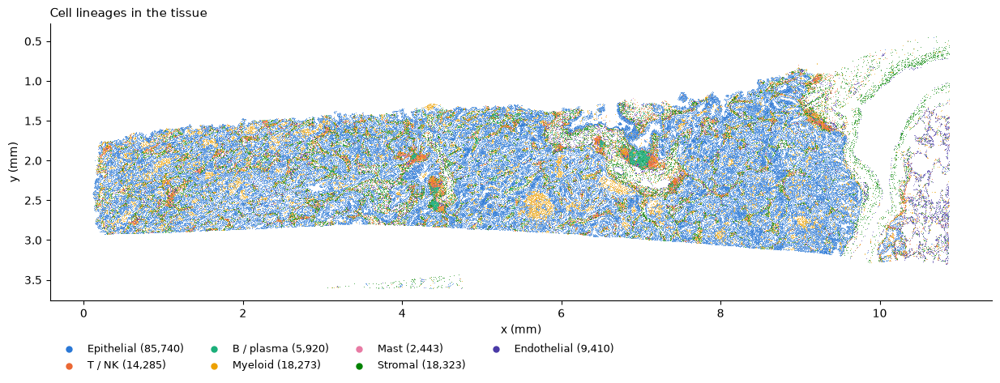

Saved: ~/data/xenium_lung/processed/Xenium_V1_humanLung_Cancer_FFPE_annotated.h5ad (127 MB) with obs['cell_type'], obs['lineage'], obs['annotation_confidence'] and per-set scores.


In [23]:
# ---- 6e. Merge fine labels back, summarise, map, save -----------------------------
# Lineage follows the final label (e.g. mast cells found inside the T cluster become "Mast")
annotate.merge_labels(adata, {"T_NK": tnk, "Myeloid": mye}, ANN["lineage_overrides"], myeloid_lineage=ANN["all_myeloid_subclusters_are"])
comp = annotate.composition(adata)
display(comp.set_index(["lineage", "cell_type"]))
mixed = (adata.obs["annotation_confidence"] == "mixed").mean()
print(f"{adata.obs['cell_type'].nunique()} cell types; {mixed:.1%} of cells are flagged 'mixed' "
      "(segmentation spillover). Keep them for maps, exclude them from per-cell-type statistics.\n")

# ---- Composition bar + tissue map by lineage ------------------------------------------
# Colourblind-checked categorical palette, assigned in fixed order (reused in later steps)
LINEAGE_COLORS = xu.LINEAGE_COLORS
counts = adata.obs["lineage"].value_counts()
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(counts.index[::-1], counts.values[::-1], color=[LINEAGE_COLORS[l] for l in counts.index[::-1]], height=0.7)
for y, v in enumerate(counts.values[::-1]):
    ax.text(v, y, f"  {v:,} ({v / adata.n_obs:.0%})", va="center", fontsize=9, color="#333333")
ax.set_xlim(0, counts.max() * 1.25)
ax.set_xticks([])
ax.set_title("Cells per lineage", loc="left", fontsize=11)
for s in ("top", "right", "bottom"):
    ax.spines[s].set_visible(False)
plt.show()

xy = adata.obsm["spatial"] / 1000
fig, ax = plt.subplots(figsize=(15, 5.6))
for lin, col in LINEAGE_COLORS.items():
    m = (adata.obs["lineage"] == lin).to_numpy()
    ax.scatter(xy[m, 0], xy[m, 1], s=0.25, c=col, linewidths=0, rasterized=True,
               label=f"{lin} ({m.sum():,})")
ax.set_aspect("equal"); ax.invert_yaxis()
ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)")
ax.legend(markerscale=12, frameon=False, ncol=4, loc="upper left", bbox_to_anchor=(0, -0.12), fontsize=9)
ax.set_title("Cell lineages in the tissue", loc="left", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

# ---- Save ---------------------------------------------------------------------------------
adata.uns["annotation"] = {
    "coarse_from": CLUSTER_KEY, "subclustered": {name: spec["clusters"] for name, spec in ANN["subclusters"].items()},  # HDF5 keys cannot contain "/"
    "subcluster_resolution": ANN["subcluster_resolution"], "label_tables": "config/annotation.yaml",
    "caveats": "Multi-Tissue panel lacks SFTPC/NAPSA/KRT5/TP63/SCGB1A1; tumour call is inferred "
               "(AGER-negative contiguous epithelium), not CNV-confirmed.",
}
adata.uns["lineage_colors"] = [LINEAGE_COLORS[l] for l in adata.obs["lineage"].cat.categories]
adata.write_h5ad(ANNOTATED_PATH, compression="gzip")
print(f"Saved: ~/data/xenium_lung/processed/{ANNOTATED_PATH.name} "
      f"({ANNOTATED_PATH.stat().st_size / 1e6:.0f} MB) with obs['cell_type'], obs['lineage'], "
      "obs['annotation_confidence'] and per-set scores.")

**Interpretation.** The final annotation contains 33 cell-type labels, with 9.9% of cells (15,265) flagged as mixed. Mixed-cell flagging is restricted to the two subclustered populations: `high` confidence elsewhere is a workflow default, not evidence that every cell was individually checked for off-lineage expression. Notebook 02 assesses spillover more broadly.

**Downstream scope.** Steps 7 onward use 139,129 cells, which excludes only the mixed cells. In the tissue map, B / plasma cells form compact aggregates near (7.0, 2.0) mm and (4.4, 2.4) mm, candidate tertiary lymphoid structures tested in Step 7.

## Step 7: Spatial analysis of the tumour immune microenvironment

Characterise how cell types are arranged relative to one another and to tumour cells using spatial neighbourhoods, local composition, and centroid distances.

Load the annotated dataset from Step 6 and retain cells with `annotation_confidence == "high"`. Exclude mixed-labelled cells to reduce the influence of ambiguous identities on spatial statistics. High-confidence labels outside the subclustered populations do not imply that spillover has been assessed individually.

The workflow uses the following analyses:

| Analysis | Question | Method |
|---|---|---|
| Spatial neighbour graph | Which cells are spatially adjacent? | Delaunay triangulation with edges longer than 30 µm removed |
| Neighbourhood enrichment | Which cell types are neighbours more or less often than expected? | Compare graph neighbour counts with 1,000 label permutations |
| Cellular niches | Which local lineage compositions recur? | Apply k-means to lineage fractions within 50 µm |
| Tumour proximity | How close are immune and stromal cells to tumour cells? | Measure nearest-tumour-cell distances and compare with a non-tumour baseline |
| TLS-like aggregates | Where do dense B-cell aggregates occur? | Apply DBSCAN to B-cell positions and summarise aggregate composition |

This step builds the spatial graph (7a), tests neighbourhood enrichment (7b), defines niches (7c), measures tumour proximity (7d), identifies TLS-like aggregates (7e), and saves the results (7f).

### 7a. Build the spatial neighbour graph

Define spatial adjacency for the graph-based analyses. Select the `spatial_env` kernel before running this cell.

Use `spatial.high_confidence()` to retain high-confidence cells. Use `spatial.delaunay_graph()` to construct a Delaunay graph from cell centroids, then remove edges longer than `MAX_EDGE_UM = 30`. Store the graph in `.obsp`.

Inspect the retained and excluded cell counts, median edge length, fraction of edges removed, neighbour counts, and number of isolated cells. Review the 300 µm window plot for edges spanning gaps or connecting non-adjacent cells.

Note: Centroid-based adjacency approximates physical proximity; it does not establish membrane contact. The graph inspection uses a fixed 300 µm window spanning 6.85–7.15 mm horizontally and 1.80–2.10 mm vertically; it is not selected programmatically from the aggregates detected in Step 7e.

139,129 high-confidence cells of 154,394 (15,265 'mixed' excluded from statistics)

INFO     Creating graph using `None` transform and `1` libraries.                                                  
Delaunay edges: 834,714; median length 10.9 um; 1.9% longer than 30 um removed
Neighbours per cell after pruning: median 6, mean 5.9; isolated cells: 89


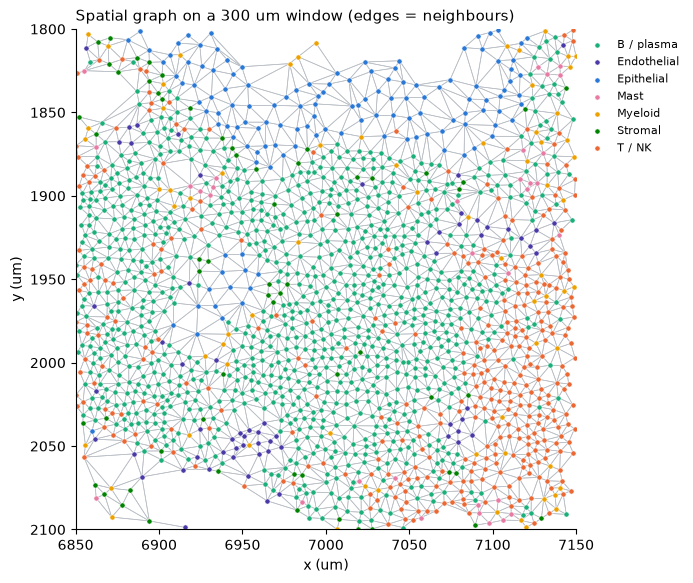

In [24]:
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError("Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)'.")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
from IPython.display import display
from matplotlib.collections import LineCollection

from ist_analysis import spatial
from ist_analysis import utils as xu

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

ANNOTATED_PATH = xu.STEP_FILES["annotated"]   # Step 6 output
SPATIAL_PATH = xu.STEP_FILES["spatial"]       # Step 7 output

MAX_EDGE_UM = 30   # drop graph edges longer than this: they bridge gaps, not real contacts

full = sc.read_h5ad(ANNOTATED_PATH)
# Spatial statistics use high-confidence cells only; 'mixed' spillover cells would blur contacts
adata = spatial.high_confidence(full)
LINEAGE_COLORS = dict(zip(full.obs["lineage"].cat.categories, full.uns["lineage_colors"]))
print(f"{adata.n_obs:,} high-confidence cells of {full.n_obs:,} "
      f"({(full.obs['annotation_confidence'] == 'mixed').sum():,} 'mixed' excluded from statistics)\n")

# ---- Spatial neighbour graph: Delaunay triangulation, pruned at MAX_EDGE_UM ----------
# Delaunay connects each cell to its natural touching neighbours without choosing k or a
# radius; pruning removes the long edges it draws across empty space and tissue gaps.
g = spatial.delaunay_graph(adata, MAX_EDGE_UM)
conn = adata.obsp["spatial_connectivities"]
print(f"Delaunay edges: {g['edges']:,}; median length {g['median_length_um']:.1f} um; "
      f"{g['frac_removed']:.1%} longer than {MAX_EDGE_UM} um removed")
print(f"Neighbours per cell after pruning: median {g['median_degree']:.0f}, mean {g['mean_degree']:.1f}; "
      f"isolated cells: {g['isolated']}")

# ---- Look at the graph on a 300 x 300 um window -------------------------------------------
xy = adata.obsm["spatial"]
x0, y0, w = 6850, 1800, 300   # window around the largest B-cell aggregate
win = (xy[:, 0] > x0) & (xy[:, 0] < x0 + w) & (xy[:, 1] > y0) & (xy[:, 1] < y0 + w)
idx = np.where(win)[0]
sub = conn[idx][:, idx].tocoo()
segs = np.stack([xy[idx[sub.row]], xy[idx[sub.col]]], axis=1)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.add_collection(LineCollection(segs, colors="#b9bec5", linewidths=0.5, zorder=1))
for lin, col in LINEAGE_COLORS.items():
    m = (adata.obs["lineage"].to_numpy()[idx] == lin)
    ax.scatter(xy[idx[m], 0], xy[idx[m], 1], s=14, c=col, edgecolors="white", linewidths=0.4,
               zorder=2, label=lin)
ax.set_xlim(x0, x0 + w); ax.set_ylim(y0 + w, y0)
ax.set_aspect("equal")
ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
ax.set_title("Spatial graph on a 300 um window (edges = neighbours)", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

**Interpretation.** The graph is built on 139,129 high-confidence cells. Delaunay edges have a median length of 10.9 µm, close to one cell diameter; pruning at 30 µm removes 1.9% of edges and leaves a median of six neighbours per cell, with 89 isolated cells. The graph therefore captures local contacts rather than long-range links.

### 7b. Test neighbourhood enrichment

Identify cell-type pairs that are spatial neighbours more or less often than expected under random label assignment.

Use `spatial.nhood_zscores()` to run Squidpy neighbourhood enrichment with `N_PERMS = 1000` and a fixed random seed. Express observed neighbour counts relative to the permutation distribution as z-scores.

Run the analysis at lineage level and for tumour–immune categories defined by `spatial.add_time_types()` in `obs["time_type"]`. Group remaining cell types as `other`.

Inspect the lineage and cell-type heatmaps, the strongest enriched and depleted pairs, and any categories absent from the high-confidence dataset. Positive z-scores indicate enrichment of adjacency; negative values indicate depletion.

Note: Large cell numbers can produce large z-scores for modest departures from the permutation baseline. Interpret their direction and relative ranking alongside tissue maps. Heatmap colour scales are clipped for display.

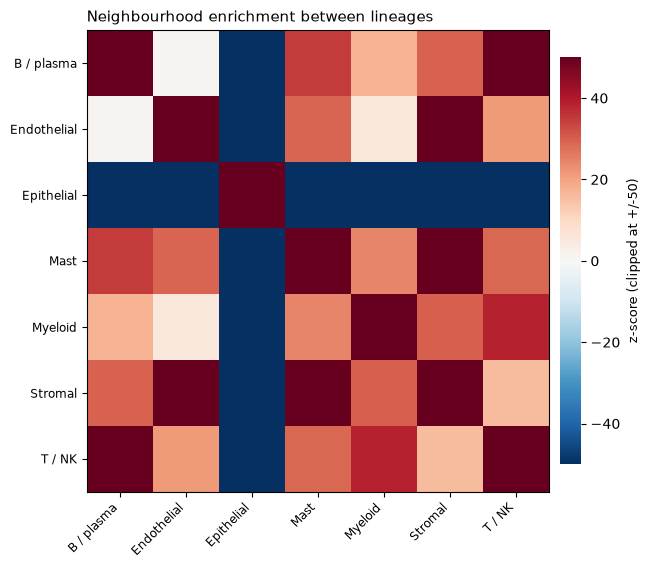

Red = these two cell groups touch more often than if labels were shuffled; blue = they avoid
each other. Diagonal red = cells cluster with their own kind (tissue compartments).
With ~140k cells even small effects give huge z-scores: read the pattern, not the magnitude.

Not in the high-confidence set (flagged 'mixed' in Step 6): CD4 T



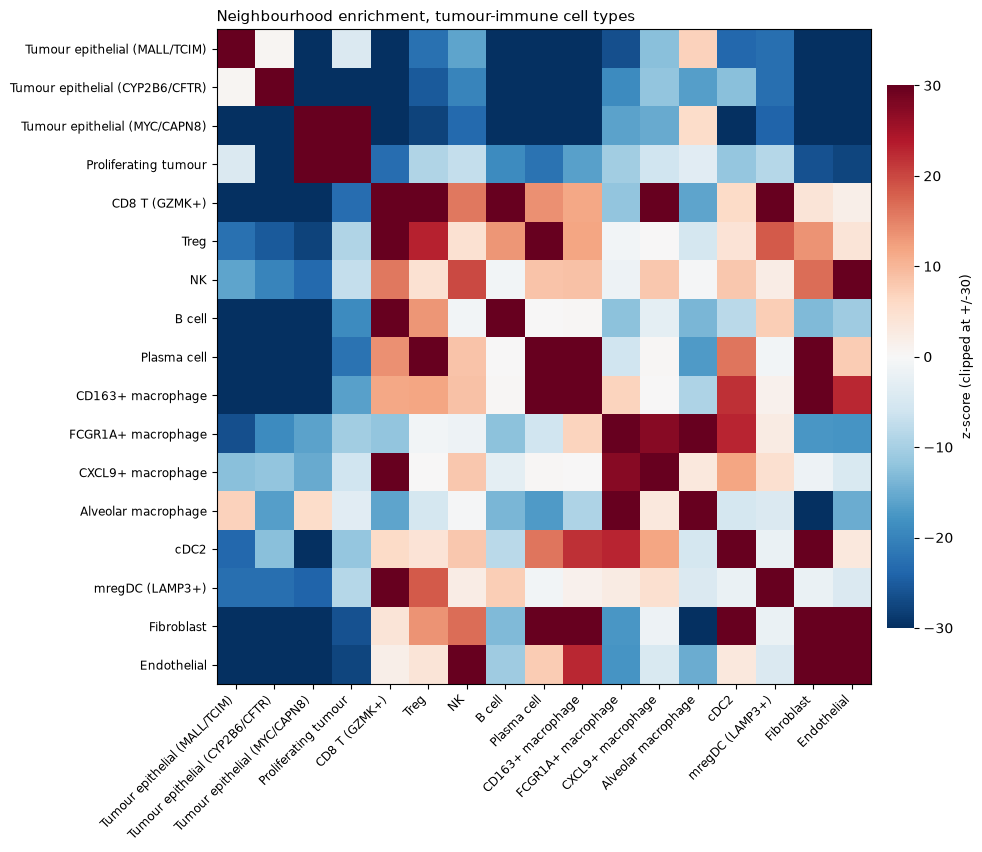

Strongest co-localised pairs (excluding self):


,cell type A,cell type B,z
0,CD8 T (GZMK+),mregDC (LAMP3+),113.1
1,B cell,CD8 T (GZMK+),89.4
2,Proliferating tumour,Tumour epithelial (MYC/CAPN8),88.9
3,Endothelial,Fibroblast,72.8
4,CD163+ macrophage,Plasma cell,66.4
5,CD163+ macrophage,Fibroblast,60.2
6,Alveolar macrophage,FCGR1A+ macrophage,57.5
7,Fibroblast,Plasma cell,56.7


Strongest avoiding pairs:


,cell type A,cell type B,z
0,Tumour epithelial (CYP2B6/CFTR),Tumour epithelial (MYC/CAPN8),-135.8
1,Fibroblast,Tumour epithelial (CYP2B6/CFTR),-108.5
2,Fibroblast,Tumour epithelial (MYC/CAPN8),-107.8
3,Endothelial,Tumour epithelial (MYC/CAPN8),-93.8
4,Endothelial,Tumour epithelial (CYP2B6/CFTR),-91.7


In [25]:
N_PERMS = 1000  # random label shuffles that define "expected by chance"


def enrichment_heatmap(key, title, order=None, clip=50, size=(7.5, 6)):
    z = spatial.nhood_zscores(adata, key, N_PERMS, order=order)   # z-scores vs label permutations
    fig, ax = plt.subplots(figsize=size)
    im = ax.imshow(z.clip(-clip, clip).to_numpy(), cmap="RdBu_r", vmin=-clip, vmax=clip)
    ax.set_xticks(range(len(z)), z.columns, rotation=45, ha="right", fontsize=8.5)
    ax.set_yticks(range(len(z)), z.index, fontsize=8.5)
    ax.set_title(title, loc="left", fontsize=11)
    cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cb.set_label(f"z-score (clipped at +/-{clip})", fontsize=9)
    cb.outline.set_visible(False)
    plt.show()
    return z


# ---- Lineage level ------------------------------------------------------------------
z_lin = enrichment_heatmap("lineage", "Neighbourhood enrichment between lineages")
print("Red = these two cell groups touch more often than if labels were shuffled; blue = they avoid\n"
      "each other. Diagonal red = cells cluster with their own kind (tissue compartments).\n"
      "With ~140k cells even small effects give huge z-scores: read the pattern, not the magnitude.\n")

# ---- Tumour-immune cell types ---------------------------------------------------------
TIME_TYPES = spatial.add_time_types(adata)   # obs['time_type']: tumour-immune types present, all others 'other'
dropped = [t for t in spatial.TIME_TYPES if t not in TIME_TYPES]
if dropped:
    print(f"Not in the high-confidence set (flagged 'mixed' in Step 6): {', '.join(dropped)}\n")
z_ct = enrichment_heatmap("time_type", "Neighbourhood enrichment, tumour-immune cell types",
                          order=TIME_TYPES, clip=30, size=(10, 8.5))

print("Strongest co-localised pairs (excluding self):")
display(spatial.top_pairs(z_ct, 8).round(1))
print("Strongest avoiding pairs:")
display(spatial.top_pairs(z_ct, 5, largest=False).round(1))

**Interpretation.** Relative to the label-permutation baseline, the strongest enriched adjacency among tumour-immune cell types is between GZMK+ CD8 T cells and LAMP3+ mregDCs (z 113), followed by B cells with CD8 T cells (z 89), consistent with immune hubs where antigen-presenting cells and T cells meet. The strongest depletion is between the CYP2B6/CFTR and MYC/CAPN8 tumour groups (z −136): these programmes occupy distinct regions rather than intermixing. Fibroblasts and endothelial cells co-localise with each other (z 73) and are separated from both tumour groups (z −92 to −109). These findings describe neighbourhood structure rather than demonstrating direct cellular interactions. CD4 T cells are absent because they were flagged mixed in Step 6.

### 7c. Define cellular niches

Identify recurring local lineage compositions across the tissue.

Use `spatial.composition_niches()` to calculate lineage fractions within `NICHE_RADIUS_UM = 50` of each cell. Cluster these composition vectors into `N_NICHES = 10` groups using k-means with a fixed random seed.

Order niches by decreasing epithelial fraction, with `N1` having the highest fraction, and name them according to their dominant lineages. Store assignments in `obs["niche"]`.

Inspect the median neighbourhood size, niche-composition heatmap, and tissue maps. Assess whether niches form coherent regions corresponding to tumour nests, interfaces, immune aggregates, stroma, or vasculature.

Note: The number of niches is specified rather than inferred. Names describe local composition, not independently established biological states. Notebook 04 compares these niches with data-driven spatial domains.

Median cells per 50 um neighbourhood: 71


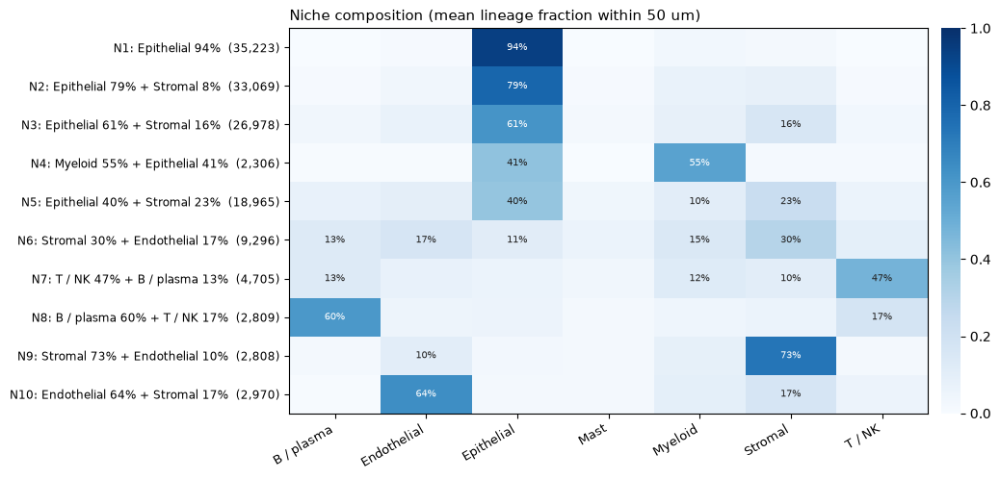

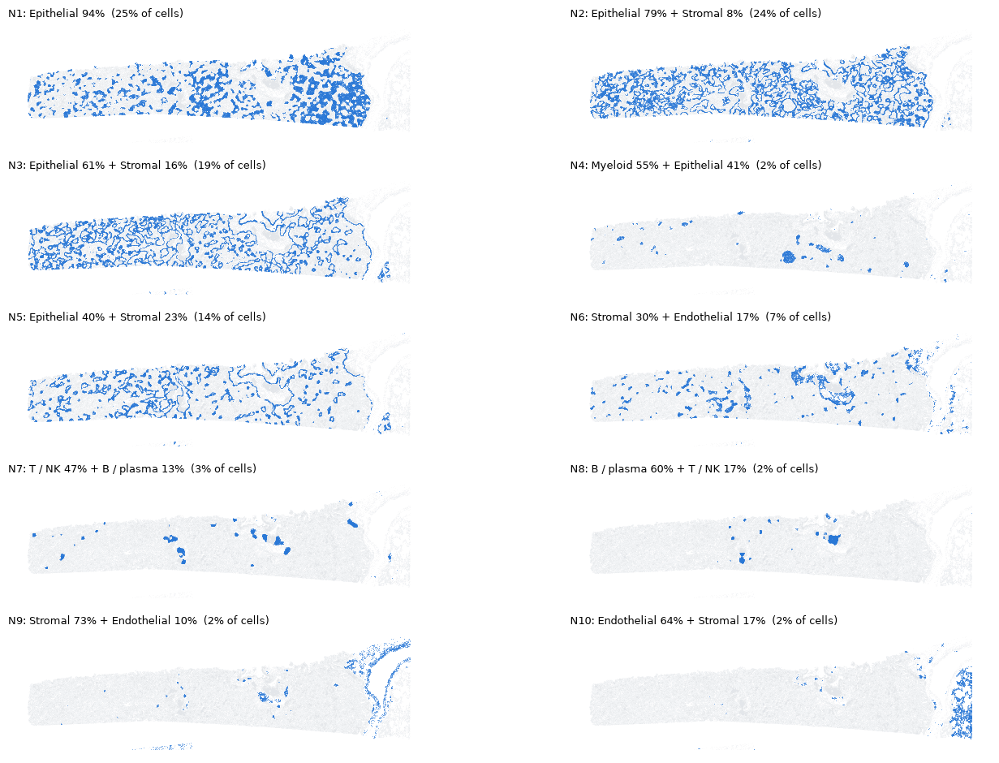

In [26]:
NICHE_RADIUS_UM = 50   # neighbourhood window for each cell
N_NICHES = 10

# ---- Each cell's lineage mix within 50 um, clustered into niches (Schurch et al. 2020) --------
# spatial.composition_niches: k-means on the composition vectors; niches named by their dominant
# lineages and numbered by decreasing epithelial share (tumour core first); obs['niche']
centres, median_nb = spatial.composition_niches(adata, NICHE_RADIUS_UM, N_NICHES)
lineages = list(adata.obs["lineage"].cat.categories)
print(f"Median cells per {NICHE_RADIUS_UM} um neighbourhood: {median_nb:.0f}")

fig, ax = plt.subplots(figsize=(9, 5.2))
im = ax.imshow(centres[lineages].to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(lineages)), lineages, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(centres)), [f"{n}  ({c:,})" for n, c in zip(centres.index, centres.cells)], fontsize=8.5)
for (i, j), v in np.ndenumerate(centres[lineages].to_numpy()):
    if v >= 0.1:
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=7.5, color="white" if v > 0.55 else "#222222")
ax.set_title(f"Niche composition (mean lineage fraction within {NICHE_RADIUS_UM} um)", loc="left", fontsize=11)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.outline.set_visible(False)
plt.show()

# ---- Where each niche sits: one panel per niche --------------------------------------------
xmm, ymm = xy[:, 0] / 1000, xy[:, 1] / 1000
fig, axes = plt.subplots(5, 2, figsize=(15, 9.5), sharex=True, sharey=True)
niche_arr = adata.obs["niche"].to_numpy()
for ax, n in zip(axes.flat, adata.obs["niche"].cat.categories):
    m = niche_arr == n
    ax.scatter(xmm[~m], ymm[~m], s=0.04, c="#e3e6ea", linewidths=0, rasterized=True)
    ax.scatter(xmm[m], ymm[m], s=0.2, c="#2a78d6", linewidths=0, rasterized=True)
    ax.set_title(f"{n}  ({m.mean():.0%} of cells)", loc="left", fontsize=9)
axes.flat[0].invert_yaxis()
for ax in axes.flat:
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
plt.tight_layout()
plt.show()

**Interpretation.** A 50 µm neighbourhood contains a median of 71 cells. Most of the section is tumour: N1 (25% of cells) is near-pure epithelium, and N2, N3 and N5 (together 57%) form a gradient of increasing stromal content, consistent with tumour-stroma interfaces. N4 (1.7%) is a myeloid-dominated niche adjoining epithelium. N7 (T / NK-rich, 3.4%) and N8 (B / plasma-rich, 2.0%) are the immune hubs, including the TLS candidates examined in 7e. N6 is mixed stroma, N9 fibrous stroma and N10 vascular. Niche boundaries are a summary of composition; the tissue maps show whether each niche forms coherent regions.

### 7d. Measure proximity to tumour cells

Compare immune and stromal cell distributions relative to tumour cells.

Use `spatial.distance_to_tumour()` to calculate the distance from each cell centroid to the nearest tumour-cell centroid, using `xu.TUMOUR_TYPES`. Store distances in `obs["dist_to_tumour_um"]`.

Use `spatial.infiltration_table()` to summarise median distance, the percentage within `CONTACT_UM = 15`, and the percentage beyond 100 µm for each immune cell type and fibroblasts.

Compare each population's within-threshold percentage with the baseline for all non-tumour cells. Classify populations as infiltrating above `1.2` times the baseline, excluded below `0.8` times the baseline, and similar otherwise.

Inspect the baseline summary, classification table, and cumulative distance curves.

Note: These operational labels describe relative proximity, not demonstrated migration or tumour penetration. Distances also reflect tissue architecture. The 15 µm threshold and classification bands are fixed conventions, not statistical significance tests.

Not analysed (flagged 'mixed' in Step 6): CD4 T
Baseline (all non-tumour cells): median 20.0 um, 34% within 15 um of a tumour cell



,cells,median distance (um),% within 15 um,% beyond 100 um,vs. baseline
cell_type,,,,,
Alveolar macrophage,"1,925",12.1,68,2,infiltrating
cDC2,"2,653",13.7,55,2,infiltrating
FCGR1A+ macrophage,"1,918",14.6,52,1,infiltrating
Fibroblast,"15,944",15.0,50,6,infiltrating
CXCL9+ macrophage,261,17.3,39,2,similar
cDC1 (IRF8+),618,19.1,27,3,excluded
NK,633,19.5,38,10,similar
CD163+ macrophage,"2,467",20.1,29,6,similar
Treg,681,22.7,25,5,excluded


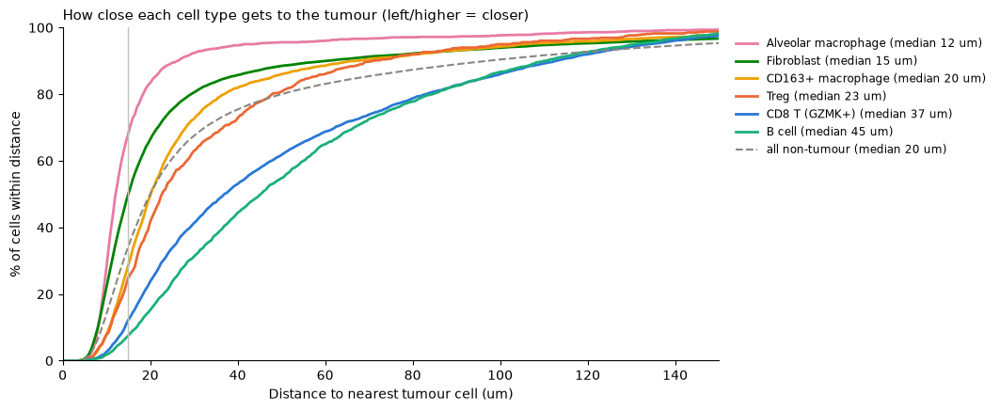

CD8 T cells sit further from tumour than the baseline (immune-excluded pattern), while
macrophages, cDC2 and fibroblasts are in direct contact: the tumour border is myeloid/stromal.


In [27]:
# ---- Distance from every cell to the nearest tumour cell (obs['dist_to_tumour_um']) ----------
TUMOUR_TYPES = xu.TUMOUR_TYPES
CONTACT_UM = 15   # within ~2 cell diameters = in contact with tumour
is_tumour = spatial.distance_to_tumour(adata)
d_tumour = adata.obs["dist_to_tumour_um"].to_numpy()
nontum = ~is_tumour
# Baseline: all non-tumour cells. A type is 'excluded' if it sits further from tumour than that.
IMMUNE_TYPES = spatial.IMMUNE_TYPES
infil, base_median, base_contact = spatial.infiltration_table(adata, is_tumour, CONTACT_UM)
missing = [t for t in IMMUNE_TYPES if t not in set(adata.obs["cell_type"])]
if missing:
    print(f"Not analysed (flagged 'mixed' in Step 6): {', '.join(missing)}")
print(f"Baseline (all non-tumour cells): median {base_median:.1f} um, "
      f"{base_contact:.0%} within {CONTACT_UM} um of a tumour cell\n")
display(infil.style.format({"cells": "{:,}", "median distance (um)": "{:.1f}",
                            f"% within {CONTACT_UM} um": "{:.0f}", "% beyond 100 um": "{:.0f}"}))

# ---- Cumulative distance curves for key players ----------------------------------------
CURVES = {  # fixed palette order
    "CD8 T (GZMK+)": "#2a78d6", "Treg": "#eb6834", "B cell": "#1baf7a",
    "CD163+ macrophage": "#eda100", "Alveolar macrophage": "#e87ba4", "Fibroblast": "#008300",
}
fig, ax = plt.subplots(figsize=(9, 4.6))
grid = np.linspace(0, 150, 301)
base = np.searchsorted(np.sort(d_tumour[nontum]), grid) / nontum.sum()
# legend ordered closest -> furthest (curves converge at the right, so no end labels)
for ct in sorted(CURVES, key=lambda c: infil.loc[c, "median distance (um)"]):
    d = np.sort(adata.obs.loc[adata.obs["cell_type"] == ct, "dist_to_tumour_um"].to_numpy())
    y = np.searchsorted(d, grid) / len(d) * 100
    ax.plot(grid, y, color=CURVES[ct], lw=2, label=f"{ct} (median {np.median(d):.0f} um)")
ax.plot(grid, base * 100, color="#898781", lw=1.5, ls="--", label=f"all non-tumour (median {base_median:.0f} um)")
ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.axvline(CONTACT_UM, color="#c3c2b7", lw=1)
ax.set_xlim(0, 150); ax.set_ylim(0, 100)
ax.set_xlabel("Distance to nearest tumour cell (um)")
ax.set_ylabel("% of cells within distance")
ax.set_title("How close each cell type gets to the tumour (left/higher = closer)", loc="left", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()
print("CD8 T cells sit further from tumour than the baseline (immune-excluded pattern), while\n"
      "macrophages, cDC2 and fibroblasts are in direct contact: the tumour border is myeloid/stromal.")

**Interpretation.** Non-tumour cells lie a median of 20 µm from the nearest tumour cell, with 34% within 15 µm.

- **Tumour border:** alveolar macrophages (68% within 15 µm), cDC2 (55%), FCGR1A+ macrophages (52%) and fibroblasts (50%) exceed the baseline, so the tumour border is dominated by myeloid and stromal cells.
- **Lymphocytes:** GZMK+ CD8 T cells (median 37 µm, 12% within 15 µm), B cells (45 µm, 8%) and mregDCs (38 µm, 11%) remain further from tumour than the baseline, an immune-excluded pattern consistent with their co-localisation in lymphoid hubs (7b).
- **Furthest:** LYVE1+ macrophages (median 120 µm, 57% beyond 100 µm), consistent with a perivascular or stromal location.

Interpret these values relative to the non-tumour baseline and the tissue architecture: the 15 µm threshold does not establish physical contact, and the classes describe position, not migration. Step 9 tests the exclusion pattern at tile level and by T-cell state.

### 7e. Identify TLS-like aggregates

Detect dense B-cell aggregates and assess their composition as candidate tertiary lymphoid structures.

Use `spatial.find_tls()` to apply DBSCAN to B-cell positions with `TLS_EPS_UM = 25` and `TLS_MIN_B = 20`. These parameters define the neighbourhood radius and minimum B-cell density required to identify a core.

Represent each aggregate with a circular region based on its 90th-percentile B-cell radius plus a 20 µm rim. Summarise aggregate location, size, B-cell, T / NK-cell and tumour-cell percentages, and counts of mregDCs and `CCL19`-expressing cells.

Number aggregates by size, with `TLS1` the largest, and store assignments in `obs["tls_id"]`.

Inspect the fraction of B cells assigned to aggregates, aggregate composition table, tissue map, and enlarged view of the largest aggregate.

Note: Use the term TLS-like because the panel lacks maturity-associated markers including `CXCL13`, `CR2`, and `CCL21`. Circular regions approximate aggregate boundaries, and detection depends on the DBSCAN settings. Parameter stability is not assessed in this step.

1,635 of 2,313 B cells (71%) fall in 6 dense aggregates (DBSCAN eps=25 um, min_samples=20)



,x (mm),y (mm),radius (um),cells,% B,% T / NK,% tumour,mregDC,CCL19+ cells
TLS,,,,,,,,,
TLS1,6.97,1.97,150,1446,65,17,5,8,209
TLS2,4.40,2.55,88,495,59,18,6,2,60
TLS3,4.40,2.36,86,461,37,43,7,8,175
TLS4,4.14,1.94,68,286,38,42,5,10,55
TLS5,6.50,1.79,62,215,43,29,0,5,56
TLS6,7.38,2.31,48,137,22,50,0,6,24


All aggregates are B-cell cores with a T-cell rim, mregDCs and CCL19 (a lymphoid-homing
chemokine), and almost no tumour cells: TLS-like. Mature-TLS markers (CXCL13, CR2 for
follicular dendritic cells, PNAd venules) are not on this panel, so maturity cannot be staged.


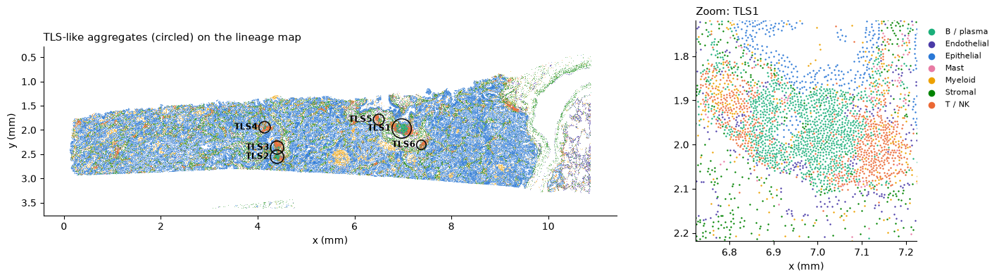

In [28]:
from matplotlib.patches import Circle

# ---- Tertiary lymphoid structure (TLS)-like aggregates: dense clusters of B cells ----
# spatial.find_tls: DBSCAN on B-cell positions; each aggregate = B core (90th-percentile radius) + 20 um rim;
# obs['tls_id'] (TLS1 = largest)
TLS_EPS_UM = 25        # B cells within 25 um chain into one aggregate
TLS_MIN_B = 20         # an aggregate needs >= 20 B cells (core points)
tls_table, n_in, n_b = spatial.find_tls(adata, TLS_EPS_UM, TLS_MIN_B)
print(f"{n_in:,} of {n_b:,} B cells ({n_in / n_b:.0%}) fall in "
      f"{len(tls_table)} dense aggregates (DBSCAN eps={TLS_EPS_UM} um, min_samples={TLS_MIN_B})\n")
display(tls_table.style.format({"x (mm)": "{:.2f}", "y (mm)": "{:.2f}", "radius (um)": "{:.0f}",
                                "% B": "{:.0f}", "% T / NK": "{:.0f}", "% tumour": "{:.0f}"}))
print("All aggregates are B-cell cores with a T-cell rim, mregDCs and CCL19 (a lymphoid-homing\n"
      "chemokine), and almost no tumour cells: TLS-like. Mature-TLS markers (CXCL13, CR2 for\n"
      "follicular dendritic cells, PNAd venules) are not on this panel, so maturity cannot be staged.")

# ---- Map: lineages with the aggregates circled, and a zoom on the largest -------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [2.6, 1]})
for lin, col in LINEAGE_COLORS.items():
    m = (adata.obs["lineage"] == lin).to_numpy()
    for ax in axes:
        ax.scatter(xy[m, 0] / 1000, xy[m, 1] / 1000, s=0.15 if ax is axes[0] else 3, c=col,
                   linewidths=0, rasterized=True, label=lin)
for tls, r in tls_table.iterrows():
    axes[0].add_patch(Circle((r["x (mm)"], r["y (mm)"]), r["radius (um)"] / 1000 + 0.05, fill=False,
                             edgecolor="#0b0b0b", lw=1.2))
    axes[0].annotate(tls, (r["x (mm)"] - r["radius (um)"] / 1000 - 0.08, r["y (mm)"]), ha="right",
                     va="center", fontsize=8.5, weight="bold")   # label left of its circle
big = tls_table.iloc[0]
pad = big["radius (um)"] / 1000 + 0.1
axes[1].set_xlim(big["x (mm)"] - pad, big["x (mm)"] + pad)
axes[1].set_ylim(big["y (mm)"] + pad, big["y (mm)"] - pad)
axes[0].invert_yaxis()
axes[0].set_title("TLS-like aggregates (circled) on the lineage map", loc="left", fontsize=11)
axes[1].set_title(f"Zoom: {tls_table.index[0]}", loc="left", fontsize=11)
for ax in axes:
    ax.set_aspect("equal"); ax.set_xlabel("x (mm)")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("y (mm)")
axes[1].legend(markerscale=4, frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

**Interpretation.** 1,635 of 2,313 B cells (71%) fall in six aggregates. TLS1, the largest (1,446 cells, radius about 150 µm), lies at (6.97, 1.97) mm; TLS2–4 form a second group around x 4.1–4.4 mm. All six combine B cells (22–65%) with T / NK cells (17–50%), contain mregDCs (2–10) and `CCL19`-expressing cells (24–209), and include few tumour cells (0–7%). This organisation is consistent with tertiary lymphoid structures, but these remain TLS-like candidates under the specified DBSCAN settings: stability across alternative settings has not been assessed, and maturity cannot be staged on this panel. TLS1 and TLS2 are B-cell dominated, whereas TLS3, TLS4 and TLS6 contain more T / NK than B cells. The fixed 7a inspection window contains TLS1.

### 7f. Save the spatial dataset

Save the spatially annotated dataset for Steps 8–10.

Record graph, permutation, niche, proximity, and DBSCAN settings in `.uns["step7_params"]`. Remove large permutation results from `.uns` before saving.

Inspect the saved file size and confirm that `.obs` contains `niche`, `dist_to_tumour_um`, `tls_id`, and `time_type`, and that `.obsp` contains the spatial graph.

Note: Unlike the Step 6 output, this file contains only cells labelled as high confidence. It is saved to `~/data/xenium_lung/processed/` and overwrites any existing file with the same name.

In [29]:
# ---- Save spatial results (high-confidence cells) -------------------------------------
adata.uns["step7_params"] = {
    "graph": f"Delaunay, edges > {MAX_EDGE_UM} um removed", "nhood_perms": N_PERMS,
    "niche_radius_um": NICHE_RADIUS_UM, "n_niches": N_NICHES, "contact_um": CONTACT_UM,
    "tls_dbscan": {"eps_um": TLS_EPS_UM, "min_samples": TLS_MIN_B},
    "cells": "annotation_confidence == 'high' only",
}
for key in ["lineage_nhood_enrichment", "time_type_nhood_enrichment"]:
    adata.uns.pop(key, None)   # large permutation results; recompute when needed
adata.write_h5ad(SPATIAL_PATH, compression="gzip")
print(f"Saved: ~/data/xenium_lung/processed/{SPATIAL_PATH.name} ({SPATIAL_PATH.stat().st_size / 1e6:.0f} MB)")
print("New in .obs: niche, dist_to_tumour_um, tls_id, time_type; spatial graph in .obsp.")

Saved: ~/data/xenium_lung/processed/Xenium_V1_humanLung_Cancer_FFPE_spatial.h5ad (122 MB)
New in .obs: niche, dist_to_tumour_um, tls_id, time_type; spatial graph in .obsp.


## Step 8: H&E alignment

Align the separately scanned H&E image with the Xenium coordinate system to compare expression-based cell annotations with tissue morphology.

Use the supplied `he_imagealignment.csv` affine matrix to map H&E pixels to Xenium morphology pixels. Apply the inverse mapping when sampling H&E at Xenium cell positions, accounting for the conversion between Xenium pixels and micrometres.

Load the spatial dataset from Step 7; earlier steps do not need to be repeated. This step requires the H&E image (`*_he_image.ome.tif`, approximately 1.2 GB) and alignment file downloaded in Step 1.

The workflow uses the following stages:

| Stage | Purpose | Setting |
|---|---|---|
| Alignment loading | Establish the mapping between image coordinates | Supplied 3 × 3 affine matrix |
| Alignment assessment | Check registration quantitatively and visually | Hematoxylin–DAPI correlation on a 4 µm grid, shifts up to ±40 µm, and checkerboard overlay |
| Histology windows | Compare cell annotations with local morphology | Three data-selected 400 µm windows at 0.5 µm per pixel |
| Stain features | Sample histology-derived intensity at cell positions | Hematoxylin and eosin optical density at each centroid |

This step loads the alignment and images (8a), assesses registration (8b), overlays cell annotations on histology (8c), and extracts stain features and saves the dataset (8d).

### 8a. Load the alignment and images

Load the affine matrix, check its mapping direction, and inspect the image frames. Select the `spatial_env` kernel before running this cell.

Use `he.load_alignment()` to read the matrix and `xenium_aligned_image()` to represent the aligned H&E image in SpatialData. Map the four H&E image corners into Xenium morphology-pixel coordinates and compare their positions with the Xenium image extent.

Display low-resolution H&E and DAPI thumbnails from their image pyramids. Inspect the transform, H&E dimensions, pyramid levels, mapped corners, and differences in image orientation.

Note: `xenium_aligned_image()` represents the full-resolution image as a single block of approximately 2 GB. Subsequent cells read individual pyramid levels with `tifffile` and apply the coordinate mapping explicitly.

spatialdata-io attaches the matrix as an Affine transform to the 'global' (Xenium pixel) frame:
Affine (x, y -> x, y)
    [ 4.78350737e-03  1.28872448e+00 -7.54820225e+01]
    [-1.28872448e+00  4.78350737e-03  1.63091028e+04]
    [0. 0. 1.] 

H&E: 11,580 x 45,087 px, 6 pyramid levels. Its corners land at Xenium pixels:
                    x        y
top-left        -75.0  16309.0
top-right       -20.0   1386.0
bottom-left   58029.0  16525.0
bottom-right  58085.0   1601.0
The Xenium frame is ~51,200 x 17,100 px, so M maps H&E -> Xenium (its inverse maps Xenium -> H&E).
Note: xenium_aligned_image loads only full resolution (one 2 GB block). Below, pixels are read
from the file's own pyramid with tifffile, and the matrix is applied explicitly.



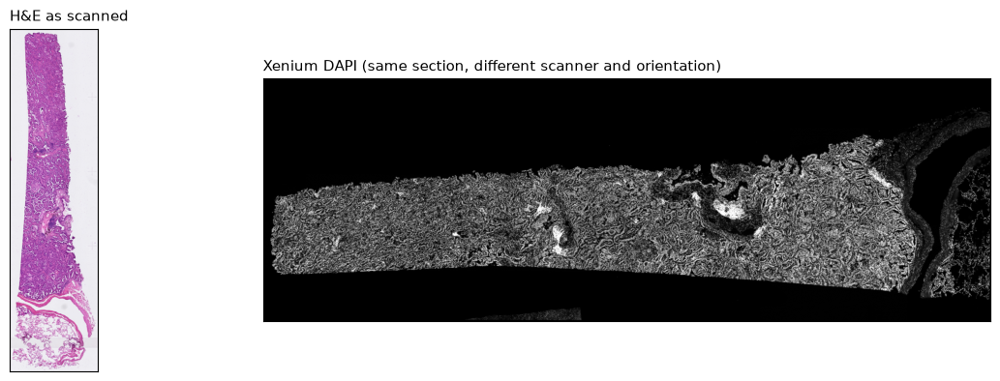

In [30]:
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError("Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)'.")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import tifffile
import zarr
from IPython.display import display
from skimage.color import rgb2hed
from skimage.transform import warp
from spatialdata_io import xenium_aligned_image

from ist_analysis import he
from ist_analysis import utils as xu

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

HE_PATH = xu.HE_PATH
ALIGN_PATH = xu.HE_ALIGNMENT_PATH
DAPI_PATH = xu.OUTS_DIR / "morphology_focus" / "morphology_focus_0000.ome.tif"
SPATIAL_PATH = xu.STEP_FILES["spatial"]          # Step 7 output
HE_FEATURES_PATH = xu.STEP_FILES["he_features"]  # Step 8 output
PIXEL_SIZE = xu.PIXEL_SIZE_UM  # um per Xenium morphology pixel

# ---- The alignment matrix: H&E pixel -> Xenium morphology pixel ----------------------
M = he.load_alignment(ALIGN_PATH)
he_img = xenium_aligned_image(HE_PATH, ALIGN_PATH)   # the SpatialData way: image + its transform
print("spatialdata-io attaches the matrix as an Affine transform to the 'global' (Xenium pixel) frame:")
print(sd.transformations.get_transformation(he_img), "\n")

he_levels = he.he_level_shapes(HE_PATH)
H0, W0 = he_levels[0][:2]
corners = np.array([[0, 0, 1], [W0, 0, 1], [0, H0, 1], [W0, H0, 1]], dtype=float).T
print(f"H&E: {W0:,} x {H0:,} px, {len(he_levels)} pyramid levels. Its corners land at Xenium pixels:")
print(pd.DataFrame((M @ corners)[:2].T.round(0), columns=["x", "y"],
                   index=["top-left", "top-right", "bottom-left", "bottom-right"]))
print("The Xenium frame is ~51,200 x 17,100 px, so M maps H&E -> Xenium (its inverse maps Xenium -> H&E).")
print("Note: xenium_aligned_image loads only full resolution (one 2 GB block). Below, pixels are read")
print("from the file's own pyramid with tifffile, and the matrix is applied explicitly.\n")

# ---- Raw thumbnails: why alignment is needed ------------------------------------------------
he_thumb = he.he_level(HE_PATH, 4)
with tifffile.TiffFile(DAPI_PATH) as tif:
    dapi_thumb = tif.series[0].levels[4].asarray()[0]    # channel 0 = DAPI
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 3.2]})
axes[0].imshow(he_thumb)
axes[0].set_title("H&E as scanned", loc="left", fontsize=11)
lo, hi = np.percentile(dapi_thumb[dapi_thumb > 0], [1, 99.5])
axes[1].imshow(np.clip((dapi_thumb - lo) / (hi - lo), 0, 1), cmap="gray")
axes[1].set_title("Xenium DAPI (same section, different scanner and orientation)", loc="left", fontsize=11)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

**Interpretation.** The matrix combines a rotation of about 90° with a scale of 1.289 Xenium pixels per H&E pixel, so one H&E pixel corresponds to about 0.274 µm, compared with 0.2125 µm for Xenium. The mapped H&E corners span x −75 to 58,085 and y 1,386 to 16,525 Xenium pixels. The Xenium frame is 51,187 × 17,098 pixels, so the H&E covers the Xenium region and extends about 1.5 mm beyond its right edge; the thumbnails show this additional tissue at the lower end of the H&E scan.

### 8b. Assess H&E–Xenium registration

Check registration before interpreting histology at Xenium cell positions.

Use `he.alignment_qc()` to warp H&E pyramid level 3 and DAPI onto a common grid at `RES_UM = 4`. Separate the hematoxylin channel using `rgb2hed`, then correlate it with log-transformed DAPI within the tissue over shifts of up to ±10 grid steps, equivalent to ±40 µm.

Inspect the zero-shift correlation, maximum correlation, and corresponding displacement. Review the aligned H&E image, correlation-by-shift map, and checkerboard of alternating 500 µm H&E and DAPI tiles for continuity across boundaries.

Note: A correlation maximum near zero shift supports registration at the scale assessed. The 4 µm sampling grid does not establish single-cell alignment accuracy, and differences in staining and image contrast limit direct intensity agreement.

Both images resampled to one 2720 x 909 grid at 4 um/px
Hematoxylin vs DAPI correlation: r = 0.60 at zero shift; best r = 0.61 at shift (+0, -4) um
-> Best match at (or within one grid step of) zero offset: the 10x alignment is accurate.



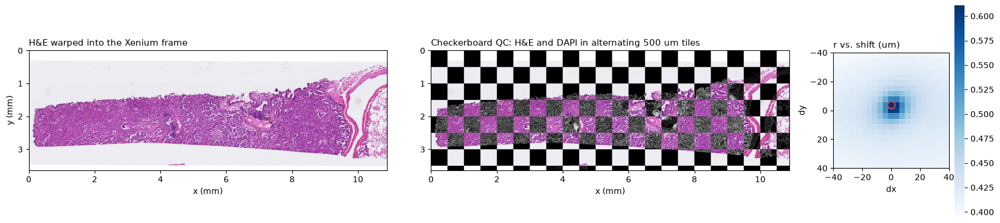

In [31]:
RES_UM = 4.0   # output grid for the whole-slide view: 4 um per pixel

# ---- Alignment QC: does H&E nuclear stain line up with DAPI? (he.alignment_qc) ---------------
# H&E (pyramid level 3) and DAPI are warped onto one Xenium-aligned RES_UM grid; colour deconvolution
# splits H&E into hematoxylin (nuclei) and eosin (cytoplasm / ECM), and hematoxylin is correlated with
# DAPI (also nuclear) at shifts of +/- 40 um. A correct alignment peaks at zero shift.
qc_he, corr, he_grid, dapi_grid, shifts = he.alignment_qc(HE_PATH, DAPI_PATH, M, RES_UM)
grid_shape = he_grid.shape[:2]
print(f"Both images resampled to one {grid_shape[1]} x {grid_shape[0]} grid at {RES_UM:.0f} um/px")
hema = rgb2hed(he_grid)[..., 0]
tissue = (dapi_grid > np.percentile(dapi_grid, 50)) | (hema > np.percentile(hema, 50))
iy, ix = np.unravel_index(corr.argmax(), corr.shape)
print(f"Hematoxylin vs DAPI correlation: r = {corr[10, 10]:.2f} at zero shift; best r = {corr.max():.2f} "
      f"at shift ({shifts[ix] * RES_UM:+.0f}, {shifts[iy] * RES_UM:+.0f}) um")
print("-> Best match at (or within one grid step of) zero offset: the 10x alignment is accurate.\n")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), gridspec_kw={"width_ratios": [3, 3, 1.1]})
ext = [0, grid_shape[1] * RES_UM / 1000, grid_shape[0] * RES_UM / 1000, 0]
axes[0].imshow(he_grid, extent=ext)
axes[0].set_title("H&E warped into the Xenium frame", loc="left", fontsize=11)
# Checkerboard: alternating H&E / DAPI tiles. Edges that continue across tiles = good alignment.
tile = 125   # grid px = 500 um
yy, xx = np.indices(grid_shape)
board = ((yy // tile + xx // tile) % 2).astype(bool)
lo, hi = np.percentile(dapi_grid[tissue], [1, 99.5])
dapi_rgb = np.repeat(np.clip((dapi_grid - lo) / (hi - lo), 0, 1)[..., None] * 255, 3, axis=2).astype(np.uint8)
axes[1].imshow(np.where(board[..., None], he_grid, dapi_rgb), extent=ext)
axes[1].set_title("Checkerboard QC: H&E and DAPI in alternating 500 um tiles", loc="left", fontsize=11)
for ax in axes[:2]:
    ax.set_xlabel("x (mm)")
axes[0].set_ylabel("y (mm)")
im = axes[2].imshow(corr, cmap="Blues", extent=[shifts[0] * RES_UM, shifts[-1] * RES_UM,
                                                shifts[-1] * RES_UM, shifts[0] * RES_UM])
axes[2].plot(shifts[ix] * RES_UM, shifts[iy] * RES_UM, "o", mfc="none", mec="#d1495b", ms=9, mew=1.5)
axes[2].set_title("r vs. shift (um)", loc="left", fontsize=11)
axes[2].set_xlabel("dx"); axes[2].set_ylabel("dy")
fig.colorbar(im, ax=axes[2], fraction=0.08, pad=0.04).outline.set_visible(False)
plt.tight_layout()
plt.show()

**Interpretation.** The hematoxylin–DAPI correlation is 0.60 at zero shift, and the maximum is 0.61 at a displacement of (0, −4) µm, one grid step. The correlation decreases smoothly with distance from the centre of the shift map, and tissue boundaries and internal structures continue across the checkerboard tile borders. Together, these support registration to within the 4 µm grid, not cell-level accuracy.

### 8c. Overlay cell annotations on histology

Compare expression-based lineage assignments with morphology in selected tissue regions.

Use `he.histology_windows()` to select three 400 µm windows:

- The centre of the largest TLS-like aggregate, `TLS1`.
- The tile with the most cells assigned to the myeloid-rich niche.
- The tile with the most balanced tumour and stromal cell counts.

Use `he.he_crop()` to read the required H&E tiles from pyramid level 1 and warp each window onto a grid at `CROP_RES = 0.5` µm per pixel. Display H&E alone and with cell-lineage overlays.

Inspect the correspondence between annotated cell positions and visible tissue structures, including densely cellular regions, open spaces, and epithelial–stromal boundaries.

Note: These selected windows provide a qualitative comparison, not validation of every annotation. Interpretation of tumour architecture or histological subtype requires pathology review.

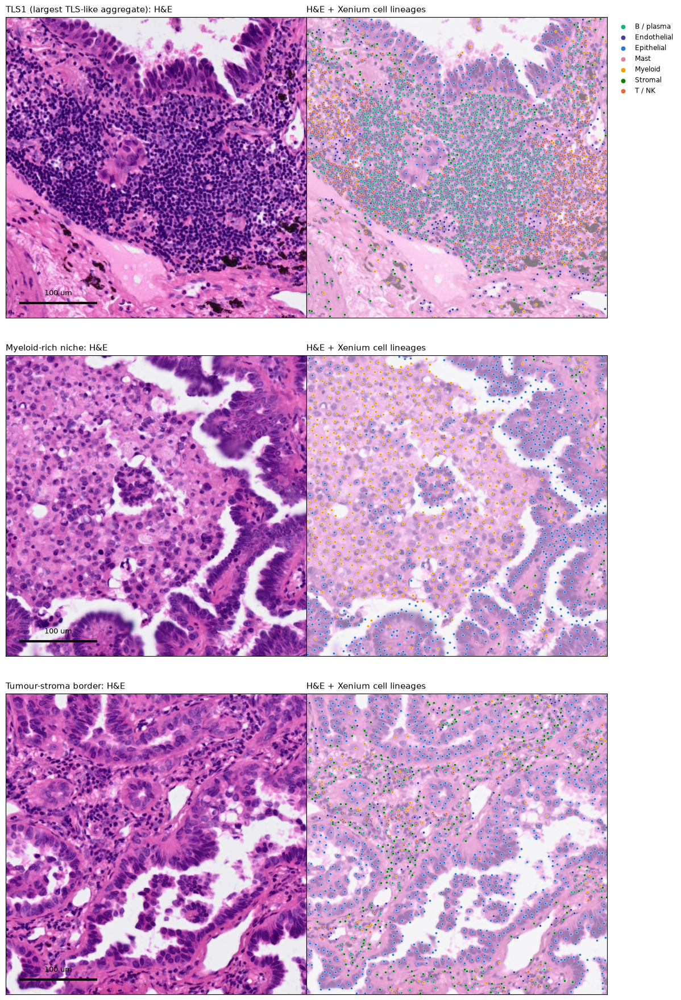

This is the payoff of alignment: each Xenium cell call can be checked against the histology a
pathologist reads (dense lymphoid aggregate, tumour glands, stroma), and vice versa.


In [32]:
adata = sc.read_h5ad(SPATIAL_PATH)   # Step 7: high-confidence cells with niches and TLS
xy = adata.obsm["spatial"]           # um
LINEAGE_COLORS = dict(zip(adata.obs["lineage"].cat.categories, adata.uns["lineage_colors"]))
CROP_UM = 400
CROP_RES = 0.5   # um per pixel in the zooms (H&E level 1 is ~0.55 um/px)


# Three windows chosen from the data (he.histology_windows): the largest TLS, the densest myeloid-rich
# niche and the 400 um tile with the most balanced tumour / stroma mix; he.he_crop reads only the
# H&E tiles under each window and warps them onto an aligned grid
REGIONS = he.histology_windows(adata, CROP_UM)

fig, axes = plt.subplots(len(REGIONS), 2, figsize=(12, 6 * len(REGIONS)))
for row, (name, (cx, cy)) in zip(axes, REGIONS.items()):
    img, (x0, y0) = he.he_crop(HE_PATH, M, cx, cy, CROP_UM, CROP_RES)
    ext = [x0, x0 + CROP_UM, y0 + CROP_UM, y0]
    row[0].imshow(img, extent=ext)
    row[0].set_title(f"{name}: H&E", loc="left", fontsize=11)
    row[1].imshow(img, extent=ext, alpha=0.55)
    inside = (xy[:, 0] > x0) & (xy[:, 0] < x0 + CROP_UM) & (xy[:, 1] > y0) & (xy[:, 1] < y0 + CROP_UM)
    for lin, col in LINEAGE_COLORS.items():
        m = inside & (adata.obs["lineage"] == lin).to_numpy()
        row[1].scatter(xy[m, 0], xy[m, 1], s=9, c=col, edgecolors="white", linewidths=0.3, label=lin)
    row[1].set_title("H&E + Xenium cell lineages", loc="left", fontsize=11)
    for ax in row:
        ax.set_xlim(x0, x0 + CROP_UM); ax.set_ylim(y0 + CROP_UM, y0)
        ax.set_xticks([]); ax.set_yticks([])
    row[0].plot([x0 + 20, x0 + 120], [y0 + CROP_UM - 20] * 2, color="#0b0b0b", lw=3)
    row[0].text(x0 + 70, y0 + CROP_UM - 30, "100 um", ha="center", fontsize=9)
axes[0, 1].legend(markerscale=2, frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()
print("This is the payoff of alignment: each Xenium cell call can be checked against the histology a\n"
      "pathologist reads (dense lymphoid aggregate, tumour glands, stroma), and vice versa.")

**Interpretation.**

- **TLS1:** a dense aggregate of small cells with dark nuclei, bordered by epithelium and fibrous tissue. Xenium calls the core predominantly B / plasma, with T / NK cells concentrated towards one side.
- **Myeloid-rich niche:** a loosely arranged population of larger cells with more abundant cytoplasm, bordered by epithelial structures. The overlay assigns most of these cells to the myeloid lineage and the bordering structures to the epithelial lineage.
- **Tumour–stroma border:** epithelial structures separated by narrow strands of stroma. Epithelial calls follow the epithelial structures, while stromal, T / NK, and myeloid calls lie mainly in the intervening strands.

Treat this apparent agreement as qualitative support for the annotations; histological classification requires pathology review.

### 8d. Extract stain features and save

Sample histology-derived stain intensity at cell centroids and save the dataset for downstream analysis.

Use `he.stain_features()` to map cell positions onto H&E pyramid level 2, approximately 1.1 µm per pixel. Store centroid-level hematoxylin and eosin optical densities in `obs["he_hematoxylin"]` and `obs["he_eosin"]`.

Record the alignment source, feature-extraction level, and registration QC results in `.uns["step8_params"]`. Inspect stain distributions and median values by lineage.

Note: These features sample a single pixel rather than the whole cell and are sensitive to residual misalignment and local staining variation. Eosin estimates from the unnormalised slide require particular caution. Deconvolving pyramid level 2 requires approximately 1 GB of memory.

The saved dataset retains the high-confidence cells from Step 7 and overwrites any existing file with the same name in `~/data/xenium_lung/processed/`. Notebook 05 builds on this alignment for foundation-model analysis.

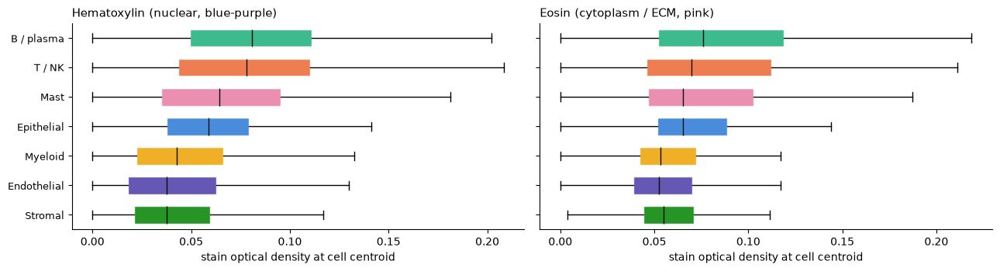

,he_hematoxylin,he_eosin
lineage,,
Stromal,0.038,0.055
Endothelial,0.038,0.052
Myeloid,0.043,0.053
Epithelial,0.059,0.065
Mast,0.064,0.065
T / NK,0.078,0.070
B / plasma,0.081,0.076


Hematoxylin is highest under B / plasma and T / NK (nucleus-packed lymphoid aggregates)
and lowest under Stromal and Endothelial: transcript-based labels track histology.
Eosin is less specific here: colour deconvolution of a single slide mixes it with overall
stain density, so stain normalisation would be needed before using it as a feature.
Per-cell H&E features like these are the bridge to histology-based models (e.g. predicting
cell types or gene expression from H&E).

Saved: ~/data/xenium_lung/processed/Xenium_V1_humanLung_Cancer_FFPE_he_features.h5ad (124 MB) with obs['he_hematoxylin'], obs['he_eosin']


In [33]:
# ---- Per-cell H&E features: stain intensity under every cell --------------------------
# Each cell centroid is mapped into H&E level-2 pixels (~1.1 um) and the hematoxylin / eosin optical
# density there is stored in obs['he_hematoxylin'] / obs['he_eosin'] (he.stain_features)
HE_LEVEL = 2
he.stain_features(adata, HE_PATH, M, HE_LEVEL)

feat = adata.obs.groupby("lineage", observed=True)[["he_hematoxylin", "he_eosin"]].median()
order = feat["he_hematoxylin"].sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, col, label in zip(axes, ["he_hematoxylin", "he_eosin"], ["Hematoxylin (nuclear, blue-purple)", "Eosin (cytoplasm / ECM, pink)"]):
    data = [adata.obs.loc[adata.obs["lineage"] == l, col].to_numpy() for l in order]
    bp = ax.boxplot(data, orientation="horizontal", showfliers=False, widths=0.6, patch_artist=True,
                    medianprops=dict(color="#0b0b0b"))
    for patch, l in zip(bp["boxes"], order):
        patch.set_facecolor(LINEAGE_COLORS[l]); patch.set_alpha(0.85); patch.set_edgecolor("white")
    ax.set_yticks(range(1, len(order) + 1), order, fontsize=9)
    ax.set_title(label, loc="left", fontsize=11)
    ax.set_xlabel("stain optical density at cell centroid")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()
display(feat.loc[order].round(3))
h = feat["he_hematoxylin"].sort_values()
print(f"Hematoxylin is highest under {h.index[-1]} and {h.index[-2]} (nucleus-packed lymphoid aggregates)\n"
      f"and lowest under {h.index[0]} and {h.index[1]}: transcript-based labels track histology.\n"
      "Eosin is less specific here: colour deconvolution of a single slide mixes it with overall\n"
      "stain density, so stain normalisation would be needed before using it as a feature.\n"
      "Per-cell H&E features like these are the bridge to histology-based models (e.g. predicting\n"
      "cell types or gene expression from H&E).")

# ---- Save ------------------------------------------------------------------------------------
adata.uns["step8_params"] = {"alignment": "10x he_imagealignment.csv (H&E px -> Xenium px)",
                             "he_feature_level": HE_LEVEL, "qc_best_shift_um": [float(shifts[ix] * RES_UM),
                                                                              float(shifts[iy] * RES_UM)],
                             "qc_r_zero_shift": float(corr[10, 10])}
adata.write_h5ad(HE_FEATURES_PATH, compression="gzip")
print(f"\nSaved: ~/data/xenium_lung/processed/{HE_FEATURES_PATH.name} "
      f"({HE_FEATURES_PATH.stat().st_size / 1e6:.0f} MB) with obs['he_hematoxylin'], obs['he_eosin']")

**Interpretation.** B / plasma cells have the highest median centroid-level hematoxylin optical density (0.081), followed by T / NK cells (0.078); stromal and endothelial cells have the lowest (0.038). This ordering is consistent with the dense nuclei of lymphoid aggregates. Eosin medians span a narrower range (0.052–0.076) and largely follow the same order, suggesting that the eosin estimate partly reflects overall stain density. These comparisons reflect staining at sampled cell positions and remain sensitive to alignment, centroid placement, and local image variation.

**Optional viewing.** To inspect the alignment interactively, open `outs/experiment.xenium` in Xenium Explorer and add the H&E image with the same alignment file.

## Step 9: Tumour immune states and spatial interactions

Characterise immune-cell expression states and their spatial relationships with tumour cells using the neighbourhoods, niches, and TLS-like aggregates defined in Step 7.

Load the spatial dataset from Step 7, which contains high-confidence cells only. Earlier steps do not need to be repeated.

Define gene positivity as at least one transcript in the raw-count matrix. Compare the percentage of positive cells within each cell type rather than absolute positive-cell counts, which are strongly influenced by population size.

Use pooled tumour-cell positivity as an operational reference for potential background or spillover. This reference is not a measured technical noise floor and may include genuine tumour expression.

The workflow uses the following analyses:

| Analysis | Purpose | Method |
|---|---|---|
| Checkpoint expression | Compare checkpoint and co-stimulatory gene detection across cell types | Cell-type positivity rates relative to the pooled tumour reference |
| CD8 T-cell states | Compare expression across spatial compartments | Gene positivity rates, chi-square tests, and Benjamini–Hochberg correction |
| Ligand–receptor contacts | Assess adjacency between ligand-positive and receptor-positive cells | Graph-contact counts compared with 1,000 within-cell-type expression shuffles |
| Tile phenotypes | Describe regional CD8 T-cell distributions | Classify 400 µm tumour-containing tiles and assess cutoff sensitivity |
| Immune-population balance | Compare selected population ratios by location | Cell-count ratios across tumour-distance bands and TLS-like aggregates |

This step assesses checkpoint expression (9a), compares CD8 T-cell states (9b), tests ligand–receptor contacts (9c), classifies tumour tiles (9d), summarises immune-population ratios (9e), and saves the results (9f).

### 9a. Assess checkpoint expression

Compare checkpoint and co-stimulatory gene detection across annotated cell types. Select the `spatial_env` kernel before running this cell.

Use `tme.Positivity()` to define positivity from raw counts and `tme.positivity_rates()` to calculate the percentage of positive cells for each gene in `tme.CHECKPOINTS`. Pool tumour populations as `Tumour (all)` to provide the reference rate.

Use `tme.above_noise_floor()` to identify cell types with positivity rates exceeding three times the reference and reaching at least 5%. Apply a minimum reference rate of 0.5%.

Inspect the positivity heatmap, reference row, cell-type population sizes, and table of populations meeting the thresholds.

Note: Positivity measures transcript detection, not protein abundance or functional activity. Sparse detection can obscure expression, while a single transcript may reflect spillover. The tumour reference is an operational comparison rather than an independently measured background level.

139,129 high-confidence cells from Step 7



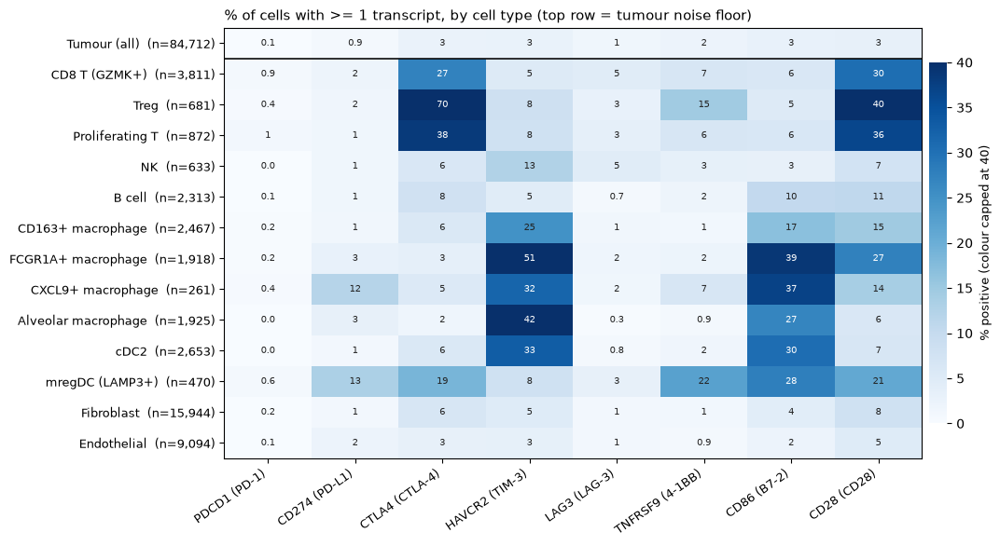

,cell types above 3x the tumour noise floor (and >= 5%)
PDCD1 (PD-1),none above 3x noise floor
CD274 (PD-L1),"CXCL9+ macrophage, mregDC (LAMP3+)"
CTLA4 (CTLA-4),"CD8 T (GZMK+), Treg, Proliferating T, B cell, mregDC (LAMP3+)"
HAVCR2 (TIM-3),"Treg, NK, CD163+ macrophage, FCGR1A+ macrophage, CXCL9+ macrophage, Alveolar..."
LAG3 (LAG-3),none above 3x noise floor
TNFRSF9 (4-1BB),"Treg, mregDC (LAMP3+)"
CD86 (B7-2),"B cell, CD163+ macrophage, FCGR1A+ macrophage, CXCL9+ macrophage, Alveolar m..."
CD28 (CD28),"CD8 T (GZMK+), Treg, Proliferating T, B cell, CD163+ macrophage, FCGR1A+ mac..."


PD-L1 sits on CXCL9+ macrophages and mregDCs, not on tumour cells. TIM-3 is enriched in
macrophages and cDC2 (and NK cells / Tregs); CTLA-4 and CD28 in T cells, Tregs highest. PD-1 and
LAG-3 never rise above the noise floor: too sparse on this panel to call per cell type.


In [34]:
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError("Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)'.")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display
from matplotlib.patches import Rectangle

from ist_analysis import tme
from ist_analysis import utils as xu

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SPATIAL_PATH = xu.STEP_FILES["spatial"]   # Step 7 output
TIME_PATH = xu.STEP_FILES["time"]         # Step 9 output

adata = sc.read_h5ad(SPATIAL_PATH)
xy = adata.obsm["spatial"]
cell_type = adata.obs["cell_type"].astype(str)
TUMOUR_TYPES = xu.TUMOUR_TYPES
is_tumour = cell_type.isin(TUMOUR_TYPES).to_numpy()
positive = tme.Positivity(adata)   # positive(gene): boolean per cell, >= 1 transcript


print(f"{adata.n_obs:,} high-confidence cells from Step 7\n")

# ---- Who expresses the immune checkpoints? Positivity RATE within each cell type ----
# Counting positive cells is misleading: tumour cells are 60% of cells, so even a 1% background
# rate makes them the largest 'positive' group. Rates per type, against the tumour noise floor,
# are the honest comparison.
CHECKPOINT_GENES = tme.CHECKPOINTS   # gene -> protein name
SHOW_TYPES = ["Tumour (all)", "CD8 T (GZMK+)", "Treg", "Proliferating T", "NK", "B cell",
              "CD163+ macrophage", "FCGR1A+ macrophage", "CXCL9+ macrophage", "Alveolar macrophage",
              "cDC2", "mregDC (LAMP3+)", "Fibroblast", "Endothelial"]
group = np.where(is_tumour, "Tumour (all)", cell_type)
rates = tme.positivity_rates(positive, group, CHECKPOINT_GENES, SHOW_TYPES)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(rates.to_numpy(), cmap="Blues", vmin=0, vmax=40, aspect="auto")
ax.set_xticks(range(rates.shape[1]), rates.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(rates)), [f"{t}  (n={(group == t).sum():,})" for t in rates.index], fontsize=9)
for (i, j), v in np.ndenumerate(rates.to_numpy()):
    ax.text(j, i, f"{v:.0f}" if v >= 1 else f"{v:.1f}", ha="center", va="center", fontsize=7.5,
            color="white" if v > 25 else "#222222")
ax.axhline(0.5, color="#0b0b0b", lw=1.2)
ax.set_title("% of cells with >= 1 transcript, by cell type (top row = tumour noise floor)", loc="left", fontsize=11)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
cb.set_label("% positive (colour capped at 40)", fontsize=9)
cb.outline.set_visible(False)
plt.show()

display(tme.above_noise_floor(rates).rename("cell types above 3x the tumour noise floor (and >= 5%)").to_frame())
print("PD-L1 sits on CXCL9+ macrophages and mregDCs, not on tumour cells. TIM-3 is enriched in\n"
      "macrophages and cDC2 (and NK cells / Tregs); CTLA-4 and CD28 in T cells, Tregs highest. PD-1 and\n"
      "LAG-3 never rise above the noise floor: too sparse on this panel to call per cell type.")

**Interpretation.** Tumour cells (60.9% of the 139,129 cells) provide reference rates of 0.1–3.2% across the eight genes.

- **PD-L1 (`CD274`)** meets the threshold only in CXCL9+ macrophages (11.9% of 261 cells) and mregDCs (13.2% of 470), compared with 0.9% of tumour cells.
- **CTLA-4** is detected most often in Tregs (69.6% of 681), followed by proliferating T cells (38.4%) and GZMK+ CD8 T cells (27.3%).
- **TIM-3 (`HAVCR2`)** is most frequent in myeloid populations: FCGR1A+ macrophages (50.6%), cDC2 (33.0%), CXCL9+ macrophages (31.8%) and CD163+ macrophages (25.0%).
- **PD-1 (`PDCD1`) and LAG-3** do not meet the thresholds in any cell type. PD-1 is detected in 208 of the 139,129 cells (213 transcripts), and LAG-3 reaches at most 4.6%. Low detection limits these genes; it does not establish absence of expression.

### 9b. Compare CD8 T-cell states by location

Assess whether expression within the GZMK+ CD8 T-cell population varies across spatial compartments.

Use `tme.add_cd8_compartments()` to assign cells to four compartments in `obs["cd8_compartment"]`:

- TLS-like aggregate.
- Tumour proximity: ≤ 15 µm.
- Tumour border: > 15–50 µm.
- Stroma: > 50 µm.

TLS-like aggregate membership takes precedence over tumour distance.

Use `tme.cd8_states()` to calculate positivity rates for genes in `tme.CD8_STATES` within GZMK+ CD8 T cells in each compartment. Test differences across compartments using chi-square tests and Benjamini–Hochberg correction. Include `EPCAM` and `MALL` as epithelial spillover controls.

Inspect compartment sizes, the positivity heatmap, and genes with `FDR < 0.05`. Compare expression trends with those of the epithelial controls.

Note: Tumour-associated expression in nearby CD8 T cells may reflect segmentation spillover. Trends that parallel epithelial controls require cautious interpretation, especially for genes also expressed by tumour cells. The stroma compartment is defined by distance, not independent histological annotation.

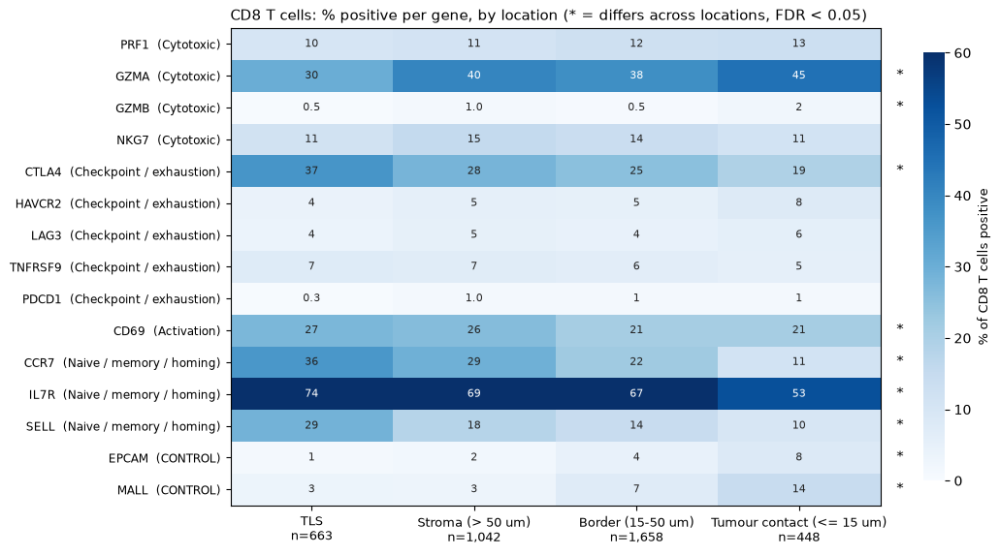

Gradient from TLS to tumour: CCR7+ falls 36% -> 11%, i.e. CD8 T cells lose
lymphoid-homing / memory features as they approach the tumour, while cytotoxic GZMA rises
(30% -> 45%) and CTLA-4 falls (37% -> 19%): an effector-like
shift at the tumour border. But the spillover CONTROL rises too
(EPCAM 1.4% -> 8.0%): small increases in tumour-expressed genes in
tumour-contact T cells (e.g. HAVCR2, GZMB) cannot be separated from contamination on this data.


In [35]:
# ---- CD8 T-cell states by location ---------------------------------------------------
d_tumour = adata.obs["dist_to_tumour_um"].to_numpy()
in_tls = (adata.obs["tls_id"] != "none").to_numpy()
tme.add_cd8_compartments(adata)   # obs['cd8_compartment']: TLS / stroma (> 50 um) / border (15-50 um) / contact (<= 15 um)
COMPARTMENTS = tme.COMPARTMENTS
cd8 = (cell_type == "CD8 T (GZMK+)").to_numpy()
comp = adata.obs["cd8_compartment"].to_numpy()[cd8]
STATE_GENES = tme.CD8_STATES      # state: genes on this panel (EPCAM / MALL = spillover control)
# % of CD8 T cells positive per gene and compartment; chi-square across compartments, BH-corrected
states = tme.cd8_states(adata, positive, STATE_GENES)
n_per = pd.Series(comp).value_counts().reindex(COMPARTMENTS)

fig, ax = plt.subplots(figsize=(9.5, 6.4))
mat = states[COMPARTMENTS].to_numpy()
im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=60, aspect="auto")
ax.set_xticks(range(len(COMPARTMENTS)), [f"{c}\nn={n:,}" for c, n in n_per.items()], fontsize=9)
labels = [f"{r.gene}  ({r.state.split(':')[0] if r.state.startswith('CONTROL') else r.state})" for r in states.itertuples()]
ax.set_yticks(range(len(states)), labels, fontsize=8.5)
for (i, j), v in np.ndenumerate(mat):
    ax.text(j, i, f"{v:.0f}" if v >= 1 else f"{v:.1f}", ha="center", va="center", fontsize=8,
            color="white" if v > 38 else "#222222")
for i, q in enumerate(states["FDR q"]):
    ax.text(len(COMPARTMENTS) - 0.4, i, "*" if q < 0.05 else "", va="center", fontsize=11)
ax.set_title("CD8 T cells: % positive per gene, by location (* = differs across locations, FDR < 0.05)",
             loc="left", fontsize=10.5)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.06)
cb.set_label("% of CD8 T cells positive", fontsize=9)
cb.outline.set_visible(False)
plt.show()
display(states.set_index(["state", "gene"]).style.format({c: "{:.1f}" for c in COMPARTMENTS} | {"FDR q": "{:.1e}"}))

by_gene = states.set_index("gene")
gzma, ctla4 = by_gene.loc["GZMA", COMPARTMENTS], by_gene.loc["CTLA4", COMPARTMENTS]
ccr7 = by_gene.loc["CCR7", COMPARTMENTS]
epcam = states.set_index("gene").loc["EPCAM", COMPARTMENTS]
print(f"Gradient from TLS to tumour: CCR7+ falls {ccr7.iloc[0]:.0f}% -> {ccr7.iloc[-1]:.0f}%, i.e. CD8 T cells lose\n"
      "lymphoid-homing / memory features as they approach the tumour, while cytotoxic GZMA rises\n"
      f"({gzma.iloc[0]:.0f}% -> {gzma.iloc[-1]:.0f}%) and CTLA-4 falls ({ctla4.iloc[0]:.0f}% -> {ctla4.iloc[-1]:.0f}%): an effector-like\n"
      "shift at the tumour border. But the spillover CONTROL rises too\n"
      f"(EPCAM {epcam.iloc[0]:.1f}% -> {epcam.iloc[-1]:.1f}%): small increases in tumour-expressed genes in\n"
      "tumour-contact T cells (e.g. HAVCR2, GZMB) cannot be separated from contamination on this data.")

**Interpretation.** The comparison includes 3,811 GZMK+ CD8 T cells: 663 in TLS-like aggregates, 1,042 in stroma, 1,658 at the border and 448 within 15 µm of tumour.

- From TLS-like aggregates to tumour proximity, naive / memory / homing genes decline: `CCR7` 36.0% → 11.2%, `SELL` 28.7% → 9.8%, `IL7R` 73.6% → 52.7% (all FDR < 10⁻¹¹). `CTLA4` also declines (36.5% → 19.4%, FDR 9 × 10⁻¹⁰).
- `GZMA` increases (30.2% → 44.9%, FDR 6 × 10⁻⁶). It is detected in only 2.1% of tumour cells, so spillover is unlikely to account for this rise.
- The epithelial controls also rise towards the tumour (`EPCAM` 1.4% → 8.0%, `MALL` 3.2% → 14.1%), confirming that spillover increases near tumour cells. The declining genes move against this trend, but the smaller increases in `GZMB` (0.5% → 2.0%) and `HAVCR2` (3.9% → 7.6%, not significant) cannot be separated from spillover.
- `PDCD1` remains at or below 1.1% in every compartment.

Together, these results describe an effector-like shift with reduced lymphoid-homing features near the tumour. Notebook 02 reproduces the `CCR7` decline after Proseg resegmentation, when the epithelial controls fall close to zero.

### 9c. Test ligand–receptor spatial contacts

Assess whether ligand-positive senders are adjacent to receptor-positive receivers more often than expected under within-cell-type expression shuffling.

Use `tme.contact_test()` to evaluate the six pairs in `tme.LR_PAIRS` on the Step 7 spatial graph. Restrict senders and receivers to the specified plausible lineages and count graph edges connecting positive cells.

Generate a null distribution using `N_PERMS = 1000` shuffles of gene positivity within each cell type. This retains cell positions, graph structure, and cell-type positivity rates.

Report observed and expected contacts, their ratio, z-score, one-sided permutation p-value, and Benjamini–Hochberg FDR.

Inspect the results table, positive sender and receiver counts, and the plot of `log2(observed / expected)` contacts.

Note: Enrichment supports spatial co-occurrence of detected transcripts, not demonstrated signalling. Sparse positive populations limit interpretability, and non-significance does not establish absence of an interaction. `HLA-DQB2` is used as a single-gene proxy for MHC class II.

,biology,senders +,receivers +,observed contacts,expected,obs / exp,z,p (perm),FDR q
pair,,,,,,,,,
CD274 -> PDCD1,PD-L1 -> PD-1: checkpoint inhibition,"1,072",46,1,2,0.45,-0.8,0.8961,0.8961
CD86 -> CTLA4,B7-2 -> CTLA-4: checkpoint inhibition,"3,556","1,886",527,520,1.01,0.3,0.3886,0.5829
CD86 -> CD28,B7-2 -> CD28: T-cell co-stimulation,"3,556","1,798",511,497,1.03,0.6,0.2967,0.5829
CCL19 -> CCR7,CCL19 -> CCR7: lymphoid homing (TLS),"2,008","2,447","2,824",1203,2.35,44.1,0.0010,0.0030
HLA-DQB2 -> CD4,MHC-II -> CD4: antigen presentation,"4,248","6,781","4,430",3893,1.14,8.5,0.0010,0.0030
EDN1 -> EDNRB,Endothelin-1 -> EDNRB: vascular,"19,570","3,389","1,347",1367,0.99,-0.5,0.7143,0.8571


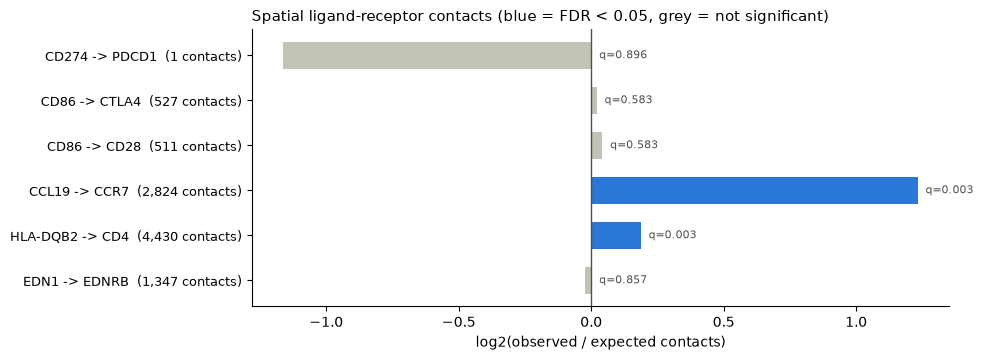

Read with the 'receivers +' column: PD-1 has so few positive T cells that a PD-L1/PD-1 effect
is undetectable here (a power problem, not evidence of absence). Full ligand-receptor databases
(squidpy.gr.ligrec, LIANA) become worthwhile on the 5,000-gene panel (Dataset B).


In [36]:
# ---- Spatial ligand-receptor contact test ------------------------------------------------
# For each pair: count graph edges where a sender cell expresses the ligand and its neighbour
# (a receiver) expresses the receptor. Null: shuffle each gene's expression WITHIN each cell
# type (keeps composition and per-type expression rates), 1,000 times. Enrichment then means
# 'ligand+ senders touch receptor+ receivers more than other cells of the same types do'.
N_PERMS = 1000
PAIRS = tme.LR_PAIRS   # (ligand, receptor, sender lineages, receiver lineages, biology)
lr = tme.contact_test(adata, positive, PAIRS, N_PERMS, seed=0)
display(lr.style.format({"expected": "{:.0f}", "obs / exp": "{:.2f}", "z": "{:.1f}",
                         "p (perm)": "{:.4f}", "FDR q": "{:.4f}", "senders +": "{:,}", "receivers +": "{:,}",
                         "observed contacts": "{:,}"}))

fig, ax = plt.subplots(figsize=(9, 3.6))
y = np.arange(len(lr))[::-1]
log2r = np.log2(lr["obs / exp"].clip(lower=1e-3))
sig = lr["FDR q"] < 0.05
ax.barh(y, log2r, color=np.where(sig, "#2a78d6", "#c3c2b7"), height=0.6)
ax.axvline(0, color="#52514e", lw=1)
ax.set_yticks(y, [f"{p}  ({o:,} contacts)" for p, o in zip(lr.index, lr["observed contacts"])], fontsize=9)
for yi, v, q in zip(y, log2r, lr["FDR q"]):
    ax.text(max(v, 0) + 0.03, yi, f"q={q:.3f}", va="center", ha="left", fontsize=8, color="#52514e")
ax.set_xlabel("log2(observed / expected contacts)")
ax.set_title("Spatial ligand-receptor contacts (blue = FDR < 0.05, grey = not significant)", loc="left", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()
print("Read with the 'receivers +' column: PD-1 has so few positive T cells that a PD-L1/PD-1 effect\n"
      "is undetectable here (a power problem, not evidence of absence). Full ligand-receptor databases\n"
      "(squidpy.gr.ligrec, LIANA) become worthwhile on the 5,000-gene panel (Dataset B).")

**Interpretation.**

- **CCL19 → CCR7:** 2,824 observed contacts against 1,203 expected (2.35×, z 44.1, FDR 0.003), the strongest enrichment, consistent with lymphoid homing around the TLS-like aggregates.
- **HLA-DQB2 → CD4:** 4,430 against 3,893 expected (1.14×, z 8.5, FDR 0.003), a modest enrichment.
- **CD86 → CTLA4, CD86 → CD28 and EDN1 → EDNRB:** within 3% of expectation (0.99–1.03×) and not significant.
- **PD-L1 → PD-1:** only 46 receptor-positive receivers and one observed contact (two expected), so the test has no power for this pair.

With 1,000 permutations the smallest attainable p-value is about 0.001, so the two significant pairs are at the resolution limit of the test. These results describe transcript-associated graph adjacency, not physical contact or signalling.

### 9d. Classify tumour-region immune phenotypes

Describe tumour-containing regions using operational inflamed, excluded, and desert labels.

Use `tme.tile_phenotypes()` to divide the section into `TILE_UM = 400` µm tiles. Score tiles containing at least `MIN_TUMOUR_CELLS = 50` tumour cells.

Calculate two CD8 T-cell densities using segmented cell area:

- Intratumoral-proximity density: CD8 T cells within 15 µm of tumour cells, divided by tumour-cell area.
- Stromal density: remaining CD8 T cells, divided by non-tumour cell area.

Use `tme.classify_tiles()` to assign phenotypes:

- Desert: total CD8 density below `DESERT_DENSITY = 50`.
- Inflamed: non-desert tiles with intratumoral-proximity density at least `INFLAMED_RATIO = 0.5` times stromal density.
- Excluded: remaining scored tiles.

Assign each tile to its most frequent tumour programme. Use `tme.sensitivity()` to repeat classification across a 3 × 3 grid of desert thresholds `(25, 50, 100)` and density-ratio thresholds `(0.3, 0.5, 0.7)`.

Inspect phenotype percentages by tumour programme, the sensitivity table, and spatial tile map.

Note: These labels use heuristic cutoffs and centroid proximity rather than direct identification of cells inside tumour nests. Densities are normalised by segmented cell area, not tissue area. The sensitivity grid contains nine settings: the default and eight alternatives. Tile labels describe local regions, not patient-level immune phenotypes.

phenotype,inflamed,excluded,desert,tiles
programme,,,,
Tumour epithelial (CYP2B6/CFTR),13%,77%,11%,47
Tumour epithelial (MALL/TCIM),9%,82%,9%,34
Tumour epithelial (MYC/CAPN8),5%,34%,61%,38
All tumour tiles,9%,65%,26%,119


Sensitivity of the overall split to the two cutoffs (% of tiles):


,inflamed,excluded,desert
"desert<25, ratio>=0.3",18,68,14
"desert<25, ratio>=0.5",13,73,14
"desert<25, ratio>=0.7",11,75,14
"desert<50, ratio>=0.3",13,61,26
"desert<50, ratio>=0.5",9,65,26
"desert<50, ratio>=0.7",8,66,26
"desert<100, ratio>=0.3",8,50,41
"desert<100, ratio>=0.5",5,54,41
"desert<100, ratio>=0.7",3,55,41


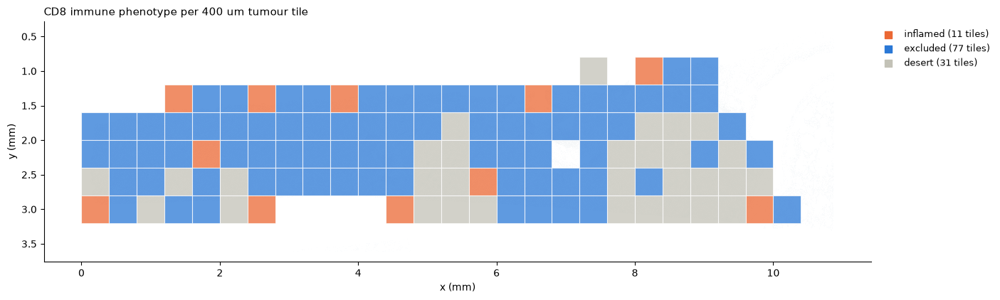

In [37]:
# ---- Immune phenotype per tumour region: inflamed / excluded / desert ----------------------
# Framework of Chen & Mellman (2017): inflamed = CD8 T cells inside tumour nests; excluded =
# CD8 T cells present but held in the stroma; desert = few CD8 T cells anywhere.
TILE_UM = 400          # tile size
MIN_TUMOUR_CELLS = 50  # tiles with less tumour are not scored
DESERT_DENSITY = 50    # CD8 / mm^2 of cell area below which a tile is 'desert' (~25th percentile)
INFLAMED_RATIO = 0.5   # intratumoral CD8 density >= 0.5 x stromal density -> 'inflamed'

# CD8 densities per tile (cells per mm^2 of cell area), intratumoral (<= 15 um) vs stromal (tme.tile_phenotypes)
tiles, tile_key = tme.tile_phenotypes(adata, is_tumour, TILE_UM, MIN_TUMOUR_CELLS)


def classify(t, desert=DESERT_DENSITY, ratio=INFLAMED_RATIO):
    return tme.classify_tiles(t, desert, ratio)


tiles["phenotype"] = classify(tiles)
PHENO_ORDER = ["inflamed", "excluded", "desert"]
PHENO_COLORS = {"inflamed": "#eb6834", "excluded": "#2a78d6", "desert": "#c3c2b7"}

by_prog = tme.phenotype_by_programme(tiles)
display(by_prog.style.format({p: "{:.0f}%" for p in PHENO_ORDER} | {"tiles": "{:.0f}"}))

# Sensitivity: does the conclusion survive other reasonable cutoffs?
sens = tme.sensitivity(tiles)   # % of tiles per phenotype under alternative cutoffs
print("Sensitivity of the overall split to the two cutoffs (% of tiles):")
display(sens.style.format("{:.0f}"))

fig, ax = plt.subplots(figsize=(15, 4.8))
ax.scatter(xy[:, 0] / 1000, xy[:, 1] / 1000, s=0.03, c="#e3e6ea", linewidths=0, rasterized=True)
for (tx, ty), r in tiles.iterrows():
    ax.add_patch(Rectangle((tx * TILE_UM / 1000, ty * TILE_UM / 1000), TILE_UM / 1000, TILE_UM / 1000,
                           facecolor=PHENO_COLORS[r.phenotype], alpha=0.75, edgecolor="white", lw=0.8))
for p in PHENO_ORDER:
    ax.scatter([], [], marker="s", s=60, c=PHENO_COLORS[p], label=f"{p} ({(tiles.phenotype == p).sum()} tiles)")
ax.set_aspect("equal"); ax.invert_yaxis()
ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1), fontsize=9)
ax.set_title(f"CD8 immune phenotype per {TILE_UM} um tumour tile", loc="left", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

**Interpretation.** Of the 119 tiles with at least 50 tumour cells, 65% are classified as excluded, 26% as desert and 9% as inflamed; percentages refer to tiles, not cells or area.

- The tumour programmes differ: MALL/TCIM tiles (34) and CYP2B6/CFTR tiles (47) are mostly excluded (82% and 77%), whereas MYC/CAPN8 tiles (38) are mostly desert (61%).
- Across the nine cutoff settings, excluded remains the most frequent label (50–75% of tiles). The desert fraction depends mainly on the desert threshold (14%, 26% and 41% at 25, 50 and 100 CD8 T cells per mm²), and the inflamed fraction ranges from 3% to 18%.

The predominance of excluded tiles is therefore robust to these cutoffs, while the desert and inflamed fractions are threshold-dependent.

### 9e. Compare immune-population ratios by location

Summarise selected immune-population balances across tumour-distance bands and TLS-like aggregates.

Use `tme.ratio_by_band()` to calculate ratios for TLS-like aggregates and four distance bands: ≤ 15 µm, > 15–50 µm, > 50–100 µm, and > 100 µm from tumour.

Report two cell-count ratios:

- Treg : CD8 T cells.
- CD163+ macrophages : CXCL9+ macrophages.

Inspect the ratio plots, underlying population counts, and summary table.

Note: Small denominators can produce unstable ratios. These comparisons describe population composition rather than directly measuring suppressive activity. The code's M1-like and M2-like labels are shorthand for the selected macrophage states, not a binary classification.

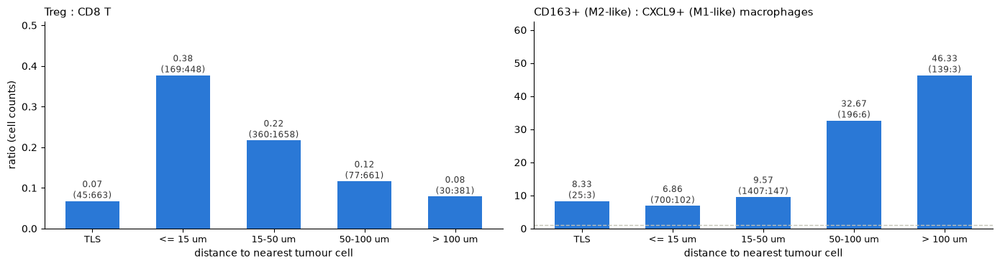

ratio,CD163+ (M2-like) : CXCL9+ (M1-like) macrophages,Treg : CD8 T
location,,
TLS,8.33,0.07
<= 15 um,6.86,0.38
15-50 um,9.57,0.22
50-100 um,32.67,0.12
> 100 um,46.33,0.08


Treg:CD8 rises toward the tumour (relatively more suppression where T cells meet tumour), and
M2-like CD163+ macrophages outnumber interferon-activated CXCL9+ macrophages everywhere, most of
all far from the tumour. Counts are shown in brackets: small denominators make ratios noisy.


In [38]:
# ---- Immunosuppressive balance with distance from tumour --------------------------------
BANDS = tme.distance_bands(adata)[1]
RATIOS = {
    "Treg : CD8 T": ("Treg", "CD8 T (GZMK+)"),
    "CD163+ (M2-like) : CXCL9+ (M1-like) macrophages": ("CD163+ macrophage", "CXCL9+ macrophage"),
}
bal = pd.concat([tme.ratio_by_band(adata, num, den).assign(ratio=name) for name, (num, den) in RATIOS.items()], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for ax, (name, sub) in zip(axes, bal.groupby("ratio", sort=False)):
    vals = sub["value"].to_numpy()
    ax.bar(range(len(BANDS)), vals, color="#2a78d6", width=0.6)
    for i, (v, n1, n2) in enumerate(zip(vals, sub["numerator"], sub["denominator"])):
        ax.text(i, v, f"{v:.2f}\n({n1}:{n2})", ha="center", va="bottom", fontsize=8.5, color="#333333")
    ax.axhline(1, color="#c3c2b7", lw=1, ls="--")
    ax.set_xticks(range(len(BANDS)), BANDS, fontsize=9)
    ax.set_ylim(0, np.nanmax(vals) * 1.35)
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_xlabel("distance to nearest tumour cell")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("ratio (cell counts)")
plt.tight_layout()
plt.show()
display(bal.pivot(index="location", columns="ratio", values="value").reindex(BANDS).round(2))
print("Treg:CD8 rises toward the tumour (relatively more suppression where T cells meet tumour), and\n"
      "M2-like CD163+ macrophages outnumber interferon-activated CXCL9+ macrophages everywhere, most of\n"
      "all far from the tumour. Counts are shown in brackets: small denominators make ratios noisy.")

**Interpretation.**

- **Treg : CD8 T cells** is highest within 15 µm of tumour (0.38; 169 : 448) and lower at the border (0.22; 360 : 1,658), in stroma 50–100 µm away (0.12; 77 : 661), beyond 100 µm (0.08; 30 : 381) and in TLS-like aggregates (0.07; 45 : 663). CD8 T cells near the tumour are therefore accompanied by proportionally more Tregs.
- **CD163+ : CXCL9+ macrophages** exceeds 1 in every band. Near the tumour the ratio rests on adequate counts (6.9 at ≤ 15 µm, 700 : 102; 9.6 at 15–50 µm, 1,407 : 147). In TLS-like aggregates and beyond 50 µm only 3–6 CXCL9+ macrophages are present, so the higher ratios there (8.3–46.3) are unstable.

These ratios describe population composition, not measured suppressive activity.

### 9f. Save the immune-microenvironment dataset

Save the spatial expression summaries and regional annotations for Step 10 and subsequent analyses.

Map tile phenotypes to `obs["immune_tile_phenotype"]`, assigning `not scored` to cells outside scored tiles. Record permutation, tile, and cutoff settings in `.uns["step9_params"]`.

Store ligand–receptor results in `.uns["step9_lr_results"]` using HDF5-compatible column names.

Inspect the saved file size and confirm that `.obs` contains `cd8_compartment` and `immune_tile_phenotype`.

Note: `cd8_compartment` is assigned to every cell, although the expression comparison in Step 9b uses GZMK+ CD8 T cells only. The dataset retains the high-confidence cells from Step 7 and overwrites any existing file with the same name in `~/data/xenium_lung/processed/`.

In [39]:
# ---- Save -------------------------------------------------------------------------------
adata.obs["immune_tile_phenotype"] = pd.Categorical(
    tile_key.map(tiles["phenotype"].to_dict()).fillna("not scored"),
    categories=PHENO_ORDER + ["not scored"])
adata.uns["step9_params"] = {
    "lr_perms": N_PERMS, "lr_null": "expression shuffled within cell type",
    "tile_um": TILE_UM, "min_tumour_cells": MIN_TUMOUR_CELLS,
    "desert_density_per_mm2": DESERT_DENSITY, "inflamed_ratio": INFLAMED_RATIO,
}
lr_store = lr.reset_index()
lr_store.columns = [c.replace(" / ", "_over_").replace(" +", "_pos").replace(" ", "_").replace("(", "").replace(")", "")
                    for c in lr_store.columns]   # HDF5 keys cannot contain "/"
lr_store["pair"] = lr_store["pair"].str.replace(" -> ", "_to_")
adata.uns["step9_lr_results"] = lr_store
adata.write_h5ad(TIME_PATH, compression="gzip")
print(f"Saved: ~/data/xenium_lung/processed/{TIME_PATH.name} ({TIME_PATH.stat().st_size / 1e6:.0f} MB) "
      "with obs['cd8_compartment'], obs['immune_tile_phenotype'] and the ligand-receptor table.")

Saved: ~/data/xenium_lung/processed/Xenium_V1_humanLung_Cancer_FFPE_time.h5ad (122 MB) with obs['cd8_compartment'], obs['immune_tile_phenotype'] and the ligand-receptor table.


## Step 10: squidpy spatial statistics

Steps 7 and 9 used two squidpy functions (`spatial_neighbors`, `nhood_enrichment`) plus custom code. This step runs squidpy's other core spatial statistics, each answering a different question:

| Part | squidpy function | Question |
|---|---|---|
| 10a | `gr.spatial_autocorr` (Moran's I) | Which **genes** are spatially patterned? |
| 10b | `gr.co_occurrence` | How far does an association between cell types reach? |
| 10c | `gr.ripley` (L) | How clustered is each cell type against itself? |
| 10d | `gr.centrality_scores`, `gr.interaction_matrix` | How does each cell type sit in the contact network? |
| 10e | `gr.ligrec` | Which ligand-receptor pairs could cell types use, from expression alone? |

Runtime ~1 min. Two scaling lessons are built in: Moran's I uses the analytical p-value (`n_perms=None`; 100 permutations ran > 10 min), and co-occurrence / Ripley run on subsamples (Ripley's L on all 139k cells ran > 150 s).

### 10a. Moran's I: spatially variable genes

**Finding:** the most patterned genes mark tissue compartments: tumour programmes (CYP2B6, MALL, MYC), the airway (C20orf85, ciliated), B-cell aggregates (MS4A1) and smooth muscle (MYH11). Among immune signals **CXCL9 forms hotspots (I = 0.41, rank 11)**, the interferon-driven chemokine that recruits T cells; PD-1 has no spatial signal. With ~140k cells, 356 of 377 genes are 'significant', so rank by I, not p.

squidpy 1.8.3; 139,129 cells; Step 7 spatial graph with 818,760 edges

Moran's I for 377 genes in 16 s; 356 of 377 have FDR < 0.05.
With ~140k cells nearly every gene is 'significant': rank by the effect size I, not the p-value.



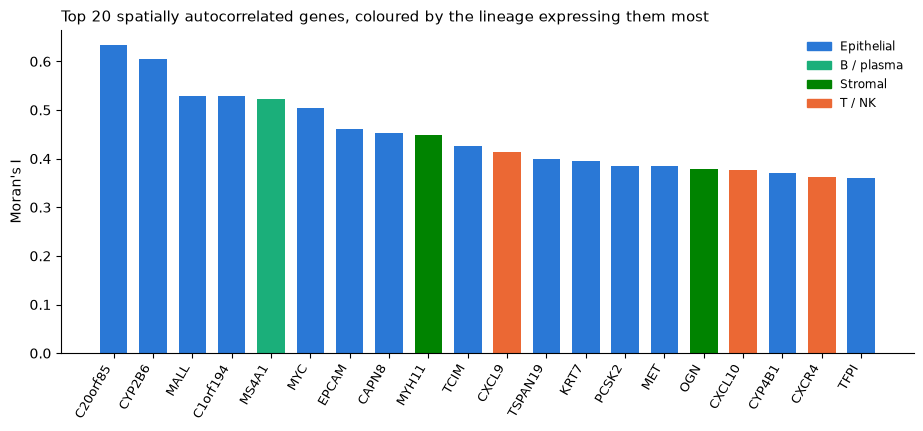

,I,pval_norm_fdr_bh,rank
CXCL9,0.4142,0.0000,11
CCL19,0.2551,0.0000,40
CD274,0.0082,0.0000,319
PDCD1,-0.0012,0.2328,376


Spatial structure is dominated by tissue compartments (tumour programmes, airway, B-cell TLS,
smooth muscle). Among immune signals, CXCL9 (I = 0.41, rank 11) forms hotspots, while PD-1 (I = -0.001)
has no spatial signal, consistent with it being near background.


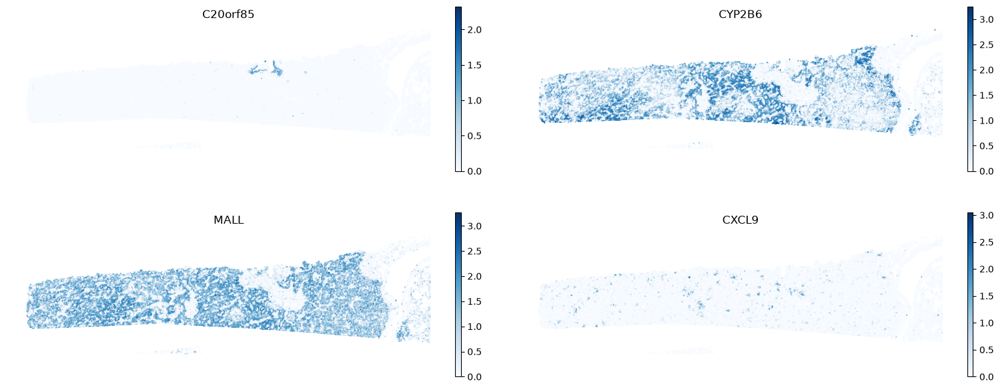

In [40]:
import sys

if "spatial_env" not in sys.prefix:
    raise RuntimeError("Wrong kernel. Use Kernel > Change Kernel > 'Python (spatial_env)'.")

import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
from IPython.display import display

from ist_analysis import stats
from ist_analysis import utils as xu

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SPATIAL_PATH = xu.STEP_FILES["spatial"]   # Step 7 output (has the spatial graph)
TIME_PATH = xu.STEP_FILES["time"]         # Step 9 output (contact-test results)
RESULTS_DIR = xu.output_dir("step10_squidpy")   # small result tables (CSV)

adata = sc.read_h5ad(SPATIAL_PATH)
adata.X = adata.layers["lognorm"]
LINEAGE_COLORS = dict(zip(adata.obs["lineage"].cat.categories, adata.uns["lineage_colors"]))
print(f"squidpy {sq.__version__}; {adata.n_obs:,} cells; Step 7 spatial graph with "
      f"{adata.obsp['spatial_connectivities'].nnz:,} edges\n")

# ---- Moran's I: which genes are spatially patterned? ------------------------------------
# I compares each cell's expression with its graph neighbours': ~0 = random in space,
# towards 1 = neighbours are similar (patches, gradients, structures).
# n_perms=None uses the analytical p-value; 100 permutations took > 10 min on this data.
t0 = time.time()
sq.gr.spatial_autocorr(adata, mode="moran", n_perms=None, show_progress_bar=False)
moran = adata.uns["moranI"]
print(f"Moran's I for {len(moran)} genes in {time.time() - t0:.0f} s; "
      f"{(moran['pval_norm_fdr_bh'] < 0.05).sum()} of {len(moran)} have FDR < 0.05.")
print("With ~140k cells nearly every gene is 'significant': rank by the effect size I, not the p-value.\n")

# Which lineage expresses each top gene most? (tells you what structure the pattern reflects)
top = moran.head(20).copy()
lin_mean = pd.DataFrame(adata[:, top.index].X.toarray(), columns=top.index).groupby(
    adata.obs["lineage"].to_numpy()).mean()
top["highest in"] = lin_mean.idxmax()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(range(len(top)), top["I"], color=[LINEAGE_COLORS[l] for l in top["highest in"]], width=0.7)
ax.set_xticks(range(len(top)), top.index, rotation=60, ha="right", fontsize=9)
ax.set_ylabel("Moran's I")
ax.set_title("Top 20 spatially autocorrelated genes, coloured by the lineage expressing them most",
             loc="left", fontsize=11)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=LINEAGE_COLORS[l], label=l) for l in dict.fromkeys(top["highest in"])],
          frameon=False, fontsize=8.5, loc="upper right")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

key_genes = ["CXCL9", "CCL19", "CD274", "PDCD1"]
display(moran.loc[key_genes, ["I", "pval_norm_fdr_bh"]].assign(rank=[moran.index.get_loc(g) + 1 for g in key_genes]).round(4))
print(f"Spatial structure is dominated by tissue compartments (tumour programmes, airway, B-cell TLS,\n"
      f"smooth muscle). Among immune signals, CXCL9 (I = {moran.loc['CXCL9', 'I']:.2f}, rank "
      f"{moran.index.get_loc('CXCL9') + 1}) forms hotspots, while PD-1 (I = {moran.loc['PDCD1', 'I']:.3f})\n"
      "has no spatial signal, consistent with it being near background.")

# squidpy's own plotting function: top 3 genes + CXCL9 on the tissue
_verbosity, sc.settings.verbosity = sc.settings.verbosity, 0   # silence a harmless 'library_id' notice
sq.pl.spatial_scatter(adata, color=list(moran.index[:3]) + ["CXCL9"], shape=None, size=0.4,
                      cmap="Blues", ncols=2, figsize=(9, 3.4), frameon=False, wspace=0.05)
sc.settings.verbosity = _verbosity
plt.show()
moran.to_csv(RESULTS_DIR / "moran_i.csv")

### 10b. Co-occurrence: associations with a length scale

The ratio P(type B within distance d of type A) / P(type B), computed on a seeded 40k-cell subsample (lineage mix matches the full data).

**Finding:** around T / NK cells, epithelium is depleted to **0.08 at ~17 µm and still 0.73 at 300 µm**: T cells sit in large tumour-poor zones, not just one or two cells away from tumour. Around myeloid cells, epithelium recovers to ~1 within ~100-150 µm. Step 7b gave the same direction for direct contacts; co-occurrence adds the length scale.

Subsample lineage mix vs. full data (% of cells):


lineage,B / plasma,Endothelial,Epithelial,Mast,Myeloid,Stromal,T / NK
full,4.3,6.8,61.6,1.8,8.1,13.2,4.3
subsample,4.4,6.8,61.4,1.7,8.3,13.2,4.2


co_occurrence: 14.1 s


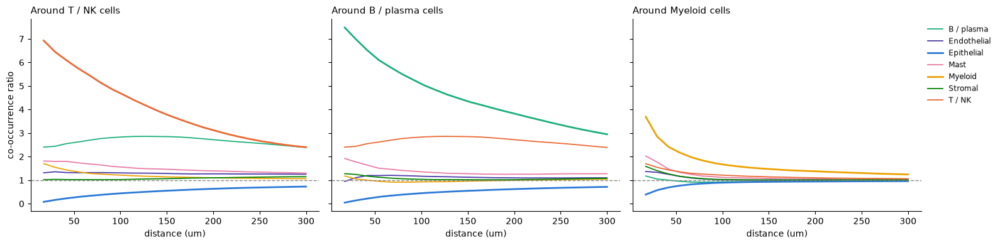

,epithelium within ~17 um,epithelium within ~103 um,epithelium within ~300 um
T / NK,0.08,0.45,0.73
B / plasma,0.04,0.45,0.71
Myeloid,0.39,0.90,0.96


Around T / NK cells, epithelium is strongly depleted at short range (0.08) and still
below 1 at 300 um (0.73): T cells sit in large tumour-poor zones, not just a
cell or two away from tumour. Around myeloid cells, epithelium recovers to ~1 within ~100-150 um:
myeloid cells live at the tumour edge. Same exclusion story as Steps 7d and 9d, now with a length scale.


In [41]:
# ---- A fixed random subsample for the distance-based statistics -------------------------
# co_occurrence and ripley scale super-linearly with cell number: Ripley's L on all 139k cells
# ran > 150 s; on 40k cells both take a few seconds. A seeded 40k subsample (29%) keeps every
# lineage well represented and is reproducible.
N_SUB = 40_000
sub = adata[np.random.default_rng(0).choice(adata.n_obs, N_SUB, replace=False)].copy()
print("Subsample lineage mix vs. full data (% of cells):")
display(pd.DataFrame({"full": adata.obs["lineage"].value_counts(normalize=True) * 100,
                      "subsample": sub.obs["lineage"].value_counts(normalize=True) * 100}).round(1).T)

# ---- Co-occurrence: P(type B within distance d | type A) / P(type B) ----------------------
# Ratio > 1 at distance d = B is found near A more than its overall frequency predicts.
# Unlike neighbourhood enrichment (direct contacts only), this shows HOW FAR an association reaches.
INTERVAL = np.linspace(5, 300, 25)
t0 = time.time()
sq.gr.co_occurrence(sub, cluster_key="lineage", interval=INTERVAL, show_progress_bar=False)
print(f"co_occurrence: {time.time() - t0:.1f} s")
occ = sub.uns["lineage_co_occurrence"]["occ"]          # (lineage, lineage, distance)
dist = sub.uns["lineage_co_occurrence"]["interval"][1:]
lineages = list(sub.obs["lineage"].cat.categories)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, anchor in zip(axes, ["T / NK", "B / plasma", "Myeloid"]):
    i = lineages.index(anchor)
    for j, lin in enumerate(lineages):
        ax.plot(dist, occ[i, j], color=LINEAGE_COLORS[lin], lw=2 if lin in (anchor, "Epithelial") else 1.3,
                label=lin)
    ax.axhline(1, color="#898781", ls="--", lw=1)
    ax.set_title(f"Around {anchor} cells", loc="left", fontsize=11)
    ax.set_xlabel("distance (um)")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("co-occurrence ratio")
axes[-1].legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.0, 1))
plt.tight_layout()
plt.show()

e_i = lineages.index("Epithelial")
at = [np.argmin(np.abs(dist - r)) for r in (20, 100, 300)]
summary = stats.co_occurrence_epithelium(sub).round(2)   # epithelium around each immune lineage at ~20 / 100 / 300 um
summary.to_csv(RESULTS_DIR / "co_occurrence_epithelium.csv")
display(summary)
t_i = lineages.index("T / NK")
print(f"Around T / NK cells, epithelium is strongly depleted at short range ({occ[t_i, e_i, at[0]]:.2f}) and still\n"
      f"below 1 at {dist[at[2]]:.0f} um ({occ[t_i, e_i, at[2]]:.2f}): T cells sit in large tumour-poor zones, not just a\n"
      "cell or two away from tumour. Around myeloid cells, epithelium recovers to ~1 within ~100-150 um:\n"
      "myeloid cells live at the tumour edge. Same exclusion story as Steps 7d and 9d, now with a length scale.")

### 10c. Ripley's L: clustering of each type against itself

**A squidpy pitfall worth knowing:** `gr.ripley` normalises every cluster's L by the *total* number of cells and simulates random sets of `n_observations` points. On raw data L then mostly tracks how **abundant** a cell type is: run that way, epithelium (60% of cells) looked "most clustered" and the random band collapsed to zero. The fix used here: a **balanced subsample of 2,000 cells per lineage** with random simulations of the same size, so all curves and the random band share one scale.

**Finding:** **B / plasma (3.6x the random band at 100 µm) and T / NK (3.3x) are by far the most clustered** (TLS and immune hubs); epithelium is the least (1.3x), because tumour fills most of the space. 'Random' means uniform in the convex hull, which ignores tissue holes, so the ranking between lineages is the informative part.

ripley L: 4.6 s (2,000 cells per lineage, 100 random simulations)


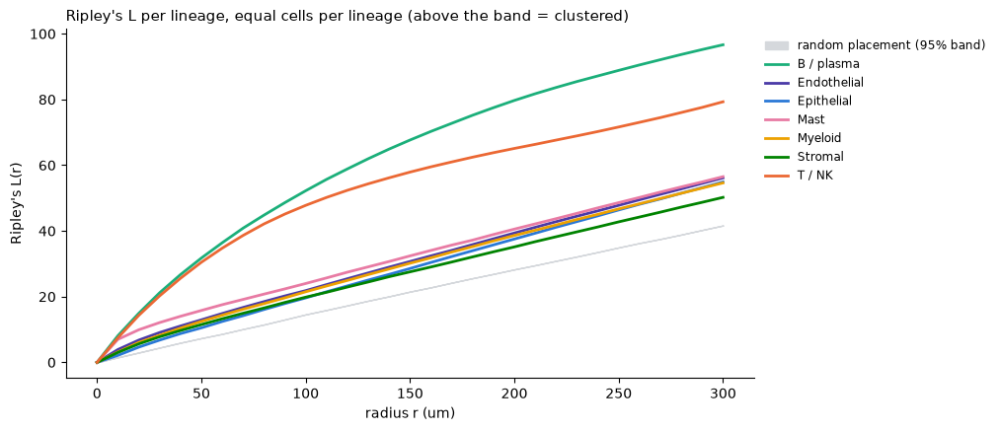

,L(100 um) / upper random band
lineage,
B / plasma,3.58
T / NK,3.28
Mast,1.65
Endothelial,1.50
Myeloid,1.47
Stromal,1.36
Epithelial,1.34


Ranked by clustering at 100 um: B / plasma, T / NK, Mast, Endothelial, Myeloid, Stromal, Epithelial.
Most clustered: B / plasma; least: Epithelial. Caveat: 'random' here means uniform inside the
convex hull of the section, which ignores holes and the irregular tissue edge, so every lineage looks
somewhat clustered; the ranking between lineages is the informative part.
Ripley's L measures each type against itself; neighbourhood enrichment (Step 7b) and co-occurrence
(10b) measure types against each other.


In [42]:
# ---- Ripley's L: how clustered is each lineage? ---------------------------------------------
# Pitfall: squidpy normalises every lineage's L by the TOTAL number of cells, and simulates
# random sets of n_observations points. Run on the raw data, L then mostly reflects how ABUNDANT
# a lineage is (epithelium = 60% of cells), not how clustered. The fix: a balanced subsample with
# the same number of cells per lineage, and random (CSR) simulations of that same size. Then each
# curve and the random band are on one scale and directly comparable.
N_PER_LINEAGE = 2_000
t0 = time.time()
ratio, L, sims = stats.ripley_balanced(adata, N_PER_LINEAGE, seed=0)   # balanced subsample, 100 CSR simulations
print(f"ripley L: {time.time() - t0:.1f} s ({N_PER_LINEAGE:,} cells per lineage, 100 random simulations)")
lo, hi = sims.groupby("bins")["stats"].quantile(0.025), sims.groupby("bins")["stats"].quantile(0.975)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.fill_between(lo.index, lo.to_numpy(), hi.to_numpy(), color="#d5d8dc", label="random placement (95% band)")
for lin, g in L.groupby("lineage", observed=True):
    ax.plot(g["bins"], g["stats"], color=LINEAGE_COLORS[lin], lw=2, label=lin)
ax.set_xlabel("radius r (um)")
ax.set_ylabel("Ripley's L(r)")
ax.set_title("Ripley's L per lineage, equal cells per lineage (above the band = clustered)", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.0, 1))
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

# ratio: L(100 um) / upper random band per lineage (stats.ripley_balanced)
display(ratio.round(2).to_frame())
print(f"Ranked by clustering at 100 um: {', '.join(ratio.index)}.\n"
      f"Most clustered: {ratio.index[0]}; least: {ratio.index[-1]}. Caveat: 'random' here means uniform inside the\n"
      "convex hull of the section, which ignores holes and the irregular tissue edge, so every lineage looks\n"
      "somewhat clustered; the ranking between lineages is the informative part.\n"
      "Ripley's L measures each type against itself; neighbourhood enrichment (Step 7b) and co-occurrence\n"
      "(10b) measure types against each other.")

### 10d. Network view: centrality and interaction matrix

**Finding:** **myeloid cells have the highest closeness centrality (0.39)**, i.e. they bridge tumour, stroma and immune compartments, the network form of the myeloid-lined tumour border; B / plasma cells are the least central (0.15), tucked into aggregates. The interaction matrix gives raw edge shares (what a cell actually touches): T / NK cells mostly touch other T / NK cells (36%), stroma (16%) and myeloid cells (14%). Unlike the z-scores of Step 7b, these are not corrected for abundance; both views are needed.

,degree_centrality,average_clustering,closeness_centrality
Myeloid,0.263,0.417,0.388
Stromal,0.310,0.419,0.355
Epithelial,0.417,0.424,0.303
Endothelial,0.173,0.427,0.291
T / NK,0.115,0.427,0.209
Mast,0.072,0.432,0.189
B / plasma,0.097,0.424,0.152


degree = share of the graph's cells this lineage connects to; closeness = how few steps it
takes to reach the rest of the tissue (a 'bridging' position); clustering = how interconnected
its neighbours are.
Highest closeness: Myeloid (0.39); lowest: B / plasma (0.15). The myeloid compartment sits
between tumour, stroma and immune cells, the network form of the myeloid-lined border in Step 7d.



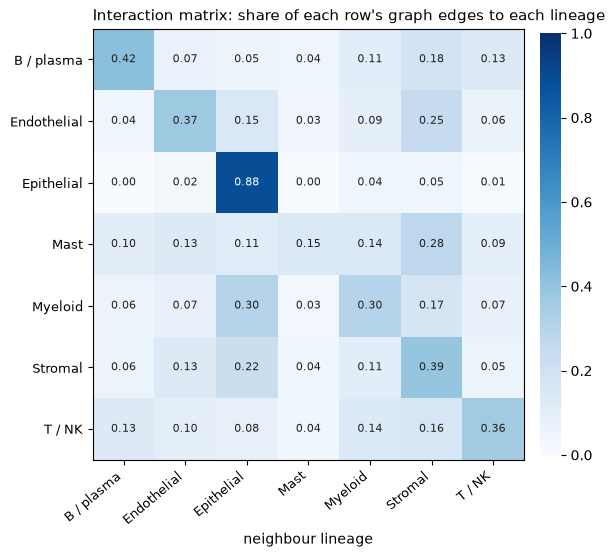

Raw edge shares (rows sum to 1) show what a typical cell actually touches. T / NK cells: T / NK 36%, Stromal 16%, Myeloid 14%.
Compare with Step 7b: a pair can be a large share of contacts yet still depleted relative to
chance (because epithelium is 60% of cells). Both views are needed.


In [43]:
# ---- Network view: centrality scores and interaction matrix (full data) ----------------
sq.gr.centrality_scores(adata, cluster_key="lineage", show_progress_bar=False)
cent = adata.uns["lineage_centrality_scores"].sort_values("closeness_centrality", ascending=False)
display(cent.round(3))
print("degree = share of the graph's cells this lineage connects to; closeness = how few steps it\n"
      "takes to reach the rest of the tissue (a 'bridging' position); clustering = how interconnected\n"
      "its neighbours are.")
print(f"Highest closeness: {cent.index[0]} ({cent['closeness_centrality'].iloc[0]:.2f}); lowest: "
      f"{cent.index[-1]} ({cent['closeness_centrality'].iloc[-1]:.2f}). The myeloid compartment sits\n"
      "between tumour, stroma and immune cells, the network form of the myeloid-lined border in Step 7d.\n")

sq.gr.interaction_matrix(adata, cluster_key="lineage", normalized=True)
lineages_full = list(adata.obs["lineage"].cat.categories)
im_df = pd.DataFrame(adata.uns["lineage_interactions"], index=lineages_full, columns=lineages_full)
fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = ax.imshow(im_df.to_numpy(), cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(im_df)), im_df.columns, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(len(im_df)), im_df.index, fontsize=9)
for (i, j), v in np.ndenumerate(im_df.to_numpy()):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if v > 0.55 else "#222222")
ax.set_xlabel("neighbour lineage")
ax.set_title("Interaction matrix: share of each row's graph edges to each lineage", loc="left", fontsize=10.5)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03).outline.set_visible(False)
plt.show()
t_row = im_df.loc["T / NK"].sort_values(ascending=False)
print(f"Raw edge shares (rows sum to 1) show what a typical cell actually touches. T / NK cells: "
      f"{t_row.index[0]} {t_row.iloc[0]:.0%}, {t_row.index[1]} {t_row.iloc[1]:.0%}, "
      f"{t_row.index[2]} {t_row.iloc[2]:.0%}.\n"
      "Compare with Step 7b: a pair can be a large share of contacts yet still depleted relative to\n"
      "chance (because epithelium is 60% of cells). Both views are needed.")
cent.to_csv(RESULTS_DIR / "centrality_lineage.csv")
im_df.to_csv(RESULTS_DIR / "interaction_matrix_lineage.csv")

### 10e. `ligrec` vs. the Step 9 contact test

`gr.ligrec` (a CellPhoneDB-style test using the OmniPath database) asks whether a ligand in the sender type and its receptor in the receiver type are expressed above chance. It does **not** use space. Only **80 OmniPath pairs** have both genes on this panel.

**Finding, the key contrast:**
- **CCL19 -> CCR7** passes both tests: expressed (16 of 16 sender-receiver type pairs) and in contact (2.35x). The TLS homing axis is supported two ways.
- **EDN1 -> EDNRB** is significant in ligrec (tumour -> endothelium, 17 of 21 type pairs) but **not** spatially enriched (0.99x): the cells could signal, but EDN1+ tumour cells do not sit closer to EDNRB+ endothelium than other tumour cells do.
- PD-L1 -> PD-1 is in OmniPath but below ligrec's expression threshold; CD86 -> CTLA4/CD28 and MHC-II -> CD4 are not in the OmniPath list at all.

ligrec flags 2,953 'significant' combinations: expression-only tests are permissive, and spatial contact is what narrows them down. Note squidpy's dot plot legend: open circles mark significant interactions.

Result tables are saved as CSV in `~/data/xenium_lung/processed/step10_squidpy/`.

ligrec: 24 s; 80 ligand-receptor pairs from OmniPath have both genes on the panel (and pass the 5% expression threshold), tested across 324 sender-receiver cell-type combinations
Significant (FDR < 0.05) pair x sender x receiver combinations: 2,953 of 4,246 tested.
Expression-only tests flag many 'possible' interactions; spatial proximity narrows them down.



,ligrec (expression),ligrec top sender -> receiver,contact test obs/exp,contact test FDR q
pair,,,,
CD274 -> PDCD1,"in OmniPath, below expression threshold",-,0.45,0.8961
CD86 -> CTLA4,pair not in the OmniPath ligand-receptor list,-,1.01,0.5829
CD86 -> CD28,pair not in the OmniPath ligand-receptor list,-,1.03,0.5829
CCL19 -> CCR7,significant in 16 of 16 type pairs,mregDC (LAMP3+) -> mregDC (LAMP3+),2.35,0.0030
HLA-DQB2 -> CD4,pair not in the OmniPath ligand-receptor list,-,1.14,0.0030
EDN1 -> EDNRB,significant in 17 of 21 type pairs,Tumour epithelial (MYC/CAPN8) -> Endothelial,0.99,0.8571


They answer different questions. ligrec: could these cell types talk, given what they express?
Contact test: do the expressing cells actually touch more than chance? EDN1 -> EDNRB is the clearest
case: tumour cells and endothelium express the pair (ligrec significant), but EDN1+ tumour cells do
not sit next to EDNRB+ endothelium more than other tumour cells do (contact test null).
CCL19 -> CCR7 passes both: expressed AND in contact, the TLS homing axis.


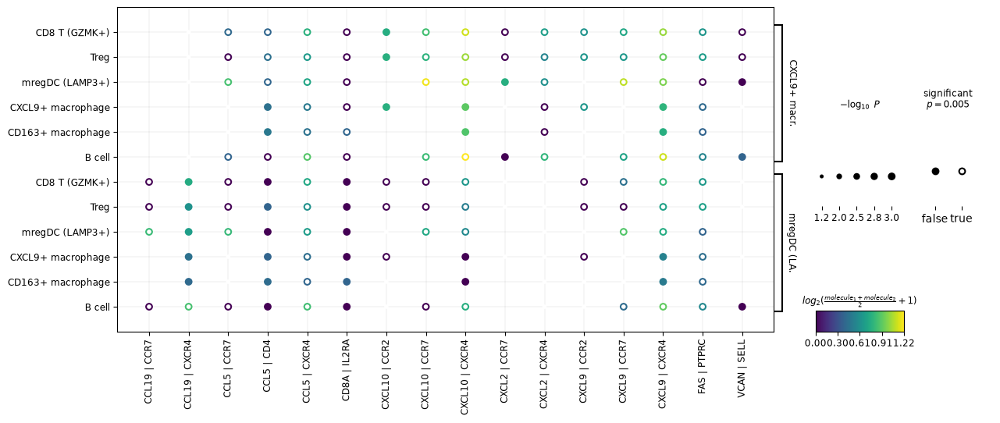

Saved CSV tables to ~/data/xenium_lung/processed/step10_squidpy/


In [44]:
# ---- squidpy ligrec (CellPhoneDB-style) vs. the Step 9 contact test ------------------------
# ligrec asks: is the ligand mean in the sender type x receptor mean in the receiver type higher
# than when cluster labels are shuffled? It uses expression only, not who touches whom.
# Interactions come from the OmniPath database (downloaded on first use).
t0 = time.time()
lr = sq.gr.ligrec(adata, cluster_key="time_type", use_raw=False, n_perms=1000, threshold=0.05,
                  seed=0, copy=True, corr_method="fdr_bh", show_progress_bar=False, n_jobs=4)
means, qvals = stats.ligrec_dense(lr)   # ligrec returns SPARSE DataFrames: densify before indexing
print(f"ligrec: {time.time() - t0:.0f} s; {means.shape[0]} ligand-receptor pairs from OmniPath have both genes "
      f"on the panel (and pass the 5% expression threshold), tested across {means.shape[1]} sender-receiver "
      "cell-type combinations")
long = (qvals.stack([0, 1], future_stack=True).rename("q").to_frame()
        .join(means.stack([0, 1], future_stack=True).rename("mean")))
print(f"Significant (FDR < 0.05) pair x sender x receiver combinations: {(long['q'] < 0.05).sum():,} "
      f"of {long['q'].notna().sum():,} tested.\n"
      "Expression-only tests flag many 'possible' interactions; spatial proximity narrows them down.\n")

# Side-by-side with the Step 9 contact test for the same pairs (stats.ligrec_vs_contact)
contact = sc.read_h5ad(TIME_PATH, backed="r").uns["step9_lr_results"]
contact = (contact.assign(pair=contact["pair"].str.replace("_to_", " -> ")).set_index("pair")
           .rename(columns={"obs_over_exp": "obs / exp", "FDR_q": "FDR q"}))
compare = stats.ligrec_vs_contact(means, qvals, contact)
display(compare)
print("They answer different questions. ligrec: could these cell types talk, given what they express?\n"
      "Contact test: do the expressing cells actually touch more than chance? EDN1 -> EDNRB is the clearest\n"
      "case: tumour cells and endothelium express the pair (ligrec significant), but EDN1+ tumour cells do\n"
      "not sit next to EDNRB+ endothelium more than other tumour cells do (contact test null).\n"
      "CCL19 -> CCR7 passes both: expressed AND in contact, the TLS homing axis.")

# squidpy's dot plot for the immune-relevant senders/receivers
FOCUS = ["CD8 T (GZMK+)", "Treg", "mregDC (LAMP3+)", "CXCL9+ macrophage", "CD163+ macrophage", "B cell"]
FOCUS = [f for f in FOCUS if f in adata.obs["time_type"].cat.categories]
sq.pl.ligrec(lr, source_groups=["mregDC (LAMP3+)", "CXCL9+ macrophage"], target_groups=FOCUS,
             alpha=0.005, means_range=(0.3, np.inf), swap_axes=True, remove_empty_interactions=True,
             remove_nonsig_interactions=True, title="ligrec: mregDC / CXCL9+ macrophage -> immune cells (FDR < 0.005)",
             figsize=(13, 5))
plt.show()
compare.to_csv(RESULTS_DIR / "ligrec_vs_contact_test.csv")
long[long["q"] < 0.05].sort_values("mean", ascending=False).to_csv(RESULTS_DIR / "ligrec_significant.csv")
print("Saved CSV tables to ~/data/xenium_lung/processed/step10_squidpy/")

## Summary

| Step | Output (in `~/data/xenium_lung/processed/`) | Key result |
|---|---|---|
| 4 QC | `..._qc.h5ad` | 154,394 of 162,254 cells kept (95.2%); low-count cells concentrated in a detached tissue sliver |
| 5 Clustering | `..._clustered.h5ad` | 14 Leiden clusters; ARI 0.51 vs. the 10x clustering |
| 6 Annotation | `..._annotated.h5ad` | 33 cell types in 7 lineages; ~10% flagged as segmentation spillover |
| 7 Spatial | `..._spatial.h5ad` | 10 niches; CD8 T cells excluded from tumour; 6 TLS-like aggregates |
| 8 H&E | `..._he_features.h5ad` | Alignment verified (peak at zero shift); cell calls match histology |
| 9 TIME | `..._time.h5ad` | PD-L1 on myeloid/DCs not tumour; CD8 lose CCR7 toward tumour; CCL19-CCR7 contacts 2.4x enriched; 65% of tumour tiles immune-excluded, MYC/CAPN8 region mostly desert |
| 10 squidpy | `step10_squidpy/*.csv` | CXCL9 forms hotspots (Moran's I 0.41); epithelium depleted around T cells out to 300 µm; B/plasma and T/NK most clustered; myeloid most central; ligrec vs. contact tests disagree on EDN1-EDNRB |

**Biological picture of this section:** an adenocarcinoma-like, largely tumour-filled section with three spatially separate tumour epithelial programmes; a tumour border lined by macrophages, cDC2 and fibroblasts; CD8 T cells held back from tumour nests (immune-excluded pattern) and instead gathered with B cells and mregDCs in TLS-like aggregates, where CCL19-CCR7 homing contacts are strongly enriched. PD-L1 is carried by CXCL9+ macrophages and mregDCs rather than tumour cells, Tregs rise relative to CD8 T cells toward the tumour, and one tumour programme (MYC/CAPN8) is largely immune-desert.

**Limits to state honestly:** one section from one patient (descriptive, not inferential); a Multi-Tissue 377-gene panel (no AT2 / basal / club markers, no mature-TLS markers); tumour identity inferred from markers and histology, not copy number; default 10x segmentation (spillover in ~10% of cells).

**Natural next steps:**
1. **Re-segmentation** from `transcripts.parquet` (e.g. Baysor, Proseg) to reduce spillover and recover CD4 T cells.
2. **Dataset B (Xenium Prime 5K)**: the same workflow with ~5,000 genes, enabling finer T-cell states, tumour programmes and ligand-receptor analysis.
3. **Ligand-receptor analysis on a larger panel**: Step 10e shows only 80 OmniPath pairs are testable here; the 5K panel adds the missing genes (CXCR3, CXCL13, TIGIT, TOX, SPP1).
4. **Multi-sample cohort**: niche and TLS features compared across patients and linked to outcome.